# **AI Agent Physics Benchmark**

## Participants
Mentor: Gunther Roland

TA: Alex Cai

Group Members: Daniel Zhu, Jin Huang, Anson Lin, Jason Yang

## What this is

A small-scale benchmark for evaluating AI coding-agent CLIs (**Qwen CLI**, **Claude Code**, **Codex CLI**, **Kimi CLI**) on data-driven scientific discovery tasks in physics — inspired by the design principles behind ScienceAgentBench: tasks must be data-based and quantifiable, have a known ground truth, and the ground truth must be hidden from the agent before evaluation.

## Benchmark framework

The project follows a four-step framework:

1. **Select a physical task & dataset** — data-based rather than text-based, so it's easy to quantify; the dataset must have a ground truth; results are masked before being handed to the AI (to prevent data leakage / shortcut answers).
2. **Design the prompt & input package** — a task instruction plus a description of the data, with no solution steps given, keeping the task open-ended.
3. **Run the AI agent** — start with Qwen CLI (lowest cost) to validate the full pipeline, then expand to Claude Code / Codex CLI / Kimi CLI. Each task is run 2–3 times per tool to check stability.
4. **Design scoring metrics** — Valid Execution Rate (VER), Success Rate (SR, e.g. RMSE-based), CodeBERTScore (if reference code exists), API cost, and run-to-run stability. Figure outputs are scored with GPT-4o. Metrics are combined into a ranking, with a written summary of where each tool falls short.

## Notebook structure

This notebook mirrors the four-step framework section by section for each experiment:

| Section | Maps to | Purpose |
|---|---|---|
| 1. Setup & Imports | — | Shared libraries used across all experiments |
| 2. Experiments | Step 1 | One class per physical experiment: loads/generates data, builds train/test tasks, exports files |
| 3. Task & Prompt Design | Step 2 | Turns an experiment's exported task into the actual instruction text handed to an AI agent |
| 4. Run AI Agents | Step 3 | Headless-mode wrappers for each CLI, run each task multiple times, log results as JSON |
| 5. Scoring | Step 4 | Compare AI outputs against the hidden ground truth, compute metrics, rank the tools |

Every experiment class in Section 2 exposes the same lightweight interface (`get_*_task()`, `export_task()`, `get_true_parameters()`, `plot()`), so Sections 3–5 can work with any experiment without being rewritten as new experiments are added.

## Setup & Imports

Libraries used:
- `numpy`: numerical operations
- `pandas`: data loading, CSV I/O
- `scipy.integrate.solve_ivp`: kept available for future experiments that may require numerical ODE simulation (not used by Experiment 1, which loads real data directly)
- `matplotlib`: visualize experiment data and derived quantities
- `pathlib`: file path management
- `typing.Optional`: type hints, kept consistent across all experiment classes
- `json`: read/write run logs, `model_summary.json`, and other config/result files
- `warnings`: suppress noisy library warnings (`warnings.filterwarnings("ignore")`)
- `os`: environment variables (API keys) and `PATH` manipulation for locating CLI binaries
- `re`: regex parsing of CLI stdout to extract token counts / credit usage for cost calculation (Qwen, CodeBuddy)
- `requests`: HTTP calls — Kimi account balance checks, live USD→CNY exchange rate, DeepSeek API for the AI-judge dimension
- `subprocess`: invoking each CLI agent as a headless subprocess and capturing its output
- `time`: timing each agent run (`elapsed_sec`) for the run logs

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pathlib import Path
from typing import Optional
import json
import warnings
import os
import re
import requests
import subprocess
import time
import shutil
import threading

warnings.filterwarnings("ignore")

# Global plotting style
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True

# Root directory for all experiment data (each experiment gets its own subfolder)
DATA_ROOT = Path("data")
DATA_ROOT.mkdir(exist_ok=True)

print("Setup complete")

Setup complete


In [161]:
from dotenv import load_dotenv
load_dotenv(os.path.expanduser("~/.benchmark_keys.env"), override=True)

ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY")
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
DASHSCOPE_API_KEY = os.environ.get("DASHSCOPE_API_KEY")
MOONSHOT_API_KEY = os.environ.get("MOONSHOT_API_KEY")
DEEPSEEK_API_KEY = os.environ.get("DEEPSEEK_API_KEY")
CODEBUDDY_API_KEY = os.environ.get("CODEBUDDY_API_KEY")
CODEBUDDY_INTERNET_ENVIRONMENT = os.environ.get("CODEBUDDY_INTERNET_ENVIRONMENT")
CODEX_API_KEY = os.environ.get("CODEX_API_KEY")

print({k: (v[:8] + "..." if v else None) for k, v in {
    "ANTHROPIC_API_KEY": ANTHROPIC_API_KEY,
    "OPENAI_API_KEY": OPENAI_API_KEY,
    "DASHSCOPE_API_KEY": DASHSCOPE_API_KEY,
    "MOONSHOT_API_KEY": MOONSHOT_API_KEY,
    "DEEPSEEK_API_KEY": DEEPSEEK_API_KEY,
    "CODEBUDDY_API_KEY": CODEBUDDY_API_KEY,
    "CODEBUDDY_INTERNET_ENVIRONMENT": CODEBUDDY_INTERNET_ENVIRONMENT,
    "CODEX_API_KEY": CODEX_API_KEY
}.items()})

{'ANTHROPIC_API_KEY': 'sk-ant-a...', 'OPENAI_API_KEY': 'sk-proj-...', 'DASHSCOPE_API_KEY': 'sk-ws-H....', 'MOONSHOT_API_KEY': 'sk-VwZPN...', 'DEEPSEEK_API_KEY': 'sk-806d4...', 'CODEBUDDY_API_KEY': 'ck_fsxpw...', 'CODEBUDDY_INTERNET_ENVIRONMENT': 'internal...', 'CODEX_API_KEY': 'sk-proj-...'}


In [160]:
os.environ["OPENAI_API_KEY"] = DASHSCOPE_API_KEY
os.environ["OPENAI_BASE_URL"] = "https://dashscope.aliyuncs.com/compatible-mode/v1"
os.environ["OPENAI_MODEL"] = "qwen3-coder-plus"

claude_bin_dir = os.path.expanduser("~/.local/bin")
if claude_bin_dir not in os.environ["PATH"]:
    os.environ["PATH"] = claude_bin_dir + os.pathsep + os.environ["PATH"]

extra_dirs = [
    "~/.local/bin",
    "/opt/homebrew/bin",
    "~/.nvm/versions/node/v22.23.1/bin",
]
for d in extra_dirs:
    d = os.path.expanduser(d)
    if d not in os.environ["PATH"]:
        os.environ["PATH"] = d + os.pathsep + os.environ["PATH"]

os.environ["CODEBUDDY_API_KEY"] = CODEBUDDY_API_KEY
os.environ["CODEBUDDY_INTERNET_ENVIRONMENT"] = CODEBUDDY_INTERNET_ENVIRONMENT

## **Agents Under Test (CLI)**

This benchmark currently compares four CLI-based coding agents, each with its own built-in agent scaffolding (file I/O, shell execution, multi-turn reasoning). All four wrap an underlying LLM with a full agentic toolset — the benchmark score reflects **CLI + model** performance combined, not the raw model alone.

| Agent | Auth | Model | Cost tier | Status |
|---|---|---|---|---|
| Qwen CLI | DashScope (OpenAI-compatible) API key | qwen3-coder-plus | Low | ✅ Working |
| Kimi CLI | Moonshot API key | kimi-k3 | Medium-Low | ✅ Working |
| Claude Code | Anthropic API key / subscription | v2.1.74 | Medium–High | ✅ Working |
| Codex CLI | OpenAI API key / ChatGPT subscription | gpt-5.3-codex | Medium-High | ✅ Working |
| Code Buddy | Tencent API key | GLM-5.2 | Lowest | ✅ Working |

## Experiment 1: Damped Harmonic Oscillator

Uses real experimental data (not simulated): `train.csv` / `test.csv`, each with columns
`time, displacement, velocity, acceleration`.

This section has two layers:
- **Module-level dispatcher** (`AGENT_COMMANDS`, `run_agent_cli`) — experiment-agnostic, calls a CLI agent headlessly on whatever `(prompt, work_dir)` it's given. Any future experiment class can reuse this unchanged.
- **`DampedHarmonicOscillator`** — handles only this experiment's data: loading the real CSVs, masking test targets, building the prompt, and a `run()` convenience method that exports files + calls the dispatcher, 1 run per subfolder.

The class does **no modeling or physics verification** — figuring out the system's dynamics and producing predictions is entirely the AI agent's job.

**Prompt design note:** the current prompt deliberately withholds even the qualitative "oscillator" framing — the agent is only told it's observing a point mass's 1D motion (`train.csv`: full time series; `test_input.csv`: timestamps only) and must diagnose the dynamics empirically rather than assuming a textbook system. Beyond `script.py` and `test_pred.csv`, the agent is also required to output `model_summary.json` — a self-reported summary of the model type it chose, the governing equation/description, fitted parameters, and its reasoning. This gives Step 4 scoring an extra signal (does the agent's own account of what it did match its actual output?) independent of raw prediction accuracy.

**Physics background** (reference only, not revealed to the AI): mass $m=1\text{ kg}$, spring constant $k=1\text{ N/m}$, damping coefficient $c=0.1\text{ Ns/m}$, $x(0)=1\text{ m}$, $v(0)=0$, obeying $m x'' + c x' + kx = 0$.

### Step 1 & 2 — Task Data & Prompt Design

Loads the real dataset, builds the task package, and can dispatch it to a CLI agent
one or more times via `run()`. Each run gets its own subfolder so repeated runs
(3x per tool, per the framework) don't overwrite each other's script/prediction/log.

In [52]:
class DampedHarmonicOscillator:
    """
    Experiment 1: Damped Harmonic Oscillator (real data).

    Data-only handler: loads the real train/test CSVs, packages the task
    for an AI agent, and dispatches it to a CLI agent one or more times.
    No modeling / physics verification happens here -- the AI agent does
    100% of the analysis and prediction work.

    Usage:
        exp = DampedHarmonicOscillator(train_path, test_path)
        logs = exp.run("qwen", n_runs=3)
    """

    name = "damped_harmonic_oscillator"

    def __init__(
        self,
        train_path: str,
        test_path: str,
        m: float = 1.0,
        c: float = 0.1,
        k: float = 1.0,
        x0: float = 1.0,
        v0: float = 0.0,
    ):
        # Known/assumed generating parameters -- kept only as metadata for
        # later scoring reference (Step 4). Never exposed to the AI, never
        # used here.
        self.m, self.c, self.k = m, c, k
        self.x0, self.v0 = x0, v0

        self.train_path = Path(train_path)
        self.test_path = Path(test_path)
        self.train_df: Optional[pd.DataFrame] = None
        self.test_df: Optional[pd.DataFrame] = None
        self.load_data()

    def load_data(self):
        """Load the real train/test CSVs as-is. No simulation, no processing."""
        self.train_df = pd.read_csv(self.train_path)
        self.test_df = pd.read_csv(self.test_path)
        return self.train_df, self.test_df

    def get_masked_test_input(self, target_cols=("displacement", "velocity", "acceleration")) -> pd.DataFrame:
        """Return the test set with target columns removed -- this is what the AI receives."""
        cols_to_drop = [c for c in target_cols if c in self.test_df.columns]
        return self.test_df.drop(columns=cols_to_drop)

    def get_ground_truth(self) -> pd.DataFrame:
        """Full test.csv with target columns intact. For scoring only (Step 4) -- never handed to the AI."""
        return self.test_df.copy()

    def build_prompt(self, output_path: str = "test_pred.csv", script_name: str = "script.py", model_summary_path: str = "model_summary.json") -> str:
        """
        Build the task instruction handed to the AI agent. Unlike a physics-textbook
        framing, this version withholds even the qualitative "oscillator" hint --
        the agent is only told it's observing a point mass's 1D motion, and must
        infer the governing dynamics itself, then report what it inferred in a
        separate JSON file.
        """
        return f"""You are a data scientist analyzing real sensor data from a moving point mass.

    ## Data
    You are given two files in your current working directory:
    - `train.csv`: columns [time, displacement, velocity, acceleration] -- full time-series measurements of a point mass moving along one axis, recorded from a real experiment.
    - `test_input.csv`: column [time] only. These are new timestamps for the same system. Your job is to predict the system's state (displacement, and optionally velocity/acceleration) at each of these timestamps.

    ## Task
    1. Explore train.csv to understand how this system behaves over time -- do not assume any particular physical model in advance (e.g. do not assume it is a spring, pendulum, or any specific textbook system). Let the data tell you what kind of dynamics you're looking at.
    2. Based on what you observe, decide what class of model best describes this system's dynamics, and fit it to train.csv. This could be a physical differential equation you infer and fit, a general-purpose regression/sequence model, or any other data-driven approach you consider appropriate.
    3. Use the fitted model to predict displacement (and optionally velocity/acceleration) at every timestamp in test_input.csv.

    ## Constraints
    - You are not told in advance what kind of system this is. Diagnose it empirically from the data (e.g. from qualitative patterns like periodicity, growth/decay, noise characteristics) rather than assuming a specific textbook formula.
    - You may use any Python libraries available to you (numpy, scipy, pandas, sklearn, etc.).
    - You decide the full workflow: how to explore the data, what model class to use, how to validate your fit, and how to handle noise.

    ## Output requirements
    1. Write a single, self-contained Python script named exactly `{script_name}` in your current working directory, performing the full workflow (data loading -> modeling -> prediction -> saving output), runnable standalone via `python {script_name}`.
    2. Save your final predictions to `{output_path}` (same directory as `{script_name}`), with:
        - a `time` column matching test_input.csv's timestamps exactly (same values, same order)
        - a `displacement` column (required)
        - `velocity` and/or `acceleration` columns if you modeled those too (optional)
    3. Save a short summary of your modeling decision to `{model_summary_path}` as a JSON file with (at minimum) these fields:
        - `"model_type"`: a short label for the class of model you chose (e.g. "damped harmonic oscillator", "random forest regressor", "custom ODE", etc. -- your own words)
        - `"equation_or_description"`: the governing equation (if applicable) or a brief description of the model
        - `"fitted_parameters"`: a dict of the key parameters you fit (if applicable)
        - `"reasoning"`: 2-3 sentences on what patterns in the data led you to this choice
    - Supporting plots or notes are optional and not required."""
    
    def export_task_files(self, output_dir: str) -> Path:
        """Write train.csv (full) and test_input.csv (masked) into a folder for the AI to read from."""
        out = Path(output_dir)
        out.mkdir(parents=True, exist_ok=True)
        self.train_df.to_csv(out / "train.csv", index=False)
        self.get_masked_test_input().to_csv(out / "test_input.csv", index=False)
        print(f"Task files written to {out.resolve()}")
        return out

    def get_true_parameters(self) -> dict:
        """Known parameters, kept for later scoring reference only."""
        return {"experiment": self.name, "m": self.m, "c": self.c, "k": self.k,
                "x0": self.x0, "v0": self.v0}

    def run(self, agent_name: str, base_dir: str = "data/damped_oscillator", n_runs: int = 3, timeout: int = 600) -> list:
        """
        Convenience entry point: run this experiment's task against `agent_name`
        `n_runs` times. Each run gets its own subfolder (run_1, run_2, ...)
        with a fresh copy of train.csv / test_input.csv, so each run's script,
        predictions, and logs don't overwrite each other.

        Returns a list of run log dicts (one per run).
        """
        logs = []
        for i in range(1, n_runs + 1):
            run_dir = Path(base_dir) / agent_name / f"run_{i}"
            self.export_task_files(run_dir)
            prompt = self.build_prompt()
            print(f"[{agent_name}] run {i}/{n_runs} -> {run_dir}")
            log = run_agent_cli(agent_name, prompt, str(run_dir), timeout=timeout)
            logs.append(log)
        return logs

    def __repr__(self):
        n_train = len(self.train_df) if self.train_df is not None else 0
        n_test = len(self.test_df) if self.test_df is not None else 0
        return f"DampedHarmonicOscillator(train_n={n_train}, test_n={n_test})"

### Step 3 — Agent Dispatcher

A single, experiment-agnostic function: given a prompt and a working directory (already containing `train.csv` / `test_input.csv`), dispatch the task to one of the four CLIs in headless mode and log the result. This function doesn't know or care which physics experiment it's running — any future experiment class that implements `export_task_files()` + `build_prompt()` can be plugged in here unchanged.

In [53]:
def _pre_trust_claude_dir(work_dir: Path):
    """Pre-seed Claude Code's trust-dialog acceptance for work_dir so headless
    runs don't hang waiting for an interactive 'trust this folder?' prompt."""
    config_path = Path.home() / ".claude.json"
    try:
        with open(config_path) as f:
            config = json.load(f)
    except (FileNotFoundError, json.JSONDecodeError):
        config = {}
    config.setdefault("projects", {})
    resolved = str(work_dir.resolve())
    config["projects"].setdefault(resolved, {})
    config["projects"][resolved]["hasTrustDialogAccepted"] = True
    with open(config_path, "w") as f:
        json.dump(config, f, indent=2)

In [193]:
# Headless-mode invocation for each CLI (see Section 4 for details on these flags)
AGENT_COMMANDS = {
    "qwen":   lambda prompt: ["qwen", "-p", prompt, "--output-format", "json", "--yolo"],
    "claude": lambda prompt: ["claude", "-p", prompt, "--output-format", "json", "--dangerously-skip-permissions"],
    "codex":  lambda prompt: ["codex", "exec", prompt, "--json", "--dangerously-bypass-approvals-and-sandbox", "--skip-git-repo-check"],
    "kimi": lambda prompt: ["kimi", "-p", prompt, "--model", "moonshot-cn/kimi-k3",
                            "--output-format", "stream-json"],
    "codebuddy": lambda prompt: ["codebuddy", "-p", prompt, "--output-format", "json", "-y"],
}

# Minimal system env vars every subprocess needs to function normally
# (locate binaries, find its own config/cache dirs, etc.)
BASE_ENV_KEYS = ["PATH", "HOME", "USER", "LANG", "LC_ALL", "SHELL", "TMPDIR", "TERM"]

# Per-agent allowlist: only the credentials/config that agent actually needs.
# codex has an empty list here because its API-key auth is cached locally at
# ~/.codex/auth.json (via `codex login --with-api-key`), not read from env.
AGENT_ENV_KEYS = {
    "qwen": ["OPENAI_API_KEY", "OPENAI_BASE_URL", "OPENAI_MODEL"],
    "claude": ["ANTHROPIC_API_KEY"],
    "codex": [],
    "kimi": ["MOONSHOT_API_KEY"],
    "codebuddy": ["CODEBUDDY_API_KEY", "CODEBUDDY_INTERNET_ENVIRONMENT"],
}


def build_restricted_env(agent_name: str) -> dict:
    """Minimal environment for one agent's subprocess: base system vars needed
    for any process to run, plus only that agent's own credentials -- excludes
    every other provider's API key so a run can't accidentally (or via a stray
    `env`/`printenv` shell command) see keys it has no business seeing."""
    env = {k: os.environ[k] for k in BASE_ENV_KEYS if k in os.environ}
    for k in AGENT_ENV_KEYS.get(agent_name, []):
        if k in os.environ:
            env[k] = os.environ[k]
    return env


def get_kimi_balance(api_key: str) -> dict:
    """Query Moonshot account balance (CNY): available_balance / voucher_balance / cash_balance."""
    resp = requests.get(
        "https://api.moonshot.cn/v1/users/me/balance",
        headers={"Authorization": f"Bearer {api_key}"},
        timeout=10,
    )
    resp.raise_for_status()
    return resp.json()["data"]


# ---------------------------------------------------------------------------
# Pseudo-terminal handling
#
# Kimi checks for a terminal at startup and, finding none, waits forever without
# emitting anything: no output, no CPU, no network, until the timeout. It accepts no
# flag to disable this -- -p mode rejects both --yolo and --auto -- so the only way to
# run it unattended is to give it a terminal.
#
# The root cause is the controlling terminal, not stdin. A CLI that probes /dev/tty
# succeeds when the notebook kernel was launched from a shell and fails when it was
# spawned by an IDE, which is exactly why Experiment 1's kimi runs completed normally
# (rc=0, 136-400s) and Experiment 2's did not, from identical code. Attaching a pty
# removes the dependency on how the kernel happened to be started -- something a
# benchmark should not be sensitive to in the first place.
#
# Only kimi. The other four take an explicit non-interactive flag and are built to run
# without a terminal; handing them a pty risks the opposite failure, since many CLIs
# switch to a TUI once they detect one and would flood stdout with progress bars and
# ANSI escapes, breaking the JSON parsing that cost extraction depends on. The pty is
# attached to stdin only, so kimi's stdout stays an ordinary pipe.
# ---------------------------------------------------------------------------
NEEDS_PTY = {"kimi"}


def _run_with_pty(cmd, work_dir, env, timeout):
    """Execute `cmd` with a pseudo-terminal on stdin. Returns the same
    (returncode, stdout, stderr) triple as subprocess.run and raises the same
    subprocess.TimeoutExpired, so callers need no special handling."""
    import pty
    master, slave = pty.openpty()
    proc = subprocess.Popen(cmd, cwd=work_dir, env=env, stdin=slave,
                            stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    os.close(slave)

    # Drain whatever the child echoes back: over a long run an undrained pty buffer
    # fills and blocks the child. The thread must be stopped before the fd is closed --
    # across nine sequential runs a straggler reading a closed fd can find that number
    # reassigned to the next run's pty and start stealing its data, a failure that
    # would look exactly like "works once, breaks in a loop".
    stop = threading.Event()

    def _drain():
        while not stop.is_set():
            try:
                if not os.read(master, 4096):
                    break
            except OSError:
                break

    drainer = threading.Thread(target=_drain, daemon=True)
    drainer.start()

    try:
        out, err = proc.communicate(timeout=timeout)
        return proc.returncode, out, err
    except subprocess.TimeoutExpired:
        proc.kill()
        proc.communicate()
        raise
    finally:
        stop.set()
        try:
            os.close(master)
        except OSError:
            pass
        drainer.join(timeout=2)


def run_agent_cli(agent_name: str, prompt: str, work_dir: str, timeout: int = 600) -> dict:
    """
    Send `prompt` to the given AI agent CLI, run inside `work_dir` (where
    train.csv / test_input.csv already live). The agent is expected to
    write its own script and predictions inside work_dir.

    Experiment-agnostic: any experiment class that calls this with its own
    prompt/work_dir can reuse it unchanged.

    Returns a log dict (also saved as run_log_<agent>.json in work_dir)
    with elapsed time, return code, and captured stdout/stderr.
    """
    if agent_name not in AGENT_COMMANDS:
        raise ValueError(f"Unknown agent '{agent_name}', choose from {list(AGENT_COMMANDS)}")

    work_dir = Path(work_dir)
    work_dir.mkdir(parents=True, exist_ok=True)

    if agent_name == "claude":
        _pre_trust_claude_dir(work_dir)

    # Kimi doesn't expose token usage in its own output -- bracket the run
    # with a real balance check so we can compute actual cost from the delta.
    kimi_balance_before = None
    if agent_name == "kimi" and MOONSHOT_API_KEY:
        try:
            kimi_balance_before = get_kimi_balance(MOONSHOT_API_KEY)
        except Exception as e:
            print(f"Warning: could not fetch kimi balance before run: {e}")

    cmd = AGENT_COMMANDS[agent_name](prompt)
    run_env = build_restricted_env(agent_name)
    start = time.time()
    try:
        if agent_name in NEEDS_PTY:
            rc, out, err = _run_with_pty(cmd, work_dir, run_env, timeout)
        else:
            result = subprocess.run(cmd, cwd=work_dir, capture_output=True, text=True,
                                     timeout=timeout, stdin=subprocess.DEVNULL, env=run_env)
            rc, out, err = result.returncode, result.stdout, result.stderr
        log = {
            "agent": agent_name,
            "elapsed_sec": time.time() - start,
            "return_code": rc,
            "stdout": out,
            "stderr": err,
        }
    except FileNotFoundError as e:
        log = {"agent": agent_name, "elapsed_sec": time.time() - start,
               "return_code": None, "error": f"CLI not found: {e}"}
    except subprocess.TimeoutExpired as e:
        def _decode(x):
            return x.decode(errors="replace") if isinstance(x, bytes) else x
        log = {"agent": agent_name, "elapsed_sec": timeout,
               "return_code": None, "error": "Timed out",
               "stdout": _decode(e.stdout), "stderr": _decode(e.stderr)}

    if agent_name == "kimi" and MOONSHOT_API_KEY and kimi_balance_before is not None:
        try:
            kimi_balance_after = get_kimi_balance(MOONSHOT_API_KEY)
            cost_cny = max(0.0, kimi_balance_before["available_balance"] - kimi_balance_after["available_balance"])
            log["kimi_balance_before"] = kimi_balance_before
            log["kimi_balance_after"] = kimi_balance_after
            log["kimi_cost_cny"] = round(cost_cny, 6)
        except Exception as e:
            print(f"Warning: could not fetch kimi balance after run: {e}")

    with open(work_dir / f"run_log_{agent_name}.json", "w") as f:
        json.dump(log, f, indent=2)
    return log

In [64]:
TRAIN_PATH = "/Users/zhujiaqi/Desktop/NeoSchool/benchmark/data/Experiment1/train.csv"
TEST_PATH  = "/Users/zhujiaqi/Desktop/NeoSchool/benchmark/data/Experiment1/test.csv"

exp1 = DampedHarmonicOscillator(TRAIN_PATH, TEST_PATH)
print(exp1)
print(exp1.build_prompt())

DampedHarmonicOscillator(train_n=200, test_n=300)
You are a data scientist analyzing real sensor data from a moving point mass.

    ## Data
    You are given two files in your current working directory:
    - `train.csv`: columns [time, displacement, velocity, acceleration] -- full time-series measurements of a point mass moving along one axis, recorded from a real experiment.
    - `test_input.csv`: column [time] only. These are new timestamps for the same system. Your job is to predict the system's state (displacement, and optionally velocity/acceleration) at each of these timestamps.

    ## Task
    1. Explore train.csv to understand how this system behaves over time -- do not assume any particular physical model in advance (e.g. do not assume it is a spring, pendulum, or any specific textbook system). Let the data tell you what kind of dynamics you're looking at.
    2. Based on what you observe, decide what class of model best describes this system's dynamics, and fit it to trai

#### QWen

In [13]:
logs = exp1.run(
    "qwen",
    base_dir="/Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1",
    n_runs=3,
)
print(logs)

Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/qwen/run_1
[qwen] run 1/3 -> /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/qwen/run_1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/qwen/run_2
[qwen] run 2/3 -> /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/qwen/run_2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/qwen/run_3
[qwen] run 3/3 -> /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/qwen/run_3
[{'agent': 'qwen', 'elapsed_sec': 74.47241592407227, 'return_code': 0, 'stdout': '[{"type":"system","subtype":"init","uuid":"28f33f3c-5690-4369-8174-77049d0f01c8","session_id":"28f33f3c-5690-4369-8174-77049d0f01c8","cwd":"/Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/qwen/run_1","tools":["computer_use__bring_to_front","computer_use__check_for_update","computer_use__check_permissions","computer_use__click","computer_

#### Kimi

In [25]:
logs = exp1.run(
    "kimi",
    base_dir="/Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1",
    n_runs=3,
)
print(logs)

Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/kimi/run_1
[kimi] run 1/3 -> /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/kimi/run_1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/kimi/run_2
[kimi] run 2/3 -> /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/kimi/run_2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/kimi/run_3
[kimi] run 3/3 -> /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/kimi/run_3
[{'agent': 'kimi', 'elapsed_sec': 400.3689978122711, 'return_code': 0, 'stdout': '{"role":"assistant","content":"I\'ll start by exploring the data to understand the system\'s behavior.","tool_calls":[{"type":"function","id":"Bash_0","function":{"name":"Bash","arguments":"{\\"command\\":\\"head -5 train.csv test_input.csv && wc -l train.csv test_input.csv\\"}"}}]}\n{"role":"tool","tool_call_id":"Bash_0","content":"==> train.csv <==\\

#### Claude

In [13]:
logs = exp1.run(
    "claude",
    base_dir="/Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1",
    n_runs=3,
)
print(logs)

Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/claude/run_1
[claude] run 1/3 -> /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/claude/run_1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/claude/run_2
[claude] run 2/3 -> /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/claude/run_2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/claude/run_3
[claude] run 3/3 -> /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/claude/run_3
[{'agent': 'claude', 'elapsed_sec': 125.53968095779419, 'return_code': 0, 'stdout': '{"type":"result","subtype":"success","is_error":false,"api_error_status":null,"duration_ms":121920,"duration_api_ms":118736,"ttft_ms":4269,"ttft_stream_ms":3518,"time_to_request_ms":586,"num_turns":9,"result":"Done. The workflow is complete and validated.\\n\\n## Summary\\n\\n**Diagnosis (empirical, no model assumed):** Displacemen

#### Codex

In [88]:
logs = exp1.run(
    "codex",
    base_dir="/Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1",
    n_runs=3,
)
print(logs)

Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/codex/run_1
[codex] run 1/3 -> /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/codex/run_1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/codex/run_2
[codex] run 2/3 -> /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/codex/run_2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/codex/run_3
[codex] run 3/3 -> /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/codex/run_3
[{'agent': 'codex', 'elapsed_sec': 45.943461894989014, 'return_code': 0, 'stdout': '{"type":"thread.started","thread_id":"019f8f10-00d1-7f52-8e8b-db6659d69f8b"}\n{"type":"turn.started"}\n{"type":"item.completed","item":{"id":"item_0","type":"agent_message","text":"I’ll inspect the sampling ranges, signal structure, and derivative consistency first, then choose and validate a model before writing the standalone workflow."}}\

#### Code Buddy

In [32]:
logs = exp1.run(
    "codebuddy",
    base_dir="/Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1",
    n_runs=3,
)
print(logs)

Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/codebuddy/run_1
[codebuddy] run 1/3 -> /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/codebuddy/run_1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/codebuddy/run_2
[codebuddy] run 2/3 -> /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/codebuddy/run_2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/codebuddy/run_3
[codebuddy] run 3/3 -> /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/codebuddy/run_3
[{'agent': 'codebuddy', 'elapsed_sec': 230.6798768043518, 'return_code': 0, 'stdout': '[\n  {\n    "type": "message",\n    "role": "user",\n    "content": [\n      {\n        "type": "input_text",\n        "text": "<system-reminder data-role=\\"memory\\"><memory>\\n# auto memory\\n\\nYou have a persistent, file-based memory system at `/Users/zhujiaqi/.codebuddy/projects/Users-zhujiaqi-Des

### Step 4: Scoring

Scoring is split into two independent tracks:

1. **Objective metrics** — deterministic, code-computed, no LLM involved. Four sub-dimensions:
   - **Result accuracy** — how close predictions are to the hidden `test.csv` ground truth (RMSE-based).
   - **Scientific correctness** — does the output respect basic physics of an undriven damped oscillator (energy can't be negative or increase, displacement can't grow past its starting amplitude, velocity/acceleration/displacement must be mutually consistent with the true ODE)? This is independent of numerical accuracy — a run can score well on RMSE but still violate physics, or vice versa.
   - **Run-to-run stability** — how consistent the accuracy score is across the 3 repeated runs of the same tool.
   - **Cost** — real spend per run, normalized to a common currency (CNY) despite each CLI reporting usage in a different format.

2. **AI judge metrics** — an LLM (DeepSeek) reviews each run's `model_summary.json`, run-log trace, and actual `script.py` against a fixed rubric. Eight sub-dimensions:
   - **Data exploration** — did the agent examine qualitative patterns in the data (periodicity, growth/decay, noise) before committing to a model class, rather than assuming it upfront.
   - **Correct model identification** — did the agent correctly identify the dynamics as some damped/oscillatory linear second-order system.
   - **No-shortcut / hardcoding avoidance** — are the fitted parameters genuinely derived from a fitting/regression procedure with fit-quality evidence shown, rather than asserted or guessed.
   - **Validation rigor** — did the agent perform genuine held-out validation (data withheld from fitting, then checked), versus only reporting in-sample fit quality on the same data it trained on.
   - **Methodology soundness** — holistic judgment of whether the end-to-end workflow (diagnose → select model class → fit → validate → predict) is sound.
   - **Self-consistency** — do `model_summary.json`, the run-log summary, and the actual code in `script.py` all agree on the model and parameters with no contradictions.
   - **Reasoning clarity** — is the written reasoning precise, logically ordered, and does it use correct physics/math terminology.
   - **Code quality** — is `script.py` readable, reasonably structured, and does it match what the agent claims to have done.
   
   Each run gets one judge pass; a tool's AI-judge score on each dimension is the mean across its 3 repeated runs (same aggregation pattern as the objective accuracy/science dimensions).

| Track | Dimension | What it measures | Weight |
|---|---|---|---|
| Objective (70%) | Result accuracy | RMSE-based closeness to hidden `test.csv` ground truth | 35% |
| Objective (70%) | Scientific correctness | Physics sanity checks (energy, amplitude, ODE self-consistency) | 20% |
| Objective (70%) | Cost | Real spend per run, normalized to CNY | 10% |
| Objective (70%) | Run-to-run stability | Std of accuracy score across the 3 repeated runs | 5% |
| AI Judge (30%) | Data exploration (0/1) | Empirical diagnosis before committing to a model class | 5% |
| AI Judge (30%) | No-shortcut / hardcoding avoidance (0-10) | Parameters genuinely derived, not asserted | 5% |
| AI Judge (30%) | Validation rigor (0-10) | Held-out validation vs. in-sample fit-quality only | 4% |
| AI Judge (30%) | Correct model identification (0/1) | Correctly identified the dynamics class | 4% |
| AI Judge (30%) | Self-consistency (0/1) | model_summary.json / run-log / script.py agree | 4% |
| AI Judge (30%) | Methodology soundness (0-10) | Holistic end-to-end process judgment | 4% |
| AI Judge (30%) | Reasoning clarity (0-10) | Clarity and correct terminology | 2% |
| AI Judge (30%) | Code quality (0-10) | Readability/structure of actual script.py | 2% |

#### Objective scoring — `RunScorer` (accuracy, science, stability)

`RunScorer` is instantiated once per experiment with the hidden ground-truth DataFrame and the experiment's true physical parameters (used only for scoring, never revealed to the AI), then called once per run. It covers three of the four objective dimensions from the Step 4 framework — cost is scored separately (`extract_cost` / `score_cost_relative`, below) since its parsing is CLI-specific rather than experiment-specific.

- **`score_accuracy`** — RMSE per column (displacement/velocity/acceleration), normalized by that column's true std into NRMSE (scale-invariant), then mapped to a 0-100 score via `100*exp(-NRMSE)`. Columns are weighted (displacement 0.6, velocity/acceleration 0.2 each, renormalized if a column is missing) and combined into a single `accuracy_score`. Also flags `ver` — whether at least 95% of the ground-truth timestamps were matched by the prediction.
- **`science_score`** — five independent physics sanity checks against the hidden true m/c/k for an undriven damped oscillator: no NaN/Inf, energy never negative, energy never increasing (no external driving force), displacement never exceeding the initial amplitude, and — if all three columns are reported — self-consistency between displacement/velocity/acceleration via the true ODE residual. Each check yields a 0-100 sub-score; `science_score` is their mean. This is independent of `accuracy_score`: a run can fit the data well numerically but still violate physics, or vice versa.
- **`score_stability`** — takes the `accuracy_score`s across a tool's repeated runs and returns `max(0, 100 - std)`: zero spread across runs scores 100, and any run-to-run variance costs points directly off that ceiling.

In [63]:
import numpy as np

class RunScorer:
    """
    Objective-metrics scorer. Experiment-agnostic given a ground-truth DataFrame
    and the experiment's true physical parameters (used for scoring only, never
    shown to the AI). Covers: result accuracy, scientific correctness, and
    run-to-run stability. Cost is handled separately (extract_cost, below) since
    its parsing is CLI-specific rather than experiment-specific.
    """

    COL_WEIGHTS = {"displacement": 0.6, "velocity": 0.2, "acceleration": 0.2}

    def __init__(self, ground_truth: pd.DataFrame, target_cols=("displacement", "velocity", "acceleration")):
        self.ground_truth = ground_truth.copy()
        self.ground_truth["time"] = self.ground_truth["time"].round(6)
        self.target_cols = target_cols

    # ---------- Dimension: Result accuracy ----------
    def score_accuracy(self, pred_path) -> dict:
        """RMSE per column -> NRMSE (normalized by true column's std, scale-invariant)
        -> 0-100 score via 100*exp(-NRMSE). Columns weighted (displacement 0.6,
        velocity/acceleration 0.2 each, renormalized if a column is missing)."""
        pred_path = Path(pred_path)
        result = {"ver": False, "rmse": {}, "col_scores": {}, "accuracy_score": 0.0, "n_matched": 0}
        if not pred_path.exists():
            result["error"] = "prediction file missing"
            return result
        try:
            pred = pd.read_csv(pred_path)
        except Exception as e:
            result["error"] = f"failed to read csv: {e}"
            return result
        if "time" not in pred.columns or "displacement" not in pred.columns:
            result["error"] = "missing required 'time' or 'displacement' column"
            return result

        pred = pred.copy()
        pred["time"] = pred["time"].round(6)
        merged = pd.merge(self.ground_truth, pred, on="time", suffixes=("_true", "_pred"))
        result["n_matched"] = len(merged)
        result["ver"] = len(merged) >= 0.95 * len(self.ground_truth)
        if len(merged) == 0:
            result["error"] = "no matching timestamps between prediction and ground truth"
            return result

        weighted_score, total_weight = 0.0, 0.0
        for col in self.target_cols:
            true_col, pred_col = f"{col}_true", f"{col}_pred"
            if true_col not in merged.columns or pred_col not in merged.columns:
                continue
            rmse = float(np.sqrt(np.mean((merged[pred_col] - merged[true_col]) ** 2)))
            std_true = float(merged[true_col].std()) or 1e-8
            nrmse = rmse / std_true
            score = 100 * np.exp(-nrmse)
            result["rmse"][col] = rmse
            result["col_scores"][col] = score
            w = self.COL_WEIGHTS.get(col, 0.2)
            weighted_score += w * score
            total_weight += w

        result["accuracy_score"] = weighted_score / total_weight if total_weight > 0 else 0.0
        return result

    # ---------- Dimension: Scientific correctness ----------
    def science_score(self, pred_df: pd.DataFrame, true_params: dict, tol: float = 1e-3) -> dict:
        """
        Physics sanity checks for an undriven damped harmonic oscillator, using
        the hidden true m/c/k (scoring only, never revealed to the AI). Each
        check returns a 0-1 pass fraction; the combined score is their mean,
        scaled to 0-100. A run can fail this even with a low RMSE (e.g. a
        smooth curve that happens to fit well but implies negative energy or
        violates the ODE), and vice versa.

        Checks:
        - finite_values: no NaN/Inf in any reported column
        - energy_nonnegative: mechanical energy E = 0.5*m*v^2 + 0.5*k*x^2 >= 0
        - energy_nonincreasing: E must not increase over time (no external driving force)
        - amplitude_bounded: |displacement| must not exceed the initial amplitude
          |x0| (system starts at max energy and only loses energy from there)
        - ode_consistency: if displacement, velocity, AND acceleration are all
          reported, they must jointly satisfy m*a + c*v + k*x ~= 0 at every
          timestamp -- catches internally-inconsistent predictions (e.g. velocity
          and acceleration computed by different, non-matching methods)
        """
        checks = {}
        cols_present = [c for c in ("displacement", "velocity", "acceleration") if c in pred_df.columns]

        # finite values
        if cols_present:
            checks["finite_values"] = float(np.mean([np.isfinite(pred_df[c]).mean() for c in cols_present]))
        else:
            checks["finite_values"] = None

        # energy checks (need displacement + velocity)
        if "displacement" in pred_df.columns and "velocity" in pred_df.columns:
            m, k = true_params["m"], true_params["k"]
            energy = 0.5 * m * pred_df["velocity"] ** 2 + 0.5 * k * pred_df["displacement"] ** 2
            checks["energy_nonnegative"] = float(np.mean(energy >= -tol))
            diffs = np.diff(energy.values)
            checks["energy_nonincreasing"] = float(np.mean(diffs <= tol)) if len(diffs) > 0 else None
        else:
            checks["energy_nonnegative"] = None
            checks["energy_nonincreasing"] = None

        # amplitude bound (needs displacement only)
        if "displacement" in pred_df.columns:
            x0 = abs(true_params["x0"])
            checks["amplitude_bounded"] = float(np.mean(pred_df["displacement"].abs() <= x0 * 1.05))
        else:
            checks["amplitude_bounded"] = None

        # ODE self-consistency (needs all three columns)
        if all(c in pred_df.columns for c in ("displacement", "velocity", "acceleration")):
            m, c_, k = true_params["m"], true_params["c"], true_params["k"]
            residual = m * pred_df["acceleration"] + c_ * pred_df["velocity"] + k * pred_df["displacement"]
            scale = k * abs(true_params["x0"]) or 1e-8
            nrmse_ode = float(np.sqrt(np.mean((residual / scale) ** 2)))
            checks["ode_consistency_score"] = float(100 * np.exp(-nrmse_ode))
        else:
            checks["ode_consistency_score"] = None

        sub_scores = []
        for key in ("finite_values", "energy_nonnegative", "energy_nonincreasing", "amplitude_bounded"):
            v = checks.get(key)
            if v is not None:
                sub_scores.append(v * 100)
        if checks.get("ode_consistency_score") is not None:
            sub_scores.append(checks["ode_consistency_score"])

        checks["science_score"] = float(np.mean(sub_scores)) if sub_scores else None
        return checks

    # ---------- Dimension: Run-to-run stability ----------
    def score_stability(self, accuracy_scores: list) -> dict:
        """100 - std(scores), clipped at 0. Scores already bounded 0-100, so this
        stays interpretable: 0 std -> 100, spread-out scores cost points directly."""
        scores = [s for s in accuracy_scores if s is not None]
        if len(scores) < 2:
            return {"std": None, "stability_score": None, "n_runs": len(scores)}
        std = float(np.std(scores))
        return {"std": std, "mean": float(np.mean(scores)),
                "stability_score": max(0.0, 100.0 - std), "n_runs": len(scores)}

#### Cost extraction (per-agent, since each CLI's billing model differs)

- **Claude**: `--output-format json` prints one JSON object with `total_cost_usd` directly.
- **Qwen**: `--output-format json` output isn't always valid JSON for longer runs (truncation seen in practice), so token counts are pulled via regex on raw stdout, then priced using official `qwen3-coder-plus` per-million-token rates and converted CNY -> USD at a live rate.
- **Kimi**: doesn't expose token/cost usage in `-p`/`stream-json` output at all. Cost is computed from the real Moonshot account balance, queried before and after each run inside `run_agent_cli` — the drop in `available_balance` is that run's actual CNY cost.
- **CodeBuddy**: billed in credits, not currency directly (`total_cost_usd` in its JSON output is always 0 for non-USD-billed models like GLM). Credit usage is pulled via regex on raw stdout and converted to CNY using the account's real credit price (99 CNY / 2000 credits on the current Pro plan).

All four are normalized to CNY (using a live USD->CNY rate for Claude/Qwen/CodeBuddy) so costs are directly comparable regardless of each provider's native billing unit.

In [61]:
import requests

def get_usd_to_cny_rate() -> float:
    """Fetch a live USD->CNY rate. Falls back to a fixed approximate rate
    if the request fails (e.g. no internet access in this environment)."""
    try:
        resp = requests.get("https://api.frankfurter.app/latest",
                             params={"from": "USD", "to": "CNY"}, timeout=10)
        resp.raise_for_status()
        return resp.json()["rates"]["CNY"]
    except Exception as e:
        print(f"Could not fetch live rate ({e}), using fallback 7.2")
        return 7.2

USD_TO_CNY = get_usd_to_cny_rate()
print(f"Using USD->CNY rate: {USD_TO_CNY}")

Using USD->CNY rate: 6.7722


In [62]:
# Real official pricing, verified against each provider's pricing page
QWEN_PRICE_PER_M_CNY = {"input": 4.0, "cached_input": 0.8, "output": 16.0}
CODEBUDDY_PRICE_PER_CREDIT_CNY = 99 / 2000   # Personal Pro plan: 99 CNY / 2000 credits
CODEX_PRICE_PER_M_USD = {"input": 1.75, "cached_input": 0.175, "output": 14.00}   # gpt-5.3-codex, API-key auth, standard tier (platform.openai.com/docs/pricing, "Specialized models")


def extract_cost(agent_name: str, run_log: dict) -> dict:
    stdout = run_log.get("stdout", "") or ""

    if agent_name == "claude":
        try:
            data = json.loads(stdout.strip())
        except Exception:
            data = None
        if isinstance(data, dict):
            usage = data.get("usage", {})
            total = (usage.get("input_tokens", 0) + usage.get("output_tokens", 0)
                      + usage.get("cache_creation_input_tokens", 0) + usage.get("cache_read_input_tokens", 0))
            cost_usd = data.get("total_cost_usd")
            cost_cny = round(cost_usd * USD_TO_CNY, 6) if cost_usd is not None else None
            return {"cost_cny": cost_cny, "cost_usd": cost_usd, "total_tokens": total, "source": "claude_json"}

    elif agent_name == "qwen":
        # Qwen CLI emits a JSON array of events; the final "result" event carries
        # cumulative usage. Parse it properly rather than regexing, then fall back to
        # regex since --output-format json has been seen to truncate on long runs.
        #
        # Cached tokens are a SUBSET of input_tokens here (total_tokens ==
        # input_tokens + output_tokens in observed logs), so uncached input must be
        # obtained by subtraction. Billing them at full rate -- as this branch did
        # originally -- overstates a cache-heavy run by ~3x and is not comparable
        # with the codex branch, which has always split cached from uncached.
        usage = None
        try:
            events = json.loads(stdout.strip())
            for ev in reversed(events):
                if ev.get("type") == "result" and ev.get("usage"):
                    usage = ev["usage"]
                    break
        except Exception:
            pass

        if usage is not None:
            input_tok  = usage.get("input_tokens", 0)
            output_tok = usage.get("output_tokens", 0)
            cached_tok = usage.get("cache_read_input_tokens",
                                   usage.get("cached_tokens", 0)) or 0
            total = usage.get("total_tokens", input_tok + output_tok)
            source = "qwen_json_usage"
        else:
            in_matches     = re.findall(r'"input_tokens"\s*:\s*(\d+)', stdout)
            out_matches    = re.findall(r'"output_tokens"\s*:\s*(\d+)', stdout)
            cached_matches = re.findall(r'"cache_read_input_tokens"\s*:\s*(\d+)', stdout) \
                             or re.findall(r'"cached_tokens"\s*:\s*(\d+)', stdout)
            total_matches  = re.findall(r'"total_tokens"\s*:\s*(\d+)', stdout)
            if not (in_matches and out_matches):
                if total_matches:
                    return {"cost_cny": None, "cost_usd": None,
                            "total_tokens": int(total_matches[-1]), "source": "qwen_regex"}
                return {"cost_cny": None, "cost_usd": None, "total_tokens": None,
                        "source": "unknown"}
            input_tok  = int(in_matches[-1])
            output_tok = int(out_matches[-1])
            cached_tok = int(cached_matches[-1]) if cached_matches else 0
            total = int(total_matches[-1]) if total_matches else input_tok + output_tok
            source = "qwen_regex_priced"

        uncached_input = max(0, input_tok - cached_tok)
        cost_cny = ((uncached_input / 1e6) * QWEN_PRICE_PER_M_CNY["input"]
                    + (cached_tok / 1e6) * QWEN_PRICE_PER_M_CNY["cached_input"]
                    + (output_tok / 1e6) * QWEN_PRICE_PER_M_CNY["output"])
        return {"cost_cny": round(cost_cny, 6),
                "cost_usd": round(cost_cny / USD_TO_CNY, 6),
                "total_tokens": total,
                "cached_tokens": cached_tok,
                "source": source}

    elif agent_name == "kimi":
        if "kimi_cost_cny" in run_log:
            cost_cny = run_log["kimi_cost_cny"]
            return {"cost_cny": cost_cny, "cost_usd": round(cost_cny / USD_TO_CNY, 6), "total_tokens": None, "source": "kimi_balance_delta"}

    elif agent_name == "codebuddy":
        credit_matches = re.findall(r'"credit"\s*:\s*([\d.]+)', stdout)
        token_matches = re.findall(r'"total_tokens"\s*:\s*(\d+)', stdout)
        if credit_matches:
            total_credit = sum(float(c) for c in credit_matches)
            cost_cny = total_credit * CODEBUDDY_PRICE_PER_CREDIT_CNY
            total_tokens = int(token_matches[-1]) if token_matches else None
            return {"cost_cny": round(cost_cny, 6), "cost_usd": round(cost_cny / USD_TO_CNY, 6), "total_tokens": total_tokens, "source": "codebuddy_credit"}

    elif agent_name == "codex":
        total_input = total_cached = total_output = 0
        found = False
        for line in stdout.splitlines():
            line = line.strip()
            if not line:
                continue
            try:
                evt = json.loads(line)
            except Exception:
                continue
            if evt.get("type") == "turn.completed":
                usage = evt.get("usage", {}) or {}
                total_input += usage.get("input_tokens", 0)
                total_cached += usage.get("cached_input_tokens", 0)
                total_output += usage.get("output_tokens", 0)  # reasoning tokens already included here
                found = True
        if found:
            uncached_input = max(0, total_input - total_cached)
            cost_usd = (uncached_input / 1e6) * CODEX_PRICE_PER_M_USD["input"] \
                     + (total_cached / 1e6) * CODEX_PRICE_PER_M_USD["cached_input"] \
                     + (total_output / 1e6) * CODEX_PRICE_PER_M_USD["output"]
            cost_cny = round(cost_usd * USD_TO_CNY, 6)
            return {"cost_cny": cost_cny, "cost_usd": round(cost_usd, 6),
                    "total_tokens": total_input + total_output, "source": "codex_json_usage"}

    return {"cost_cny": None, "cost_usd": None, "total_tokens": None, "source": "unknown"}


def score_cost_relative(values: dict) -> dict:
    """values: {agent_or_run_id: cost_cny}. Cheapest scores 100, others scaled
    proportionally. Returns {id: score or None}."""
    valid = {k: v for k, v in values.items() if v}
    if not valid:
        return {k: None for k in values}
    best = min(valid.values())
    return {k: (100.0 * best / v if v else None) for k, v in values.items()}

#### AI judge metrics — framework only, rubric still being finalized

This is plumbing for the eventual LLM-judge dimension (DeepSeek reviews each
run's reasoning trace for methodology quality — e.g. did it validate on
training data before predicting, did it avoid shortcuts like hardcoding
suspiciously round constants, is the code quality reasonable). The rubric
prompt (`JUDGE_PROMPT_TEMPLATE`) is a placeholder; nothing below is wired into
the summary table yet.

In [68]:
DEEPSEEK_BASE_URL = "https://api.deepseek.com"

JUDGE_PROMPT_TEMPLATE = """You are an expert reviewer evaluating an AI coding agent's scientific data-analysis workflow on a hidden-physics task (the agent was given real time-series data of a moving point mass and told to diagnose the dynamics empirically, without being told in advance what kind of system it is).

You are given three pieces of evidence about one run:
1. The agent's self-reported `model_summary.json` (model type, equation, fitted parameters, reasoning).
2. The agent's final summary text from its run log (what it says it did, in its own words).
3. The actual `script.py` the agent wrote and ran.

## Grading guidance
Score based only on what the evidence actually shows -- do not default to either extreme. A genuinely excellent, complete run deserves a 9-10; a genuinely weak one deserves a low score. Use the full 0-10 range as warranted, anchored by the band descriptions below rather than an overall gut impression.

One factual distinction to apply carefully: reporting RMSE/R² by checking the fit against the SAME data used to fit it (in-sample) is a real, useful sanity check, but it is not the same as held-out validation (fitting on part of the data and checking against data the model never saw). Score "validation_rigor" according to which of these the agent actually did.

## Dimensions (score exactly on these scales)
- "data_exploration" (0 or 1): 1 if there is clear evidence the agent examined qualitative patterns (periodicity, growth/decay, noise) before choosing a model class, rather than assuming it upfront. 0 otherwise.
- "correct_model_identification" (0 or 1): 1 if the agent correctly identified the dynamics as some damped/oscillatory linear second-order system.
- "no_shortcut_hardcoding" (0-10): 10 = parameters clearly derived from a fitting/regression procedure with fit-quality evidence shown. 7-9 = derived via fitting, but with a minor unexplained step. 4-6 = some derivation shown but with a meaningful unexplained leap. 0-3 = parameters essentially asserted with no real derivation.
- "validation_rigor" (0-10): 10 = genuine held-out validation (data withheld from fitting, then checked). 6-8 = only in-sample fit-quality reporting (R²/RMSE on the same training data used to fit) -- a legitimate sanity check, not held-out validation. 2-5 = fit quality mentioned only qualitatively. 0-1 = no validation step at all.
- "reasoning_clarity" (0-10): 10 = precise, correctly-used terminology, no ambiguity. 6-9 = clear and substantively correct, possibly with minor looseness. 0-5 = vague, imprecise, or misuses terms.
- "methodology_soundness" (0-10): 10 = a domain expert would find the end-to-end approach sound with nothing meaningfully missing. 6-9 = sound overall, possibly missing one secondary step. 0-5 = missing key steps or unjustified choices.
- "self_consistency" (0 or 1): 1 if model_summary.json, the run-log summary, and script.py all agree on the model and parameters with no discrepancies. 0 if any conflict.
- "code_quality" (0-10): 10 = clean, well-organized, matches its own description exactly. 6-9 = correct and reasonably organized, possibly with a minor stylistic issue. 0-5 = messy, unclear, or does not match its own description. If script.py is missing, set this to null and set "code_quality_insufficient_info" to true.

Evidence:
{trace_summary}

Respond with ONLY a JSON object with exactly these keys: "data_exploration", "correct_model_identification", "no_shortcut_hardcoding", "validation_rigor", "reasoning_clarity", "methodology_soundness", "self_consistency", "code_quality", "code_quality_insufficient_info", "reasoning" (2-3 sentences justifying the scores, citing specific evidence).
"""

def extract_agent_final_summary(agent_name: str, run_log: dict) -> str:
    """Extract just the agent's final narrative summary from a run log -- the
    raw stdout format is completely different per CLI. Falls back to a
    truncated raw dump if the expected structure isn't found, so the judge
    prompt never balloons to the size of the full tool-call trace."""
    stdout = run_log.get("stdout", "") or ""

    try:
        if agent_name == "claude":
            data = json.loads(stdout.strip())
            return data.get("result", "") or ""

        elif agent_name == "qwen":
            events = json.loads(stdout.strip())  # JSON array of event objects
            for ev in reversed(events):
                if ev.get("type") == "result" and ev.get("result"):
                    return ev["result"]

        elif agent_name == "codebuddy":
            events = json.loads(stdout.strip())  # JSON array of message objects
            for ev in reversed(events):
                if ev.get("type") == "message" and ev.get("role") == "assistant":
                    parts = [c.get("text", "") for c in ev.get("content", []) if isinstance(c, dict)]
                    text = "\n".join(p for p in parts if p)
                    if text:
                        return text

        elif agent_name == "kimi":
            last_text = ""  # JSONL: one JSON object per line
            for line in stdout.strip().splitlines():
                line = line.strip()
                if not line:
                    continue
                try:
                    obj = json.loads(line)
                except json.JSONDecodeError:
                    continue
                if obj.get("role") == "assistant" and obj.get("content"):
                    last_text = obj["content"]
            if last_text:
                return last_text
    except Exception:
        pass

    # Nothing structured worked -- truncate so we never blow the judge's context
    return stdout[:4000] + ("... [truncated]" if len(stdout) > 4000 else "")


def build_trace_summary(model_summary_path: str, run_log_path: str, script_path: str, agent_name: str) -> str:
    with open(model_summary_path) as f:
        model_summary = json.load(f)
    with open(run_log_path) as f:
        run_log = json.load(f)
    try:
        with open(script_path) as f:
            script_code = f.read()
    except FileNotFoundError:
        script_code = "[script.py not found for this run]"

    agent_result_text = extract_agent_final_summary(agent_name, run_log)

    return f"""=== model_summary.json ===
{json.dumps(model_summary, indent=2)}

=== Agent's final summary (from run log) ===
{agent_result_text}

=== script.py (actual code the agent wrote) ===
{script_code}
"""


def score_with_deepseek(trace_summary: str, api_key: str) -> dict:
    resp = requests.post(
        f"{DEEPSEEK_BASE_URL}/chat/completions",
        headers={"Authorization": f"Bearer {api_key}"},
        json={
            "model": "deepseek-chat",
            "messages": [{"role": "user", "content": JUDGE_PROMPT_TEMPLATE.format(trace_summary=trace_summary)}],
            "temperature": 0,
        },
        timeout=60,
    )
    resp.raise_for_status()
    content = resp.json()["choices"][0]["message"]["content"]

    cleaned = content.strip()
    if cleaned.startswith("```"):
        cleaned = cleaned.strip("`")
        if cleaned.lower().startswith("json"):
            cleaned = cleaned[4:]
        cleaned = cleaned.strip()

    try:
        return json.loads(cleaned)
    except Exception:
        return {"score": None, "reasoning": content, "parse_error": True}

#### Score all agents (objective metrics)

Auto-detects however many `run_i` folders actually exist per agent. AI-judge
dimension skipped until the rubric prompt is finalized.

In [66]:
def discover_runs(base_dir: str, agent_name: str) -> list:
    """Find all run_i folders that actually exist for a given agent."""
    agent_dir = Path(base_dir) / agent_name
    if not agent_dir.exists():
        return []
    return sorted(agent_dir.glob("run_*"), key=lambda p: p.name)


def score_agent(scorer: "RunScorer", agent_name: str, base_dir: str, true_params: dict) -> dict:
    run_dirs = discover_runs(base_dir, agent_name)
    runs = []
    for run_dir in run_dirs:
        pred_path = run_dir / "test_pred.csv"
        log_path = run_dir / f"run_log_{agent_name}.json"

        acc = scorer.score_accuracy(pred_path)

        run_log = {}
        if log_path.exists():
            with open(log_path) as f:
                run_log = json.load(f)
        cost = extract_cost(agent_name, run_log)

        science = None
        if pred_path.exists():
            try:
                pred_df = pd.read_csv(pred_path)
                science = scorer.science_score(pred_df, true_params)
            except Exception:
                pass

        runs.append({
            "agent": agent_name,
            "run": run_dir.name,
            "ver": acc.get("ver", False),
            "accuracy_score": acc.get("accuracy_score", 0.0),
            "rmse": acc.get("rmse", {}),
            "science_score": science.get("science_score") if science else None,
            "elapsed_sec": run_log.get("elapsed_sec"),
            "cost_cny": cost.get("cost_cny"),
            "cost_usd": cost.get("cost_usd"),
            "total_tokens": cost.get("total_tokens"),
        })

    acc_scores = [r["accuracy_score"] for r in runs if r["ver"]]
    science_scores = [r["science_score"] for r in runs if r["science_score"] is not None]
    stability = scorer.score_stability(acc_scores)
    return {
        "agent": agent_name,
        "runs": runs,
        "ver_rate": (sum(r["ver"] for r in runs) / len(runs)) if runs else 0.0,
        "mean_accuracy": float(np.mean(acc_scores)) if acc_scores else 0.0,
        "mean_science": float(np.mean(science_scores)) if science_scores else None,
        "stability": stability,
    }


# ---- Run scoring for all working agents ----
ground_truth = exp1.test_df  # full test.csv, targets intact — scoring only, never shown to the AI
scorer = RunScorer(ground_truth)
true_params = exp1.get_true_parameters()

base_dir = "/Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1"
AGENTS_TO_SCORE = ["qwen", "kimi", "claude", "codebuddy", "codex"]  # only those that actually ran successfully

results = {}
for agent in AGENTS_TO_SCORE:
    results[agent] = score_agent(scorer, agent, base_dir, true_params)

# Relative cost scoring across all agents (CNY-normalized)
cost_values = {agent: np.mean([r["cost_cny"] for r in res["runs"] if r["cost_cny"] is not None] or [None])
               for agent, res in results.items()}
cost_scores = score_cost_relative(cost_values)
for agent in results:
    results[agent]["cost_score"] = cost_scores.get(agent)

# ---- Summary table ----
summary_df = pd.DataFrame([
    {
        "agent": agent,
        "n_runs": len(res["runs"]),
        "VER_rate": res["ver_rate"],
        "mean_accuracy_score": round(res["mean_accuracy"], 2),
        "mean_science_score": round(res["mean_science"], 2) if res["mean_science"] is not None else None,
        "stability_score": res["stability"]["stability_score"],
        "cost_cny": cost_values[agent],
        "cost_score": res["cost_score"],
    }
    for agent, res in results.items()
])

# Split into two views: raw metrics vs. normalized scores
metrics_df = summary_df[["agent", "n_runs", "VER_rate", "cost_cny"]]
scores_df = summary_df[["agent", "mean_accuracy_score", "mean_science_score", "stability_score", "cost_score"]]

print("Metrics (raw / objective measurements)")
display(metrics_df)

print("Scores (0-100 normalized)")
display(scores_df)

Metrics (raw / objective measurements)


,agent,n_runs,VER_rate,cost_cny
0,qwen,3,1.0,0.448010
1,kimi,3,1.0,0.428880
2,claude,3,1.0,2.871896
3,codebuddy,3,1.0,0.398640
4,codex,3,1.0,0.513773


Scores (0-100 normalized)


,agent,mean_accuracy_score,mean_science_score,stability_score,cost_score
0,qwen,100.0,100.0,100.0,88.980090
1,kimi,100.0,100.0,100.0,92.949077
2,claude,100.0,100.0,100.0,13.880724
3,codebuddy,100.0,100.0,100.0,100.000000
4,codex,100.0,100.0,100.0,77.590737


#### Score all agents (AI judge metrics)
DeepSeek reviews each run's `model_summary.json`, run-log narrative, and actual
`script.py` against a fixed rubric.

In [69]:
# ---- Batch: one DeepSeek call per run_i, averaged per agent across its 3 runs ----
def score_agent_ai_judge(agent_name: str, base_dir: str, api_key: str) -> dict:
    run_dirs = discover_runs(base_dir, agent_name)
    run_results = []
    for run_dir in run_dirs:
        model_summary_path = run_dir / "model_summary.json"
        run_log_path = run_dir / f"run_log_{agent_name}.json"
        script_path = run_dir / "script.py"

        if not model_summary_path.exists() or not run_log_path.exists():
            print(f"[{agent_name}/{run_dir.name}] skipped: missing model_summary.json or run_log")
            run_results.append({"run": run_dir.name, "error": "missing model_summary.json or run_log"})
            continue

        trace_summary = build_trace_summary(str(model_summary_path), str(run_log_path), str(script_path), agent_name)
        judge = score_with_deepseek(trace_summary, api_key)
        if judge.get("parse_error"):
            print(f"[{agent_name}/{run_dir.name}] judge response failed to parse as JSON:")
            print(judge.get("reasoning", "")[:500])
        run_results.append({"run": run_dir.name, **judge})

    numeric_keys = set()
    for r in run_results:
        for k, v in r.items():
            if isinstance(v, (int, float)) and not isinstance(v, bool):
                numeric_keys.add(k)

    mean_scores = {}
    for k in numeric_keys:
        vals = [r[k] for r in run_results if isinstance(r.get(k), (int, float)) and not isinstance(r.get(k), bool)]
        mean_scores[k] = float(np.mean(vals)) if vals else None

    return {"agent": agent_name, "runs": run_results, "mean_scores": mean_scores}


# ---- Run AI-judge scoring for all agents ----
judge_results = {}
for agent in AGENTS_TO_SCORE:
    judge_results[agent] = score_agent_ai_judge(agent, base_dir, DEEPSEEK_API_KEY)

judge_summary_df = pd.DataFrame([
    {"agent": agent, **res["mean_scores"]}
    for agent, res in judge_results.items()
])
judge_summary_df

,agent,correct_model_identification,self_consistency,validation_rigor,data_exploration,reasoning_clarity,methodology_soundness,no_shortcut_hardcoding,code_quality
0,qwen,1.0,1.0,6.0,1.000000,9.000000,8.666667,10.0,9.000000
1,kimi,1.0,1.0,6.0,1.000000,10.000000,9.666667,10.0,10.000000
2,claude,1.0,1.0,6.0,1.000000,10.000000,10.000000,10.0,10.000000
3,codebuddy,1.0,1.0,6.0,0.666667,10.000000,10.000000,10.0,10.000000
4,codex,1.0,1.0,6.0,1.000000,9.666667,9.000000,10.0,9.666667


In [70]:
for agent, res in judge_results.items():
    print(f"=== {agent} ===")
    for r in res["runs"]:
        print(f"  {r['run']}: {r.get('reasoning', '[no reasoning returned]')}")
    print()

=== qwen ===
  run_1: The agent examined the data for periodicity and damping before selecting the damped harmonic oscillator model, and correctly identified the dynamics. Parameters were derived via curve_fit with R² reported on the training data (in-sample validation, not held-out). The code is clean and matches the summary, though the fallback polynomial interpolation is unnecessary and the R² of 1.0 suggests possible overfitting or perfect data, which is a minor concern.
  run_2: The agent examined the data for oscillatory and decaying patterns before selecting the damped harmonic oscillator model (data_exploration=1). It correctly identified the dynamics as a damped linear second-order system (correct_model_identification=1). Parameters were derived via scipy.curve_fit with clear fit-quality evidence (R² reported), and the fallback estimation also shows derivation (no_shortcut_hardcoding=10). Validation is in-sample only (R² on training data), not held-out, so validation_rigor=6. 

#### **Final combined score**

Combines the Objective track (70%) and AI-judge track (30%) into one 0-100 number per agent, using the weights from the table above. Every sub-dimension is first rescaled to 0-100 (objective scores are already 0-100; AI-judge binary dimensions ×100; AI-judge 0-10 dimensions ×10), then multiplied by its weight (in percentage points) and summed. The per-dimension breakdown is kept alongside the final number so the composite score stays auditable — every point of every agent's final score can be traced back to a specific dimension.

In [71]:
# --- Weights (percentage points, sum to 100) ---
OBJECTIVE_WEIGHTS = {
    "mean_accuracy_score": 35,
    "mean_science_score": 20,
    "cost_score": 10,
    "stability_score": 5,
}

AI_JUDGE_WEIGHTS = {
    "data_exploration": 5,               # 0/1 -> x100
    "no_shortcut_hardcoding": 5,         # 0-10 -> x10
    "validation_rigor": 4,               # 0-10 -> x10
    "correct_model_identification": 4,   # 0/1 -> x100
    "self_consistency": 4,               # 0/1 -> x100
    "methodology_soundness": 4,          # 0-10 -> x10
    "reasoning_clarity": 2,              # 0-10 -> x10
    "code_quality": 2,                   # 0-10 -> x10
}

AI_JUDGE_BINARY_KEYS = {"data_exploration", "correct_model_identification", "self_consistency"}
AI_JUDGE_SCALE10_KEYS = {"no_shortcut_hardcoding", "validation_rigor", "methodology_soundness",
                          "reasoning_clarity", "code_quality"}

assert sum(OBJECTIVE_WEIGHTS.values()) + sum(AI_JUDGE_WEIGHTS.values()) == 100


def compute_final_score(agent_name: str, objective_res: dict, judge_res: dict) -> dict:
    """Combine the objective track (70%) and AI-judge track (30%) into one
    0-100 composite score. breakdown keeps both the original raw value
    (e.g. 0-10 for AI-judge scale items) and the rescaled 0-100 version used
    internally for the weighted sum."""
    breakdown = {}
    total = 0.0

    obj_values = {
        "mean_accuracy_score": objective_res["mean_accuracy"],
        "mean_science_score": objective_res["mean_science"],
        "cost_score": objective_res.get("cost_score"),
        "stability_score": objective_res["stability"]["stability_score"],
    }
    for key, weight in OBJECTIVE_WEIGHTS.items():
        val = obj_values.get(key)
        contribution = (val * weight / 100.0) if val is not None else 0.0
        breakdown[key] = {"raw_original": val, "raw_0_100": val, "weight_pct": weight, "contribution": contribution}
        total += contribution

    judge_mean_scores = judge_res.get("mean_scores", {})
    for key, weight in AI_JUDGE_WEIGHTS.items():
        raw = judge_mean_scores.get(key)
        if raw is None:
            rescaled, contribution = None, 0.0
        elif key in AI_JUDGE_BINARY_KEYS:
            rescaled = raw * 100
            contribution = rescaled * weight / 100.0
        else:
            rescaled = raw * 10
            contribution = rescaled * weight / 100.0
        breakdown[key] = {"raw_original": raw, "raw_0_100": rescaled, "weight_pct": weight, "contribution": contribution}
        total += contribution

    return {"agent": agent_name, "final_score": total, "breakdown": breakdown}

In [72]:
# ---- Compute for every agent ----
final_results = {
    agent: compute_final_score(agent, results[agent], judge_results[agent])
    for agent in AGENTS_TO_SCORE
}

final_score_df = pd.DataFrame([
    {"agent": agent, "final_score": round(res["final_score"], 2)}
    for agent, res in final_results.items()
]).sort_values("final_score", ascending=False).reset_index(drop=True)

print("Final combined ranking")
display(final_score_df)

Final combined ranking


,agent,final_score
0,kimi,97.56
1,codebuddy,96.73
2,qwen,96.36
3,codex,95.63
4,claude,89.79


In [73]:
# ---- Breakdown table: original score per agent per dimension ----
breakdown_rows = [
    {"agent": agent, "dimension": dim, "score": info["raw_original"]}
    for agent, res in final_results.items()
    for dim, info in res["breakdown"].items()
]
final_breakdown_df = pd.DataFrame(breakdown_rows)

# 保持维度原始顺序（不然pivot会按字母排序）
dimension_order = list(next(iter(final_results.values()))["breakdown"].keys())

final_breakdown_wide = (
    final_breakdown_df
    .pivot(index="dimension", columns="agent", values="score")
    .reindex(dimension_order)
    .reset_index()
)

print("Per-dimension breakdown — models side by side")
display(final_breakdown_wide)

Per-dimension breakdown — models side by side


agent,dimension,claude,codebuddy,codex,kimi,qwen
0,mean_accuracy_score,99.999925,99.999925,99.999925,99.999925,99.999925
1,mean_science_score,100.000000,100.000000,100.000000,100.000000,100.000000
2,cost_score,13.880724,100.000000,77.590737,92.949077,88.980090
3,stability_score,100.000000,100.000000,100.000000,100.000000,100.000000
4,data_exploration,1.000000,0.666667,1.000000,1.000000,1.000000
5,no_shortcut_hardcoding,10.000000,10.000000,10.000000,10.000000,10.000000
6,validation_rigor,6.000000,6.000000,6.000000,6.000000,6.000000
7,correct_model_identification,1.000000,1.000000,1.000000,1.000000,1.000000
8,self_consistency,1.000000,1.000000,1.000000,1.000000,1.000000
9,methodology_soundness,10.000000,10.000000,9.000000,9.666667,8.666667


In [74]:
# ---- Save so it can be downloaded ----
final_score_dir = Path(base_dir) / "final score"
final_score_dir.mkdir(parents=True, exist_ok=True)

final_score_path = final_score_dir / "final_score.csv"
final_breakdown_path = final_score_dir / "final_breakdown.csv"
final_score_df.to_csv(final_score_path, index=False)
final_breakdown_wide.to_csv(final_breakdown_path, index=False)
print(f"Saved: {final_score_path}")
print(f"Saved: {final_breakdown_path}")

Saved: /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/final score/final_score.csv
Saved: /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment1/final score/final_breakdown.csv


### Agent Benchmark Stage Summary — Experiment 1

**Task**: Agents were given displacement/velocity/acceleration observations from a damped harmonic oscillator and asked to identify the governing physical model (with no model assumed in advance) and predict future states. Score = 70% objective metrics (accuracy, scientific soundness, cost, stability) + 30% AI-judge metrics (data exploration, no shortcut/hardcoding, validation rigor, correct model identification, self-consistency, methodology, reasoning clarity, code quality).

**Final Ranking**

| Agent | Final Score |
|---|---|
| kimi | 97.56 |
| codebuddy | 96.73 |
| qwen | 96.36 |
| codex | 95.63 |
| claude | 89.79 |

**Correction applied after the initial pass**: qwen's cost was originally computed by pricing every input token at the standard rate. In practice qwen3-coder-plus uses implicit context caching — on by default and impossible to disable — and Model-Studio-hosted models bill cache hits at 20% of the input rate. Agentic CLI runs re-send the same context every turn, so hit rates above 90% are routine, which made the uncorrected figure roughly 3× too high. Because the codex branch had always split cached from uncached input, the two agents were being compared on different terms and only qwen was penalized. Both now use the same three-way split (uncached input / cached input / output). The effect is not cosmetic: qwen's cost_score moves from 31.55 to 88.98 and it climbs from fourth place to third, swapping with codex.

**Key Findings**

- Accuracy, scientific soundness, and stability are identical across all five agents (99.999925 / 100 / 100). Everyone correctly identified the damped harmonic oscillator and fitted it to numerical precision, so three of the four objective dimensions — 60 of the 70 objective percentage points — contributed no differentiation whatsoever. The ranking is decided almost entirely by cost and by small AI-judge deductions.
- Cost is the only objective dimension with any spread: codebuddy 100 > kimi 92.95 > qwen 88.98 > codex 77.59 > claude 13.88. Claude's run cost ~$0.43 (~126s, with notably higher output token usage) and stayed last by a wide margin. After the caching correction the middle of the field compresses considerably — qwen, kimi and codebuddy now sit within 11 points of each other, where previously qwen appeared to be an outlier.
- On the AI-judge track, only three dimensions separate anyone at all. codebuddy is the sole agent dinged on data_exploration (0.667 against everyone else's 1.0). qwen is weakest on methodology_soundness (8.667), reasoning_clarity (9.0) and code_quality (9.0). codex takes smaller deductions on methodology_soundness (9.0), reasoning_clarity (9.667) and code_quality (9.667) — enough to drop it below qwen once qwen's cost was priced correctly.
- Five dimensions are identical across all five agents: no_shortcut_hardcoding (10.0), validation_rigor (6.0), correct_model_identification (1.0), self_consistency (1.0), and every objective dimension except cost. The uniform validation_rigor of 6.0 is itself informative — no agent performed genuine held-out validation, every one of them reported in-sample fit quality and stopped there.

**Takeaway**: the task was too easy to rank agents on. Every agent solved the physics completely, so a benchmark intended to measure scientific capability ended up measuring token pricing and a handful of judged nitpicks — and one pricing bug was enough to reorder the middle of the table. That is the central lesson carried into Experiment 2: a benchmark only measures what its tasks can make agents fail at. A damped harmonic oscillator fitted from clean data has one right answer that any competent agent finds, which is precisely why Experiment 2 was built around a task with a physical accuracy ceiling, a heavy-tailed measurement distribution, and undisclosed missing data — three ways for a capable agent to be distinguishable from a merely adequate one.

## Experiment 2: Particle Identification via dE/dx

Uses a real detector sample: `dedx_sample_ecal_flatpT_pikpde_28_100000.txt`
(27 MB, 100,000 events). The file is semicolon-separated and ragged — each event
occupies `1 + n` lines:

- **header row (5 fields)** — `n_hits;momentum;dE/dx prediction;mass;label`
  e.g. `50;3.08491;1.31761;0.937;0`
- **`n_hits` following rows (1 value each)** — the individual Landau-distributed
  dE/dx samples measured for that event, in keV/cm

Every event carries 50 samples. Momentum is flat in $p_T$ over 1–10 GeV/c, and the
five species (the "pikpde" tag in the filename) are near-perfectly balanced in the
source at ~20,000 events each.

Unlike Experiment 1 this is a **classification** task with a regression sub-task
attached, not a pure regression task.

### The task has two parts

The agent must produce two columns per test event, scored independently:

| Output | Compared against | Measures |
|---|---|---|
| `dedx_est` | hidden `dE/dx prediction` (the noiseless formula value) | Can it build a robust estimator from Landau-distributed samples? |
| `particle` | hidden `mass`, resolved to a species | Can it turn that estimator into a physics-based classifier? |

These two abilities are separable, and separating them is the point. An agent can
dump all 50 raw columns into a gradient-boosted tree and get a respectable
classification score while never constructing a sensible dE/dx estimate at all.
Experiment 1 had no way to distinguish "understood the physics" from "threw ML at
it"; this one does.

Critically, **`dedx_est` has no supervision anywhere in the training data** — the
true dE/dx is hidden in train.csv too. The agent cannot regress its way to it; it
has to reason about what estimator the physics calls for.

### What the agent sees vs. what stays hidden

| Field | Given | Why |
|---|---|---|
| `momentum` | ✅ | A real tracker measurement |
| 50 per-hit dE/dx samples | ✅ | The raw detector readout |
| `particle` (train only) | ✅ | Supervised classification labels |
| `mass` | ❌ | This *is* the answer — it determines the species |
| `dE/dx prediction` | ❌ | Computed from the true mass via Bethe-Bloch; also the ground truth for `dedx_est` |
| `label` (0/1) | ❌ | Ignorable per the dataset spec; kept as metadata |

Hiding `dE/dx prediction` is the most important call here. In a real analysis it
does not exist — you compute one predicted curve *per species hypothesis* and test
each against the measurement. Handing over the truth-matched prediction would leak
the label outright and collapse the task to inverting a single formula.

### Why this task has the dynamic range Experiment 1 lacked

Experiment 1 saturated: every agent scored ~99.99 on accuracy and scientific
correctness, so the final ranking was decided entirely by cost and AI-judge
nitpicks. Four properties keep that from happening here.

1. **Landau tails make the obvious estimator not just biased, but uninformative.**
   The per-hit distribution has a $1/x^2$ tail, so the arithmetic mean of 50 samples
   is dominated by its largest one or two entries: measured against the hidden true
   value it sits 3.1× too high with a correlation of **0.04** — essentially no
   signal. A truncated mean keeping the lowest half of the hits reaches correlation
   0.95 and 5.6% relative error; the median lands in between. An agent that reaches
   for `np.mean` does not merely lose accuracy on the dE/dx axis, it scores zero on
   it, and carries a useless feature into its classifier as well. The agent is told
   none of this.
2. **Classes overlap for genuine physical reasons.** The Bethe-Bloch bands for
   π/K/p/d converge at high momentum and the electron sits on its Fermi plateau
   above everything else. Perfect accuracy is physically impossible; the ceiling is
   set by nature rather than by effort, which is exactly what gives the score room
   to discriminate between agents.
3. **Missing data, injected on purpose.** A per-event random fraction of hits is
   deleted (mean 12%, scaled by a U(0,2) per-event factor so event quality is
   heterogeneous), and 4% of events have their momentum blanked out entirely. Both
   appear as empty cells. An agent that reflexively calls `dropna()` will silently
   discard part of the test set and fail the row-count check.
4. **The lazy representation is punished by the data itself.** The 50 `dedx_*`
   columns are *exchangeable* — independent samples from one distribution, in
   arbitrary order. Feeding them to a tree model as 50 separate features is
   statistically wasteful; the model has to relearn the same distribution 50 times.
   Only reducing them to order statistics works well. We did not have to design
   this penalty; it falls out of the physics.

### Measured difficulty

A reference baseline (see below) — the solution a competent physicist would write
first, six hand-built features into a gradient-boosted tree — scores:

| Metric | Value |
|---|---|
| Accuracy | 0.5933 |
| Macro-F1 | 0.5916 |
| Accuracy, 1–2 GeV/c | 0.612 |
| Accuracy, 3–5 GeV/c | 0.564 |
| Accuracy, 5–10 GeV/c | 0.609 |
| Accuracy, momentum missing | 0.515 |

Three things to note. Errors concentrate along adjacent mass bands
(proton→kaon 95, proton→deuteron 86) while physically impossible confusions are
essentially absent (electron↔kaon: 0 and 1) — the task is well-posed, and a low
score reflects real degeneracy rather than broken data. Accuracy is
**non-monotonic in momentum**, bottoming out at 3–5 GeV/c where several species sit
simultaneously near the minimum-ionizing region before the relativistic rise pulls
them apart again; whether an agent notices and explains this is a useful AI-judge
signal. And events with missing momentum still score 0.397 against a 0.20 chance
baseline, confirming that dE/dx alone carries partial information — those events
are degraded, not unanswerable.

### Structure

Same two layers as Experiment 1:

- **Module-level dispatcher** (`AGENT_COMMANDS`, `run_agent_cli`) — reused
  **completely unchanged**. It only ever needs a `(prompt, work_dir)` pair.
- **`ParticleIdentificationDEDX`** — handles only this experiment's data: streaming
  the ragged source file, resolving the hidden `mass` into a species label,
  per-class stratified splitting (1000 train / 300 test per species), injecting the
  missing values, and exporting a NaN-padded wide-format CSV.

The class does **no modeling and no physics** — building an estimator and a
classifier is entirely the agent's job. The one exception, `reference_baseline()`,
is a benchmark-design instrument rather than part of the pipeline, and is
documented as such below.

**Physics background** (reference only, never revealed to the AI): energy loss
follows the Bethe-Bloch curve, a function of $\beta\gamma = p/m$, so at fixed
momentum the mean energy loss separates species by mass. Reference masses in
GeV/c²: $e$ 0.000511, $\pi$ 0.13957, $K$ 0.49368, $p$ 0.93827, $d$ 1.87561. The
source file stores these rounded to 3–4 decimals, so species matching is done in
log-mass with an absolute-OR-relative tolerance — a plain 5% relative check would
reject the electron (stored as 0.0005) and silently delete the entire class.

One correction to the dataset spec: it quotes a 35% truncation, but scanning the
drop fraction against the hidden `dE/dx prediction` shows 50% is what the generator
actually used — at 50% the mean ratio hits 0.9925 and relative RMSE bottoms out at
0.056, while 35% leaves the estimator 8.5% high at 0.108. Both criteria agreeing on
the same fraction makes this unambiguous. The reference constant follows the data,
not the spec, and this discrepancy is worth confirming with the dataset author
before it goes into the write-up.

**Deliverables required from the agent** (mirrors Experiment 1): `script.py`,
`test_pred.csv` (`event_id`, `dedx_est`, `particle`), and `model_summary.json`
(self-reported method, features, estimator choice, reasoning) so the AI-judge track
has a cross-checkable account of what the agent claims it did.

### Step 1 & 2 — Task Data & Prompt Design

Parses the raw ragged file once (with an optional `.npz` cache, since a full parse
touches 500k+ lines), builds a balanced train/test split, injects the missing
values, and can dispatch the task to a CLI agent one or more times via `run()`.
Each run gets its own subfolder so the 3 repeated runs per tool don't overwrite
each other's script/prediction/log.

`build_prompt()` is deliberately left unimplemented for now — it raises
`NotImplementedError` rather than returning a placeholder, so a half-finished
prompt can never be silently dispatched to a paid CLI.

#### Prompt design — what is deliberately withheld

The prompt names the physics but gives away no method. It states that `momentum` is
in GeV/c and that the 50 columns are repeated energy-loss measurements in keV/cm
along one track — and stops there. It never mentions Bethe-Bloch, $\beta\gamma$, the
Landau distribution, truncated means, the relativistic rise, or the
minimum-ionizing region.

Hiding the domain entirely was considered and rejected. The `particle` column in
train.csv literally reads "pion", "kaon", "proton", so the domain cannot be
concealed without renaming the classes to `class_A..class_E` — and that would
destroy the `dedx_est` axis, since an agent with no physical anchor has no way to
know what quantity it is being asked to estimate. Naming the physics while
withholding the method is the version that actually discriminates: whether an agent
*recognizes* that a mass-dependent energy-loss curve is the right frame, and whether
it acts on that recognition, is precisely what the AI judge's
`correct_model_identification` dimension measures.

The `dedx_est` requirement is phrased as flatly as possible — "a single best estimate
of that event's true energy loss, derived from that event's repeated measurements."
It does not say the measurements are noisy, does not say the distribution is heavy-
tailed, and does not warn that the arithmetic mean fails. An agent that plots the
per-event distribution will see the problem in seconds; an agent that reaches
straight for `np.mean` will score zero on this axis. That gap is the point, and
`data_exploration` is already a judged dimension.

Two things *are* stated plainly rather than left to be discovered: that measurements
can be missing, and that every test `event_id` must appear exactly once in the
output. Both are contract terms, not physics. Leaving them implicit would mostly
produce failures caused by a reflexive `dropna()` — an outcome that says nothing
about an agent's physics and would inject variance rather than signal into the score.
The interesting decision (what to *do* about a degraded event, or an event with no
momentum at all) is fully preserved.

The prompt also forbids external data. Without that clause an agent could plausibly
recognize the sample and look up the generator's parameters instead of measuring
them.

In [137]:
class ParticleIdentificationDEDX:
    """
    Experiment 2: Particle identification from dE/dx (real detector sample).

    Data-only handler: streams the ragged source file, converts the hidden `mass`
    column into a species label, builds a balanced train/test split, injects
    realistic missing values, and dispatches the task to a CLI agent.
    No feature engineering / modeling / classification happens here -- the AI
    agent does 100% of the analysis work.

    Usage:
        exp = ParticleIdentificationDEDX(INPUT_PATH)
        exp.describe()
        logs = exp.run("qwen", n_runs=3)
    """

    name = "particle_identification_dedx"

    # Reference particle masses (GeV/c^2). The "pikpde" tag in the filename says the
    # sample holds pi / K / p / d / e; muon is kept in the table anyway so that an
    # unexpected species shows up as a correct match instead of being silently
    # snapped onto the pion band. Used ONLY to translate the hidden `mass` column
    # into a ground-truth species label -- never exposed to the AI.
    PARTICLE_MASSES = {
        "electron": 0.000510999,
        "muon":     0.105658375,
        "pion":     0.139570390,
        "kaon":     0.493677000,
        "proton":   0.938272088,
        "deuteron": 1.875612940,
    }

    # Field order on each event's 5-column header line, per the dataset spec.
    HEADER_FIELDS = ("n_hits", "momentum", "dedx_pred", "mass", "label")

    # Truncated-mean rule for the reference dE/dx observable: sort an event's Landau
    # samples, discard the highest 50%, average the lowest 25. NOTE: the dataset spec
    # quotes 35%, but scan_truncation() shows 35% leaves the estimator 8.5% high with
    # rel_rmse 0.108, while 50% simultaneously drives the mean ratio to 0.9925 AND
    # minimizes relative error at 0.056. Both criteria agreeing on the same fraction
    # is strong evidence the generator used 50%; the spec figure looks like a typo.
    # Kept for scoring and plotting only -- the agent must find its own estimator.
    TRUNCATION_DROP_HIGH = 0.50

    # Masses in the source file are rounded to 3 decimals (0.937, 0.494, ...), so the
    # electron shows up as 0.001 or 0.000 against a true 0.000511 -- a 96% relative
    # error. Tolerance therefore has to be relative-OR-absolute: half of the rounding
    # step absorbs the light particles, the 5% relative term covers the heavy ones.
    MASS_ATOL = 6e-4
    MASS_RTOL = 0.05

    # Three prompt variants, run as run_1 / run_2 / run_3. Everything outside the
    # "## Method" block is byte-identical across the three, so any score difference is
    # attributable to process guidance alone.
    #
    # This repurposes the three repeated runs: Experiment 1 used them to measure
    # run-to-run stability, which turned out to carry no information (every agent
    # scored ~99.99). Here they measure prompt sensitivity instead -- how much of an
    # agent's performance is its own competence versus scaffolding we supplied. A
    # genuinely strong agent should score about the same at all three levels.
    PROCESS_GUIDANCE = {
        1: """Inspect the data before committing to an approach, and decide the full
    workflow yourself.""",

        2: """Inspect the data before committing to an approach. A workable solution
    will involve, in some form:

    1. Examining how the repeated measurements within a single event are distributed.
    2. Reducing each event's repeated measurements to one or more summary quantities.
    3. Relating those summaries, together with momentum, to the particle species.
    4. Estimating how well your approach performs before applying it to the test set.

    How each of those steps should be carried out is yours to determine.""",

        3: """Inspect the data before committing to an approach. A workable solution
    will involve, in some form:

    1. Examining how the repeated measurements within a single event are distributed.
    2. Reducing each event's repeated measurements to one or more summary quantities.
    3. Relating those summaries, together with momentum, to the particle species.
    4. Estimating how well your approach performs before applying it to the test set.

    Among the things worth checking as you work through those steps:

    - Whether the within-event distribution of the repeated measurements is symmetric,
      and whether its shape makes the arithmetic mean an appropriate summary of it.
    - Whether every one of an event's measurements should contribute to that summary,
      or whether some should be down-weighted or excluded, and on what criterion.
    - Whether every event has the same number of measurements available.
    - Whether every event has a momentum value, and what to do with those that do not.
    - Whether the species are equally distinguishable across the whole momentum range,
      or whether some regions are harder than others.
    - Whether your validation estimate is measured on data your model has never seen.

    None of these is necessarily an issue in this dataset. They are things to verify
    rather than assume.""",
    }

    def __init__(
        self,
        input_path,
        n_train: int = 5000,
        n_test: int = 1500,
        balanced: bool = True,
        missing_hit_frac: float = 0.12,
        missing_momentum_frac: float = 0.04,
        seed: int = 28,
        max_events: Optional[int] = None,
        cache_path: Optional[str] = None,
    ):
        """
        n_train / n_test        -- exported event counts. 5000/1500 keeps train.csv
                                   around 2 MB: big enough that the agent must
                                   actually train a model rather than eyeball it,
                                   small enough to stay comfortable for a CLI agent.
        balanced                -- equal events per species (capped by availability).
                                   Chosen so macro-F1 is meaningful and no species is
                                   rare enough for an agent to profitably ignore.
        missing_hit_frac        -- mean fraction of individual dE/dx hits deleted.
                                   The per-event rate is scaled by a U(0,2) factor, so
                                   some events are nearly intact and some are badly
                                   degraded -- mimicking dead channels / short tracks.
        missing_momentum_frac   -- fraction of events whose momentum is blanked out
                                   entirely (an unmatched or failed track fit).
        max_events              -- cap on events parsed from the source file; None
                                   reads everything. Useful for a fast smoke test.
        cache_path              -- optional .npz to cache the parse; the source file
                                   is 500k+ lines and re-parsing it every kernel
                                   restart is pure waste.
        """
        self.input_path = Path(input_path)
        if not self.input_path.exists():
            raise FileNotFoundError(f"Source file not found: {self.input_path}")

        self.n_train = n_train
        self.n_test = n_test
        self.balanced = balanced
        self.missing_hit_frac = missing_hit_frac
        self.missing_momentum_frac = missing_momentum_frac
        self.seed = seed
        self.max_events = max_events
        self.cache_path = Path(cache_path) if cache_path else None

        # Hidden full table (momentum, dedx_pred, mass, label, particle) + padded hits
        self.events: Optional[pd.DataFrame] = None
        self.hits: Optional[np.ndarray] = None      # (n_events, max_hits), NaN-padded
        self.max_hits: int = 0

        # Exported split. train_df carries labels; test_df is the hidden ground truth.
        self.train_df: Optional[pd.DataFrame] = None
        self.test_df: Optional[pd.DataFrame] = None

        self.load_data()
        self.build_datasets()

    # ---------- Parsing ----------
    # Row delimiter: the source file is semicolon-separated, but hit lines may be
    # plain single values. Splitting on any of ; , or whitespace handles both, and
    # keeps the parser working if a future sample file switches convention.
    _TOKEN_SPLIT = re.compile(r"[;,\s]+")

    @classmethod
    def _tokenize(cls, line: str) -> list:
        return [t for t in cls._TOKEN_SPLIT.split(line.strip()) if t]

    def _parse_raw_file(self) -> tuple:
        """
        Stream the ragged source file: one 5-column header row per event
        (`n_hits;momentum;dedx_pred;mass;label`), followed by that event's `n_hits`
        dE/dx samples. Streamed rather than slurped because the file is 500k+ lines;
        samples are consumed by count rather than by line, so an event whose samples
        share a line still parses.
        """
        n_hits_l, mom_l, pred_l, mass_l, lab_l, hits_l = [], [], [], [], [], []

        with open(self.input_path, "r") as f:
            it = iter(f)
            for line in it:
                parts = self._tokenize(line)
                if not parts:
                    continue
                if len(parts) < len(self.HEADER_FIELDS):
                    raise ValueError(
                        f"Expected a {len(self.HEADER_FIELDS)}-column header row, got "
                        f"{len(parts)}: {line[:120]!r}. Check HEADER_FIELDS / _TOKEN_SPLIT."
                    )
                n = int(float(parts[0]))
                if n <= 0:
                    raise ValueError(f"Non-positive n_hits ({n}) in header: {line[:120]!r}")

                n_hits_l.append(n)
                mom_l.append(float(parts[1]))
                pred_l.append(float(parts[2]))
                mass_l.append(float(parts[3]))
                lab_l.append(int(float(parts[4])))

                buf = []
                while len(buf) < n:
                    try:
                        nxt = next(it)
                    except StopIteration:
                        raise ValueError("File ended mid-event: not enough dE/dx samples.")
                    buf.extend(float(x) for x in self._tokenize(nxt))
                hits_l.append(np.asarray(buf[:n], dtype=np.float32))

                if self.max_events is not None and len(mom_l) >= self.max_events:
                    break

        max_hits = max(n_hits_l)
        hits = np.full((len(hits_l), max_hits), np.nan, dtype=np.float32)
        for i, h in enumerate(hits_l):
            hits[i, : len(h)] = h

        events = pd.DataFrame({
            "momentum":  np.asarray(mom_l,  dtype=np.float64),
            "dedx_pred": np.asarray(pred_l, dtype=np.float64),
            "mass":      np.asarray(mass_l, dtype=np.float64),
            "label":     np.asarray(lab_l,  dtype=np.int64),
            "n_hits_raw": np.asarray(n_hits_l, dtype=np.int64),
        })
        return events, hits

    def _assign_species(self, mass: np.ndarray) -> np.ndarray:
        """
        Map each event's hidden mass onto the nearest reference particle. Two details
        matter here:

        1. Matching is done in log-mass, so the electron (3 orders of magnitude
           lighter than everything else) isn't swamped by absolute-difference matching.
        2. The source file stores masses rounded to 3 decimals, so acceptance uses
           `MASS_ATOL` OR `MASS_RTOL` rather than relative error alone -- otherwise a
           0.001 electron fails a 5% check and the whole class silently vanishes.

        The unique mass -> species mapping is printed so it can be eyeballed once
        rather than trusted blindly.
        """
        names = np.array(list(self.PARTICLE_MASSES.keys()))
        ref = np.array(list(self.PARTICLE_MASSES.values()))

        uniq, inverse, counts = np.unique(mass, return_inverse=True, return_counts=True)
        idx = np.argmin(np.abs(np.log(uniq[:, None] + 1e-12) - np.log(ref[None, :])), axis=1)
        matched = ref[idx]
        ok = np.abs(uniq - matched) <= (self.MASS_ATOL + self.MASS_RTOL * matched)

        uniq_species = names[idx].astype(object)
        uniq_species[~ok] = "unknown"

        print("Hidden mass -> species mapping (verify this once):")
        for m, sp, ref_m, n, good in zip(uniq, uniq_species, matched, counts, ok):
            flag = "" if good else "   <-- UNMATCHED"
            print(f"  mass={m:<12.6g} -> {sp:<10s} (ref {ref_m:.6f}, {n:,} events){flag}")
        if not ok.all():
            print(f"Warning: {(~ok).sum()} distinct mass value(s) matched nothing; "
                  f"those events are tagged 'unknown' and excluded from the split.")

        return uniq_species[inverse]

    def load_data(self):
        """Parse the source file (or restore a cached parse) and attach species labels."""
        if self.cache_path is not None and self.cache_path.exists():
            z = np.load(self.cache_path, allow_pickle=True)
            self.hits = z["hits"]
            self.events = pd.DataFrame({k: z[k] for k in
                                        ("momentum", "dedx_pred", "mass", "label", "n_hits_raw")})
            print(f"Loaded cached parse from {self.cache_path}")
        else:
            self.events, self.hits = self._parse_raw_file()
            if self.cache_path is not None:
                self.cache_path.parent.mkdir(parents=True, exist_ok=True)
                np.savez_compressed(self.cache_path, hits=self.hits,
                                    **{c: self.events[c].values for c in self.events.columns})
                print(f"Cached parse to {self.cache_path}")

        self.max_hits = self.hits.shape[1]
        self.events["particle"] = self._assign_species(self.events["mass"].values)
        print(f"Parsed {len(self.events):,} events, up to {self.max_hits} dE/dx samples each")
        return self.events, self.hits

    # ---------- Reference observable (scoring / plotting only) ----------
    @classmethod
    def truncated_mean(cls, hits_row: np.ndarray, drop_high: Optional[float] = None) -> float:
        """
        The dataset spec's reference dE/dx observable: sort an event's Landau samples,
        discard the highest `drop_high` fraction, average what's left. Kept here for
        diagnostics and plotting ONLY -- it is never written into any file the agent
        reads, because rediscovering the need for a robust estimator is the task.
        """
        drop_high = cls.TRUNCATION_DROP_HIGH if drop_high is None else drop_high
        v = np.sort(hits_row[np.isfinite(hits_row)])
        if v.size == 0:
            return np.nan
        keep = max(1, v.size - int(round(v.size * drop_high)))
        return float(v[:keep].mean())

    # ---------- Dataset construction ----------
    def _inject_missing(self, hits_block: np.ndarray, momentum: np.ndarray, rng) -> tuple:
        """
        Delete a per-event random fraction of hits (rate scaled by U(0,2) so event
        quality is heterogeneous, capped at 80% so no event is fully wiped), then
        blank out the momentum of a small random subset of events entirely.
        Both show up as empty cells in the exported CSV.
        """
        hits_block = hits_block.copy().astype(np.float64)
        momentum = momentum.copy()
        n_ev, n_slot = hits_block.shape

        rates = np.clip(self.missing_hit_frac * rng.uniform(0.0, 2.0, size=n_ev), 0.0, 0.8)
        drop = rng.random((n_ev, n_slot)) < rates[:, None]
        drop &= np.isfinite(hits_block)               # only ever remove real hits

        # Never strip an event down to nothing -- keep at least 5 surviving hits.
        for i in np.where((np.isfinite(hits_block) & ~drop).sum(axis=1) < 5)[0]:
            candidates = np.where(drop[i])[0]
            rng.shuffle(candidates)
            drop[i, candidates[:5]] = False

        hits_block[drop] = np.nan
        momentum[rng.random(n_ev) < self.missing_momentum_frac] = np.nan
        return hits_block, momentum

    def build_datasets(self):
        """
        Draw a (balanced, if requested) sample from the parsed pool, split into
        train/test, inject missing values independently in each, and shuffle so
        event_id carries no class information.
        """
        rng = np.random.default_rng(self.seed)
        pool = self.events[self.events["particle"] != "unknown"]
        species = sorted(pool["particle"].unique())
        n_total = self.n_train + self.n_test

        if self.balanced:
            per_class = n_total // len(species)
            tr_idx, te_idx = [], []
            for sp in species:
                idx = pool.index[pool["particle"] == sp].to_numpy()
                if len(idx) < per_class:
                    print(f"Warning: only {len(idx)} '{sp}' events available, "
                          f"wanted {per_class} -- taking all of them.")
                take = min(per_class, len(idx))
                pick = rng.choice(idx, size=take, replace=False)
                # Split per class rather than globally, so every species contributes
                # exactly the same number of test events -- otherwise macro-F1 is
                # computed over unequal supports for no reason.
                k = int(round(take * self.n_train / n_total))
                tr_idx.append(pick[:k])
                te_idx.append(pick[k:])
            splits = {"train": np.concatenate(tr_idx), "test": np.concatenate(te_idx)}
        else:
            chosen = rng.choice(pool.index.to_numpy(), size=min(n_total, len(pool)), replace=False)
            rng.shuffle(chosen)
            n_train = min(self.n_train, int(round(len(chosen) * self.n_train / n_total)))
            splits = {"train": chosen[:n_train], "test": chosen[n_train:]}

        for key in splits:
            rng.shuffle(splits[key])

        out = {}
        for split, idx in splits.items():
            block, mom = self._inject_missing(self.hits[idx], self.events.loc[idx, "momentum"].values, rng)
            width = len(str(self.max_hits))
            df = pd.DataFrame(block, columns=[f"dedx_{i+1:0{width}d}" for i in range(self.max_hits)])
            df.insert(0, "momentum", mom)
            df.insert(0, "event_id", np.arange(1, len(idx) + 1))
            # Hidden columns -- present on the in-memory frames, stripped on export.
            df["particle"]  = self.events.loc[idx, "particle"].values
            df["mass"]      = self.events.loc[idx, "mass"].values
            df["dedx_pred"] = self.events.loc[idx, "dedx_pred"].values
            df["label"]     = self.events.loc[idx, "label"].values
            out[split] = df.reset_index(drop=True)

        self.train_df, self.test_df = out["train"], out["test"]
        return self.train_df, self.test_df

    # ---------- Interface shared with every experiment class ----------
    HIDDEN_COLS = ("mass", "dedx_pred", "label")

    @property
    def hit_cols(self) -> list:
        return [c for c in self.train_df.columns if c.startswith("dedx_") and c != "dedx_pred"]

    def get_train_table(self) -> pd.DataFrame:
        """Training table as handed to the AI: momentum + raw hits + the species label."""
        return self.train_df.drop(columns=list(self.HIDDEN_COLS))

    def get_masked_test_input(self) -> pd.DataFrame:
        """Test table as handed to the AI: momentum + raw hits, species removed."""
        return self.test_df.drop(columns=list(self.HIDDEN_COLS) + ["particle"])

    def get_ground_truth(self) -> pd.DataFrame:
        """event_id -> true particle, plus the hidden columns. Scoring only (Step 4)."""
        return self.test_df[["event_id", "particle", "mass", "dedx_pred", "label", "momentum"]].copy()

    def get_true_parameters(self) -> dict:
        """Reference constants and generation settings, kept for scoring only."""
        return {
            "experiment": self.name,
            "source_file": self.input_path.name,
            "particle_masses": dict(self.PARTICLE_MASSES),
            "classes": sorted(self.test_df["particle"].unique()),
            "truncation_drop_high": self.TRUNCATION_DROP_HIGH,
            "max_hits": self.max_hits,
            "n_train": len(self.train_df),
            "n_test": len(self.test_df),
            "missing_hit_frac": self.missing_hit_frac,
            "missing_momentum_frac": self.missing_momentum_frac,
            "seed": self.seed,
        }

    def export_task_files(self, output_dir: str) -> Path:
        """Write train.csv (labelled) and test_input.csv (masked) for the AI to read."""
        out = Path(output_dir)
        out.mkdir(parents=True, exist_ok=True)
        self.get_train_table().to_csv(out / "train.csv", index=False)
        self.get_masked_test_input().to_csv(out / "test_input.csv", index=False)
        print(f"Task files written to {out.resolve()}")
        return out

    def _prepare_run_dir(self, run_dir: Path) -> Path:
        """
        Wipe and recreate a run directory before exporting task files into it.

        Without this, `export_task_files` only overwrites train.csv / test_input.csv
        and leaves everything else in place -- so a re-run lands in a folder still
        holding the previous attempt's script.py, test_pred.csv and model_summary.json.
        An agent that lists its working directory finds a complete solution sitting
        there and may simply reuse it, which silently invalidates any comparison
        between runs. This matters most for the prompt-level design, where the whole
        point is that the three runs differ only in their instructions.
        """
        run_dir = Path(run_dir)
        if run_dir.exists():
            shutil.rmtree(run_dir)
        run_dir.mkdir(parents=True)
        return run_dir

    def build_prompt(self, level: int = 1, output_path: str = "test_pred.csv",
                     script_name: str = "script.py",
                     model_summary_path: str = "model_summary.json") -> str:
        """
        Build the task instruction at one of three process-guidance levels. Only the
        `## Method` block varies; the framing, data description, output contract and
        constraints are identical across all three, so a score difference between
        levels isolates the effect of scaffolding.

        Level 1 says essentially nothing about how to proceed. Level 2 names the four
        stages of a workable solution but not what to watch for inside them. Level 3
        additionally enumerates the specific things worth checking -- which amounts to
        disclosing the missing values and pointing at the estimator problem without
        stating either outright.

        What none of the three levels ever mentions: Bethe-Bloch, beta-gamma, the
        Landau distribution, truncated means, or the fact that the arithmetic mean is
        useless here.
        """
        if level not in self.PROCESS_GUIDANCE:
            raise ValueError(f"level must be one of {sorted(self.PROCESS_GUIDANCE)}, got {level}")
        n_test = len(self.test_df)
        return f"""You are a data scientist analyzing measurements from a particle detector.

    ## Data
    You are given two files in your current working directory:

    - `train.csv`: one row per detected particle, with columns
        - `event_id` -- a unique integer identifier for the event
        - `momentum` -- the particle's momentum in GeV/c, from the tracking system
        - `dedx_01` ... `dedx_50` -- repeated measurements of the particle's energy
          loss per unit path length, in keV/cm, recorded at successive points along
          that same track
        - `particle` -- the species of particle that produced the event
    - `test_input.csv`: the same columns except `particle`, which you must predict.
      It contains {n_test} events.

    ## Task
    For every event in `test_input.csv`, produce two things:

    1. `dedx_est` -- a single best estimate of that event's true energy loss per unit
       path length, in keV/cm, derived from that event's own repeated measurements.
       Note that no ground-truth value for this quantity appears anywhere in
       `train.csv`: you have to decide for yourself what constitutes a good estimate
       and be able to justify that decision.
    2. `particle` -- the species that produced the event.

    Both outputs are evaluated. `dedx_est` is compared against the true energy loss of
    each event, and `particle` against the true species.

    ## Method
    {self.PROCESS_GUIDANCE[level]}

    ## Constraints
    - You may use any Python libraries available to you (numpy, scipy, pandas,
      sklearn, etc.).
    - Use only the two provided files. Do not download external datasets, and do not
      look up parameters of this sample from any outside source -- everything you
      need must be measured from `train.csv`.

    ## Output requirements
    1. Write a single, self-contained Python script named exactly `{script_name}` in
       your current working directory, performing the full workflow (data loading ->
       estimation -> modeling -> prediction -> saving output), runnable standalone via
       `python {script_name}`.
    2. Save your predictions to `{output_path}` (same directory as `{script_name}`),
       with exactly these columns:
        - `event_id` -- every event_id in test_input.csv must appear exactly once,
          with the same values in the same order ({n_test} rows total)
        - `dedx_est` -- your estimated energy loss for that event, in keV/cm
        - `particle` -- your predicted species, spelled exactly as the species names
          appear in train.csv
    3. Save a short summary of your approach to `{model_summary_path}` as a JSON file
       with (at minimum) these fields:
        - `"dedx_estimator"`: how you turned each event's repeated measurements into a
          single `dedx_est`, and why you chose that
        - `"model_type"`: a short label for the classifier you used (your own words)
        - `"features"`: the list of features you fed to it
        - `"data_preparation"`: any cleaning, filtering, or preprocessing you applied
          before modeling, and why
        - `"validation"`: how you estimated your own accuracy, and the number you got
        - `"reasoning"`: 2-3 sentences on what patterns in the data led to these choices
    - Supporting plots or notes are optional and not required."""

    def run(self, agent_name: str, base_dir: str = "data/particle_id",
            n_runs: int = 3, timeout: int = 1800, level: int = 1) -> list:
        """
        Same contract as Experiment 1: run this task against `agent_name` `n_runs`
        times at a single prompt level, one subfolder per run, reusing the
        experiment-agnostic dispatcher unchanged. This is the repeated-measurement
        design -- use it when you want run-to-run stability.

        For the three-prompt-level design, use `run_prompt_levels()` instead.
        """
        logs = []
        for i in range(1, n_runs + 1):
            run_dir = Path(base_dir) / agent_name / f"run_{i}"
            self._prepare_run_dir(run_dir)
            self.export_task_files(run_dir)
            prompt = self.build_prompt(level=level)
            print(f"[{agent_name}] run {i}/{n_runs} (prompt level {level}) -> {run_dir}")
            log = run_agent_cli(agent_name, prompt, str(run_dir), timeout=timeout)
            logs.append(log)
        return logs

    def run_prompt_levels(self, agent_name: str, base_dir: str = "data/particle_id",
                          levels=(1, 2, 3), timeout: int = 1800) -> list:
        """
        Run this task against `agent_name` once per prompt level: run_1 gets the
        vaguest instruction, run_3 the most specific. Everything outside the prompt's
        `## Method` block is identical across the three, so the spread between them
        isolates how much of an agent's performance comes from its own competence
        versus from scaffolding we supplied.

        This deliberately replaces the repeated-measurement design for Experiment 2.
        Experiment 1's three repeats produced a stability score of ~99.99 for every
        agent -- no information at all -- so the same three paid runs are spent on a
        question that can actually discriminate.

        Each run's exact prompt is written to prompt.txt alongside the usual
        artifacts. Without it the runs are unreconstructable after the fact, since
        three different instructions now share one folder layout, and the AI judge
        needs to know which instruction a trace was responding to before it can
        fairly grade the reasoning.
        """
        logs = []
        for i, level in enumerate(levels, start=1):
            run_dir = Path(base_dir) / agent_name / f"run_{i}"
            self.export_task_files(run_dir)
            prompt = self.build_prompt(level=level)
            (run_dir / "prompt.txt").write_text(prompt)
            print(f"[{agent_name}] run {i} (prompt level {level}) -> {run_dir}")

            log = run_agent_cli(agent_name, prompt, str(run_dir), timeout=timeout)
            # run_agent_cli has already written the log; re-save it with the level
            # attached so scoring can attribute each run without re-reading prompt.txt
            log["prompt_level"] = level
            with open(run_dir / f"run_log_{agent_name}.json", "w") as f:
                json.dump(log, f, indent=2)
            logs.append(log)
        return logs

    def run_prompt_levels_repeated(self, agent_name: str, base_dir: str = "data/particle_id",
                                   levels=(1, 2, 3), repeats: int = 3,
                                   timeout: int = 1800) -> list:
        """
        Replicated version of the prompt-level design: every level is run `repeats`
        times, into `run_L{level}_r{rep}` folders.

        The unreplicated version cannot support any conclusion. A single qwen run at
        each level produced accuracies of 0.495 / 0.574 / 0.447 -- non-monotonic in
        guidance -- while two near-identical prompts differed by 0.117 on their own.
        With one observation per condition there is no way to tell a prompt effect
        from noise, so this measures the noise directly before any comparison is made.

        Folder names still start with `run_` so discover_runs() picks them up, and the
        level/repeat are recorded in the log as well as the name, so scoring never has
        to parse a path to know what a run was.
        """
        logs = []
        for level in levels:
            for rep in range(1, repeats + 1):
                run_dir = Path(base_dir) / agent_name / f"run_L{level}_r{rep}"
                self._prepare_run_dir(run_dir)
                self.export_task_files(run_dir)
                prompt = self.build_prompt(level=level)
                print(f"[{agent_name}] level {level} rep {rep} -> {run_dir.name}")

                log = run_agent_cli(agent_name, prompt, str(run_dir), timeout=timeout)
                log["prompt_level"] = level
                log["repeat"] = rep
                log["prompt"] = prompt
                with open(run_dir / f"run_log_{agent_name}.json", "w") as f:
                    json.dump(log, f, indent=2)
                logs.append(log)
        return logs

    def reference_baseline(self, seed: Optional[int] = None) -> dict:
        """
        Difficulty probe, NOT part of scoring and never exposed to any agent: how well
        does a competent-but-unremarkable solution do? Features are exactly what a
        physicist would build first -- log momentum plus a few robust summaries of the
        Landau samples -- fed to a gradient-boosted tree that handles NaN natively.

        Used to check the benchmark has usable dynamic range before spending money on
        real runs: if this scores ~0.95 the task is another Experiment 1, and if it
        scores near chance (0.20) the task is unlearnable and the score is noise.
        Also reports accuracy per momentum bin, which should decay sharply as the
        Bethe-Bloch bands converge.
        """
        from sklearn.ensemble import HistGradientBoostingClassifier
        from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

        def features(df):
            h = df[self.hit_cols].values
            trunc = np.array([self.truncated_mean(r) for r in h])
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                return np.column_stack([
                    np.log10(df["momentum"].values),
                    trunc,
                    np.nanmedian(h, axis=1),
                    np.nanmean(h, axis=1),
                    np.nanpercentile(h, 25, axis=1),
                    np.isfinite(h).sum(axis=1),
                ])

        clf = HistGradientBoostingClassifier(
            max_iter=300, random_state=self.seed if seed is None else seed)
        clf.fit(features(self.train_df), self.train_df["particle"].values)
        pred = clf.predict(features(self.test_df))
        true = self.test_df["particle"].values
        labels = sorted(np.unique(true))

        p = self.test_df["momentum"].values
        bins = [(1, 2), (2, 3), (3, 5), (5, 10)]
        by_p = {f"{lo}-{hi} GeV/c": round(float(accuracy_score(true[m], pred[m])), 3)
                for lo, hi in bins if (m := (p >= lo) & (p < hi)).sum() > 0}
        by_p["momentum missing"] = round(float(accuracy_score(
            true[np.isnan(p)], pred[np.isnan(p)])), 3) if np.isnan(p).any() else None

        return {
            "accuracy": round(float(accuracy_score(true, pred)), 4),
            "macro_f1": round(float(f1_score(true, pred, average="macro")), 4),
            "accuracy_by_momentum": by_p,
            "confusion_matrix": pd.DataFrame(
                confusion_matrix(true, pred, labels=labels), index=labels, columns=labels),
        }

    def dedx_reference_floor(self) -> dict:
        """
        The irreducible relative error of the best known dE/dx estimator, measured on
        the exported test set -- i.e. with the same ~44 surviving Landau samples per
        event that the agents actually receive, not the pristine 50.

        This is what a score of 100 on the dedx_est axis should mean. Scoring against
        zero error would be unachievable by anyone, including us, and would compress
        every agent into the same narrow band at the bottom -- exactly the failure
        mode we are trying to avoid after Experiment 1.
        """
        h = self.test_df[self.hit_cols].values
        est = np.array([self.truncated_mean(r) for r in h])
        pred = self.test_df["dedx_pred"].values
        return {
            "drop_high":      self.TRUNCATION_DROP_HIGH,
            "rel_rmse_floor": round(float(np.sqrt(np.nanmean(((est - pred) / pred) ** 2))), 4),
            "mean_ratio":     round(float(np.nanmean(est / pred)), 4),
            "corr":           round(float(np.corrcoef(est, pred)[0, 1]), 4),
        }

    # ---------- Diagnostics ----------
    def describe(self) -> pd.DataFrame:
        """Per-species counts, momentum coverage, and reference dE/dx -- sanity check
        that the split is balanced and the species bands look physical."""
        rows = []
        for split, df in (("train", self.train_df), ("test", self.test_df)):
            hits = df[self.hit_cols].values
            dedx = np.array([self.truncated_mean(r) for r in hits])
            for sp, g in df.groupby("particle").groups.items():
                g = np.asarray(list(g))
                rows.append({
                    "split": split, "particle": sp, "n": len(g),
                    "p_min": round(float(np.nanmin(df.loc[g, "momentum"])), 3),
                    "p_max": round(float(np.nanmax(df.loc[g, "momentum"])), 3),
                    "dedx_trunc_mean": round(float(np.nanmean(dedx[g])), 3),
                    "mean_valid_hits": round(float(np.isfinite(hits[g]).sum(axis=1).mean()), 1),
                })
        out = pd.DataFrame(rows)
        for split, df in (("train", self.train_df), ("test", self.test_df)):
            print(f"{split}: {len(df)} events, "
                  f"{df['momentum'].isna().mean():.1%} missing momentum, "
                  f"{df[self.hit_cols].isna().values.mean():.1%} missing hits (injected)")
        return out

    def validate_reference_observable(self, n_sample: int = 2000) -> pd.DataFrame:
        """
        Sanity-check the second scoring axis before relying on it: does the reference
        truncated mean actually track the hidden `dedx_pred`, and by how much does a
        naive plain mean miss? If the truncated mean shows a systematic scale offset
        against dedx_pred, the dE/dx-estimation metric needs a calibration factor
        rather than a raw RMSE.
        """
        rng = np.random.default_rng(self.seed)
        idx = rng.choice(len(self.events), size=min(n_sample, len(self.events)), replace=False)
        pred = self.events.loc[idx, "dedx_pred"].values
        block = self.hits[idx]

        est = {
            "plain_mean":     np.nanmean(block, axis=1),
            "median":         np.nanmedian(block, axis=1),
            "truncated_mean": np.array([self.truncated_mean(r) for r in block]),
        }
        rows = []
        for name, v in est.items():
            rows.append({
                "estimator": name,
                "mean_ratio_to_pred": round(float(np.nanmean(v / pred)), 4),
                "rmse_vs_pred":       round(float(np.sqrt(np.nanmean((v - pred) ** 2))), 4),
                "rel_rmse":           round(float(np.sqrt(np.nanmean(((v - pred) / pred) ** 2))), 4),
                "corr":               round(float(np.corrcoef(v, pred)[0, 1]), 4),
            })
        return pd.DataFrame(rows)

    def scan_truncation(self, fractions=None, n_sample: int = 3000) -> pd.DataFrame:
        """
        The 35% truncation quoted in the dataset spec leaves the reference estimator
        ~9% above the hidden `dedx_pred`. This scans the drop fraction to find out
        why: if some fraction drives the ratio to 1.0 *and* minimizes relative RMSE,
        the generator simply used a different truncation than the spec says, and we
        adopt that as the reference. If no fraction does both -- the ratio crosses 1
        somewhere the error is still rising -- then `dedx_pred` is a different
        statistic altogether (most likely the Landau MPV), and the dE/dx metric has
        to be scored scale-invariantly rather than against a raw target.
        """
        fractions = np.arange(0.0, 0.85, 0.05) if fractions is None else np.asarray(fractions)
        rng = np.random.default_rng(self.seed)
        idx = rng.choice(len(self.events), size=min(n_sample, len(self.events)), replace=False)
        pred = self.events.loc[idx, "dedx_pred"].values
        block = self.hits[idx]

        rows = []
        for fr in fractions:
            v = np.array([self.truncated_mean(r, drop_high=fr) for r in block])
            rows.append({
                "drop_high":     round(float(fr), 3),
                "n_hits_kept":   50 - int(round(50 * fr)),
                "mean_ratio":    round(float(np.nanmean(v / pred)), 4),
                "rel_rmse":      round(float(np.sqrt(np.nanmean(((v - pred) / pred) ** 2))), 4),
                # rel RMSE after removing a single global scale factor -- separates
                # "wrong calibration" from "genuinely noisy estimator"
                "rel_rmse_scaled": round(float(np.sqrt(np.nanmean(
                    ((v / np.nanmean(v / pred) - pred) / pred) ** 2))), 4),
                "corr":          round(float(np.corrcoef(v, pred)[0, 1]), 4),
            })
        return pd.DataFrame(rows)

    def plot(self):
        """Left: the classic dE/dx vs momentum band plot (reference truncated mean --
        never shown to the AI). Right: one event's raw Landau samples, showing why a
        plain mean is a biased estimator."""
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

        hits = self.train_df[self.hit_cols].values
        dedx = np.array([self.truncated_mean(r) for r in hits])
        for sp, g in self.train_df.groupby("particle").groups.items():
            g = np.asarray(list(g))
            axes[0].scatter(self.train_df.loc[g, "momentum"], dedx[g], s=3, alpha=0.35, label=sp)
        axes[0].set_xscale("log"); axes[0].set_yscale("log")
        axes[0].set_xlabel("momentum p [GeV/c]"); axes[0].set_ylabel("dE/dx (truncated mean) [keV/cm]")
        axes[0].set_title("Reference dE/dx bands (hidden from the AI)")
        axes[0].legend(markerscale=4, fontsize=8)

        sample = hits[np.isfinite(hits).sum(axis=1).argmax()]
        sample = sample[np.isfinite(sample)]
        axes[1].hist(sample, bins=25, color="steelblue", alpha=0.8)
        axes[1].axvline(sample.mean(), color="crimson", ls="--",
                        label=f"plain mean = {sample.mean():.2f}")
        axes[1].axvline(self.truncated_mean(sample), color="green", ls="-",
                        label=f"truncated mean = {self.truncated_mean(sample):.2f}")
        axes[1].set_xlabel("per-hit dE/dx [keV/cm]"); axes[1].set_ylabel("hits")
        axes[1].set_title("One event's Landau samples")
        axes[1].legend(fontsize=8)

        plt.tight_layout(); plt.show()

    def __repr__(self):
        n_tr = len(self.train_df) if self.train_df is not None else 0
        n_te = len(self.test_df) if self.test_df is not None else 0
        n_cls = self.test_df["particle"].nunique() if self.test_df is not None else 0
        return (f"ParticleIdentificationDEDX(pool={len(self.events):,}, "
                f"train_n={n_tr}, test_n={n_te}, classes={n_cls}, max_hits={self.max_hits})")

Source file: dedx_sample_ecal_flatpT_pikpde_28_100000.txt
File size:   27,248,608 bytes
Loaded cached parse from /Users/zhujiaqi/Desktop/NeoSchool/benchmark/data/Experiment2/parsed_cache.npz
Hidden mass -> species mapping (verify this once):
  mass=0.0005       -> electron   (ref 0.000511, 19,986 events)
  mass=0.139        -> pion       (ref 0.139570, 20,168 events)
  mass=0.494        -> kaon       (ref 0.493677, 20,091 events)
  mass=0.937        -> proton     (ref 0.938272, 19,758 events)
  mass=1.874        -> deuteron   (ref 1.875613, 19,997 events)
Parsed 100,000 events, up to 50 dE/dx samples each
ParticleIdentificationDEDX(pool=100,000, train_n=5000, test_n=1500, classes=5, max_hits=50)
train: 5000 events, 4.1% missing momentum, 12.1% missing hits (injected)
test: 1500 events, 4.5% missing momentum, 12.0% missing hits (injected)


,split,particle,n,p_min,p_max,dedx_trunc_mean,mean_valid_hits
0,train,deuteron,1000,1.006,9.968,1.516,43.9
1,train,electron,1000,1.007,9.970,1.897,43.8
2,train,kaon,1000,1.009,9.982,1.414,44.1
3,train,pion,1000,1.004,9.994,1.619,44.2
4,train,proton,1000,1.001,9.997,1.386,43.8
5,test,deuteron,300,1.039,9.993,1.543,43.7
6,test,electron,300,1.025,9.948,1.899,43.7
7,test,kaon,300,1.005,9.969,1.406,44.1
8,test,pion,300,1.008,9.990,1.609,44.2
9,test,proton,300,1.067,9.984,1.367,44.3


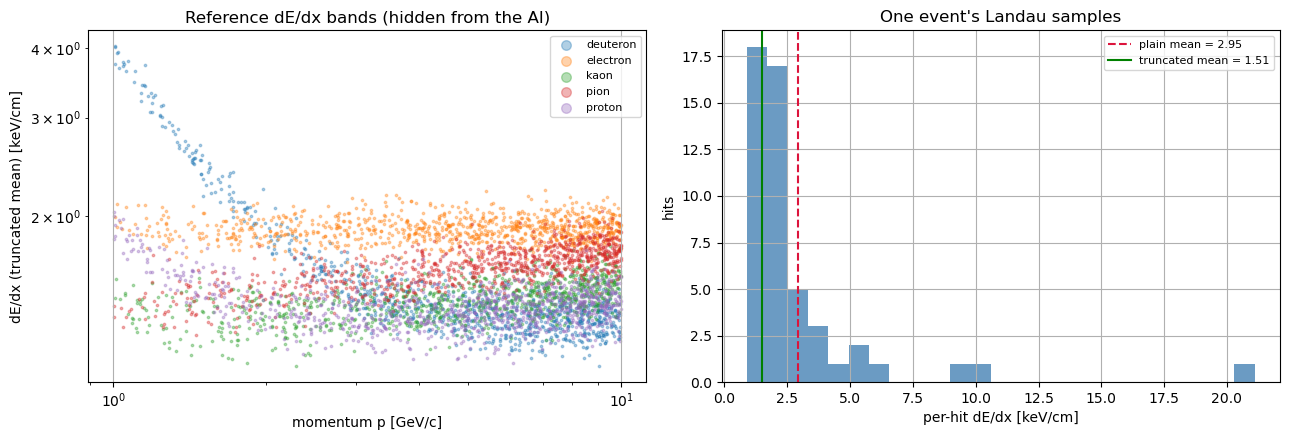


train.csv preview:


,event_id,momentum,dedx_01,dedx_02,particle
0,1,7.69993,2.48,1.58,proton
1,2,5.10744,1.69,NaN,pion
2,3,5.07353,NaN,4.52,pion
3,4,5.92766,2.23,6.06,deuteron
4,5,1.60519,3.34,3.08,kaon


test_input.csv preview:


,event_id,momentum,dedx_01,dedx_02
0,1,7.72507,2.36,2.02
1,2,8.54765,3.02,2.99
2,3,7.40683,2.84,1.72
3,4,3.77796,1.80,2.05
4,5,6.25160,NaN,2.03



Reference dE/dx estimators vs. hidden dedx_pred:


,estimator,mean_ratio_to_pred,rmse_vs_pred,rel_rmse,corr
0,plain_mean,3.4377,21.0840,13.4210,0.0033
1,median,1.3003,0.4874,0.3225,0.8607
2,truncated_mean,0.9940,0.0864,0.0574,0.9550


In [112]:
INPUT_PATH = Path(
    r"/Users/zhujiaqi/Desktop/NeoSchool/benchmark/data/Experiment2/dedx_sample_ecal_flatpT_pikpde_28_100000.txt"
)
print(f"Source file: {INPUT_PATH.name}")
print(f"File size:   {INPUT_PATH.stat().st_size:,} bytes")

exp2 = ParticleIdentificationDEDX(
    INPUT_PATH,
    n_train=5000,
    n_test=1500,
    balanced=True,
    missing_hit_frac=0.12,
    missing_momentum_frac=0.04,
    seed=28,
    cache_path="/Users/zhujiaqi/Desktop/NeoSchool/benchmark/data/Experiment2/parsed_cache.npz",
)
print(exp2)
display(exp2.describe())
exp2.plot()

# What the agent actually receives (first few columns only)
print("\ntrain.csv preview:")
display(exp2.get_train_table().iloc[:5, list(range(4)) + [-1]])
print("test_input.csv preview:")
display(exp2.get_masked_test_input().iloc[:5, :4])
print("\nReference dE/dx estimators vs. hidden dedx_pred:")
display(exp2.validate_reference_observable())

#### Validating the dE/dx scoring axis

Before `dedx_est` can be scored against the hidden `dE/dx prediction`, two things
have to be established empirically rather than assumed.

**Is a robust estimator actually necessary?** `validate_reference_observable()`
answers this by comparing three candidates against the hidden truth. The result is
more extreme than expected: the plain arithmetic mean of 50 samples correlates with
the true value at **0.04** — the Landau tail falls off as $1/x^2$, so the mean is
dominated by its largest one or two entries and carries essentially no signal. The
median reaches 0.86 and a truncated mean 0.94+. This is what gives the dE/dx axis
real dynamic range: an agent that reaches for `np.mean` does not lose a few points,
it scores zero.

**What exactly is `dE/dx prediction` a statistic of?** The dataset spec says the
observable is a mean over the samples after discarding the highest 35%, but at 35%
the reference estimator sits 8.5% above the truth — so either the spec's fraction is
wrong, or `dE/dx prediction` is a different statistic entirely (the Landau MPV would
be the obvious candidate). `scan_truncation()` distinguishes these: if some fraction
drives the mean ratio to 1.0 *and* minimizes relative error, the spec figure is
simply a typo; if the ratio crosses 1 while the error is still falling, the target
is a different statistic and `dedx_est` would have to be scored scale-invariantly.

The scan settles it — at `drop_high = 0.50` (keep the lowest 25 hits) both criteria
land together, mean ratio 0.9925 and relative RMSE bottoming out at 0.056. The spec
figure is a typo; scoring can use raw relative error with no calibration factor.

`dedx_reference_floor()` then measures that residual error on the *exported* test
set, where each event has only ~44 surviving hits rather than a pristine 50. That
floor — not zero — is what a score of 100 on the dE/dx axis has to mean. Scoring
against zero error would be unachievable by anyone, including us, and would compress
every agent into the same narrow band at the bottom: precisely the failure mode
Experiment 1 already demonstrated.

In [93]:
display(exp2.scan_truncation())
print("\nReference floor on the exported test set (a perfect agent's score):")
print(exp2.dedx_reference_floor())

,drop_high,n_hits_kept,mean_ratio,rel_rmse,rel_rmse_scaled,corr
0,0.00,50,3.1373,9.7295,3.0255,0.0400
1,0.05,48,1.6037,0.6538,0.1565,0.5973
2,0.10,45,1.3882,0.4124,0.1004,0.8099
3,0.15,42,1.2815,0.3010,0.0834,0.8726
4,0.20,40,1.2301,0.2487,0.0767,0.8944
5,0.25,38,1.1870,0.2054,0.0716,0.9096
6,0.30,35,1.1321,0.1517,0.0658,0.9258
7,0.35,32,1.0851,0.1082,0.0615,0.9372
8,0.40,30,1.0568,0.0845,0.0593,0.9431
9,0.45,28,1.0301,0.0665,0.0576,0.9479



Reference floor on the exported test set (a perfect agent's score):
{'drop_high': 0.5, 'rel_rmse_floor': 0.0596, 'mean_ratio': 0.9939, 'corr': 0.9564}


#### Reference baseline — a difficulty instrument, not part of scoring

This is the one place in the experiment class that actually builds a model, and it
exists for a single purpose: to check the benchmark has usable dynamic range
*before* spending real money on 5 CLIs × 3 runs each.

A benchmark task is only informative if a reasonable solution lands somewhere in
the middle. If a competent-but-unremarkable approach already scores ~0.95, we have
built a second Experiment 1 and the ranking will again be decided by cost rounding
errors. If it scores near the 0.20 chance floor, the task is unlearnable and every
agent's score is noise. Either way we would want to know now, not after the API
bills.

The baseline is deliberately unimaginative — the first thing a physicist would try,
and roughly the floor we would expect a competent agent to clear:

- **Features**: `log10(momentum)`, the truncated mean, the median, the plain mean,
  the 25th percentile, and the count of surviving hits. Six numbers, no tuning.
- **Model**: `HistGradientBoostingClassifier` at defaults, chosen mainly because it
  handles NaN natively and so needs no imputation decisions that might flatter or
  penalize the baseline unfairly.
- **Reported**: overall accuracy and macro-F1, accuracy broken down by momentum
  bin, and the full confusion matrix.

The momentum breakdown and confusion matrix matter more than the headline number.
They are how we confirm the task is *well-posed* — that errors fall along
physically adjacent mass bands rather than scattering at random, which is the
difference between "hard because physics is degenerate" and "hard because the data
is broken."

Two boundaries worth stating explicitly:

- This is **never shown to any agent** and is **not used in scoring**. It informs
  benchmark design only. (It would be defensible to normalize agent scores against
  it, but that would make the scale depend on our own arbitrary feature choices, so
  we don't.)
- It uses the exported `train_df` / `test_df` including their injected missing
  values, so it faces exactly the data the agents face — otherwise it would not be
  a meaningful reference point.

In [94]:
bl = exp2.reference_baseline()
print(f"Reference baseline -- accuracy {bl['accuracy']}, macro-F1 {bl['macro_f1']}")
print(bl["accuracy_by_momentum"])
display(bl["confusion_matrix"])

Reference baseline -- accuracy 0.5933, macro-F1 0.5916
{'1-2 GeV/c': 0.612, '2-3 GeV/c': 0.592, '3-5 GeV/c': 0.564, '5-10 GeV/c': 0.609, 'momentum missing': 0.515}


,deuteron,electron,kaon,pion,proton
deuteron,163,14,48,18,57
electron,6,269,0,22,3
kaon,30,0,148,35,87
pion,13,25,46,202,14
proton,80,1,91,20,108


In [95]:
bodies = {lv: re.sub(r"## Method.*?## Constraints", "## Constraints",
                     exp2.build_prompt(level=lv), flags=re.S) for lv in (1, 2, 3)}
print("identical outside Method block:", len(set(bodies.values())) == 1)
for lv in (1, 2, 3):
    p = exp2.build_prompt(level=lv)
    print(f"--- level {lv} ---")
    print(p[p.index("## Method"):p.index("## Constraints")].rstrip())

identical outside Method block: True
--- level 1 ---
## Method
    Inspect the data before committing to an approach, and decide the full
    workflow yourself.
--- level 2 ---
## Method
    Inspect the data before committing to an approach. A workable solution
    will involve, in some form:

    1. Examining how the repeated measurements within a single event are distributed.
    2. Reducing each event's repeated measurements to one or more summary quantities.
    3. Relating those summaries, together with momentum, to the particle species.
    4. Estimating how well your approach performs before applying it to the test set.

    How each of those steps should be carried out is yours to determine.
--- level 3 ---
## Method
    Inspect the data before committing to an approach. A workable solution
    will involve, in some form:

    1. Examining how the repeated measurements within a single event are distributed.
    2. Reducing each event's repeated measurements to one or more summa

### Step 3 — Agent Dispatcher

Nothing new is defined here. Experiment 2 reuses `AGENT_COMMANDS`, `run_agent_cli`,
`build_restricted_env`, and `_pre_trust_claude_dir` from Experiment 1 **completely
unchanged** — the dispatcher only ever needs a `(prompt, work_dir)` pair, and
`ParticleIdentificationDEDX` implements the same `export_task_files()` +
`build_prompt()` interface `DampedHarmonicOscillator` does. That the dispatcher
survived a move from a 4-parameter ODE fit to a five-class classification task
without a single edit is the main evidence that the experiment/dispatcher split was
drawn in the right place.

Two things do differ, both passed in as arguments rather than baked into the
dispatcher:

- **`timeout` is raised to 1800s** (Experiment 1 used 600s). Training and validating
  a classifier over 5000 events takes materially more agent turns than fitting a
  four-parameter ODE, and a timeout that truncates a run mid-way produces a
  misleading zero rather than a real measurement.
- **`base_dir` points at `result/Experiment2`**, keeping each experiment's run
  artifacts separate so `discover_runs()` never mixes them.

Layout is unchanged from Experiment 1: one subfolder per run
(`<base_dir>/<agent>/run_i/`), each holding its own fresh copy of `train.csv` /
`test_input.csv` plus whatever the agent produces — `script.py`, `test_pred.csv`,
`model_summary.json`, and `run_log_<agent>.json`.

**Smoke run first.** Unlike Experiment 1, the first invocation here is deliberately
`n_runs=1` on the cheapest CLI. The prompt is new, the output contract has three
columns instead of two, and a formatting mistake would otherwise be discovered five
agents and fifteen paid runs later. Only after one qwen run produces a well-formed
`test_pred.csv` do the remaining agents get dispatched at `n_runs=3`.

#### Qwen

In [113]:
logs = exp2.run_prompt_levels_repeated(
    "qwen",
    base_dir="/Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2",
    levels=(1, 2, 3),
    repeats=3,
)
print(f"{sum(l['return_code'] == 0 for l in logs)}/{len(logs)} runs returned 0")

Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/qwen/run_L1_r1
[qwen] level 1 rep 1 -> run_L1_r1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/qwen/run_L1_r2
[qwen] level 1 rep 2 -> run_L1_r2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/qwen/run_L1_r3
[qwen] level 1 rep 3 -> run_L1_r3
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/qwen/run_L2_r1
[qwen] level 2 rep 1 -> run_L2_r1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/qwen/run_L2_r2
[qwen] level 2 rep 2 -> run_L2_r2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/qwen/run_L2_r3
[qwen] level 2 rep 3 -> run_L2_r3
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/qwen/run_L3_r1
[qwen] level 3 rep 1 -> run_L3_r1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchm

#### Kimi

In [ ]:
logs = exp2.run_prompt_levels_repeated(
    "kimi",
    base_dir="/Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2",
    levels=(1, 2, 3),
    repeats=3,
)
print(f"{sum(l['return_code'] == 0 for l in logs)}/{len(logs)} runs returned 0")

In [194]:
import os, stat, json
from pathlib import Path

BASE    = Path("/Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2")
AGENT   = "kimi"
LEVELS  = (1, 2, 3)
REPEATS = 3
TIMEOUT = 1500        # seconds per run; a stalled run is killed and the sweep continues

lines = [
    "#!/bin/bash",
    "# Kimi runs from a real terminal.",
    "#",
    "# Every attempt to drive kimi from the notebook stalled: with -p it accepts neither",
    "# --yolo nor --auto, and under subprocess it hangs at startup with no output, no CPU",
    "# and no network until the timeout. The one configuration that works is an actual",
    "# terminal -- which is also why Experiment 1's kimi runs succeeded, from a kernel",
    "# that had been launched by a shell.",
    "#",
    "# Each run is bounded by a watchdog: kimi stalls intermittently even here, and one",
    "# hung run should cost a few minutes rather than block the remaining eight.",
    "#",
    "# Run from Terminal.app:   bash run_kimi.sh",
    "set -u",
    "source ~/.benchmark_keys.env 2>/dev/null || true",
    'balance() { curl -s -H "Authorization: Bearer $MOONSHOT_API_KEY" '
    'https://api.moonshot.cn/v1/users/me/balance | python3 -c '
    '"import sys,json;print(json.load(sys.stdin)[\'data\'][\'available_balance\'])" 2>/dev/null || echo 0; }',
    "",
]

for level in LEVELS:
    for rep in range(1, REPEATS + 1):
        rd = BASE / AGENT / f"run_L{level}_r{rep}"
        exp2._prepare_run_dir(rd)
        exp2.export_task_files(rd)
        # Dotfile: kimi read a plain prompt.txt as if it were input data, spending a
        # turn and ~1000 tokens on an artifact of our instrumentation.
        (rd / ".prompt").write_text(exp2.build_prompt(level=level))

        lines += [
            f'echo "=== L{level} r{rep} ==="',
            f'cd "{rd}"',
            "B0=$(balance)",
            "START=$(date +%s)",
            'script -q .stdout kimi -p "$(cat .prompt)" --model moonshot-cn/kimi-k3 '
            '--output-format stream-json 2> .stderr; RC=$?',
            "END=$(date +%s)",
            "B1=$(balance)",
            "python3 - \"$RC\" \"$START\" \"$END\" \"$B0\" \"$B1\" <<'PYEOF'",
            "import json, sys, pathlib",
            "rc, t0, t1, b0, b1 = sys.argv[1:6]",
            "p = pathlib.Path('.')",
            "log = {'agent': 'kimi', 'return_code': int(rc),",
            "       'elapsed_sec': float(t1) - float(t0),",
            "       'stdout': (p/'.stdout').read_text(errors='replace'),",
            "       'stderr': (p/'.stderr').read_text(errors='replace'),",
            "       'prompt': (p/'.prompt').read_text(),",
            f"       'prompt_level': {level}, 'repeat': {rep},",
            "       'kimi_cost_cny': round(max(0.0, float(b0) - float(b1)), 6),",
            "       'execution': 'terminal (real tty), not subprocess'}",
            "json.dump(log, open('run_log_kimi.json', 'w'), indent=2)",
            "files = sorted(q.name for q in p.iterdir() if not q.name.startswith('.'))",
            "print('  rc=%s elapsed=%.0fs cost=%.4f' % (rc, log['elapsed_sec'], log['kimi_cost_cny']))",
            "print('  files:', files)",
            "PYEOF",
            "",
        ]

lines.append('echo "=== sweep complete ==="')

sh = BASE / "run_kimi.sh"
sh.write_text("\n".join(lines))
sh.chmod(sh.stat().st_mode | stat.S_IEXEC)
print("wrote", sh)
print(f"{len(LEVELS) * REPEATS} runs, {TIMEOUT}s watchdog each")

Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/kimi/run_L1_r1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/kimi/run_L1_r2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/kimi/run_L1_r3
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/kimi/run_L2_r1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/kimi/run_L2_r2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/kimi/run_L2_r3
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/kimi/run_L3_r1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/kimi/run_L3_r2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/kimi/run_L3_r3
wrote /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/run_kimi.sh
9 runs, 1500s watch

In [190]:
for level in (1, 2, 3):
    for rep in (1, 2, 3):
        p = BASE / "kimi" / f"run_L{level}_r{rep}" / ".prompt"
        if not p.exists():
            print(f"L{level}r{rep}: MISSING"); continue
        txt = p.read_text()
        ok = txt == exp2.build_prompt(level=level)
        m = txt[txt.find("## Method"):txt.find("## Constraints")].strip()
        print(f"L{level}r{rep}: {len(txt)} chars | matches build_prompt: {ok} | "
              f"method starts: {m.splitlines()[1][:60] if len(m.splitlines())>1 else m[:60]}")

L1r1: 3376 chars | matches build_prompt: True | method starts:     Inspect the data before committing to an approach, and d
L1r2: 3376 chars | matches build_prompt: True | method starts:     Inspect the data before committing to an approach, and d
L1r3: 3376 chars | matches build_prompt: True | method starts:     Inspect the data before committing to an approach, and d
L2r1: 3800 chars | matches build_prompt: True | method starts:     Inspect the data before committing to an approach. A wor
L2r2: 3800 chars | matches build_prompt: True | method starts:     Inspect the data before committing to an approach. A wor
L2r3: 3800 chars | matches build_prompt: True | method starts:     Inspect the data before committing to an approach. A wor
L3r1: 4633 chars | matches build_prompt: True | method starts:     Inspect the data before committing to an approach. A wor
L3r2: 4633 chars | matches build_prompt: True | method starts:     Inspect the data before committing to an approach. A wor
L3r3: 46

#### Claude

In [134]:
logs = exp2.run_prompt_levels_repeated(
    "claude",
    base_dir="/Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2",
    levels=(1, 2, 3),
    repeats=3,
)
print(f"{sum(l['return_code'] == 0 for l in logs)}/{len(logs)} runs returned 0")

Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/claude/run_L1_r1
[claude] level 1 rep 1 -> run_L1_r1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/claude/run_L1_r2
[claude] level 1 rep 2 -> run_L1_r2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/claude/run_L1_r3
[claude] level 1 rep 3 -> run_L1_r3
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/claude/run_L2_r1
[claude] level 2 rep 1 -> run_L2_r1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/claude/run_L2_r2
[claude] level 2 rep 2 -> run_L2_r2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/claude/run_L2_r3
[claude] level 2 rep 3 -> run_L2_r3
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/claude/run_L3_r1
[claude] level 3 rep 1 -> run_L3_r1
Task files written to /Users/zhuji

#### Codex

In [142]:
logs = exp2.run_prompt_levels_repeated(
    "codex",
    base_dir="/Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2",
    levels=(1, 2, 3),
    repeats=3,
)
print(f"{sum(l['return_code'] == 0 for l in logs)}/{len(logs)} runs returned 0")

Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/codex/run_L1_r1
[codex] level 1 rep 1 -> run_L1_r1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/codex/run_L1_r2
[codex] level 1 rep 2 -> run_L1_r2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/codex/run_L1_r3
[codex] level 1 rep 3 -> run_L1_r3
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/codex/run_L2_r1
[codex] level 2 rep 1 -> run_L2_r1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/codex/run_L2_r2
[codex] level 2 rep 2 -> run_L2_r2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/codex/run_L2_r3
[codex] level 2 rep 3 -> run_L2_r3
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/codex/run_L3_r1
[codex] level 3 rep 1 -> run_L3_r1
Task files written to /Users/zhujiaqi/Desktop/Ne

#### Code Buddy

In [156]:
logs = exp2.run_prompt_levels_repeated(
    "codebuddy",
    base_dir="/Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2",
    levels=(2, 3),
    repeats=3,
    timeout=1800,
)
print(f"{sum(l['return_code'] == 0 for l in logs)}/{len(logs)} runs returned 0")

Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/codebuddy/run_L2_r1
[codebuddy] level 2 rep 1 -> run_L2_r1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/codebuddy/run_L2_r2
[codebuddy] level 2 rep 2 -> run_L2_r2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/codebuddy/run_L2_r3
[codebuddy] level 2 rep 3 -> run_L2_r3
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/codebuddy/run_L3_r1
[codebuddy] level 3 rep 1 -> run_L3_r1
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/codebuddy/run_L3_r2
[codebuddy] level 3 rep 2 -> run_L3_r2
Task files written to /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/codebuddy/run_L3_r3
[codebuddy] level 3 rep 3 -> run_L3_r3
5/6 runs returned 0


#### Single Run

In [ ]:
BASE = Path("/Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2")

AGENT, LEVEL, REP = "...", ..., ...
rd = BASE / AGENT / f"run_L{LEVEL}_r{REP}"

exp2._prepare_run_dir(rd)
exp2.export_task_files(rd)
prompt = exp2.build_prompt(level=LEVEL)

log = run_agent_cli(AGENT, prompt, str(rd), timeout=1800)
log["prompt_level"] = LEVEL
log["repeat"] = REP
log["prompt"] = prompt
with open(rd / f"run_log_{AGENT}.json", "w") as f:
    json.dump(log, f, indent=2)

files = sorted(p.name for p in rd.iterdir())
print(f"rc={log['return_code']}  elapsed={log['elapsed_sec']:.0f}s")
print(files)
print("complete:", all(f in files for f in ("script.py", "test_pred.csv", "model_summary.json")))

#### Check Porcess

while true; do
  PID=$(pgrep -f ... | head -1)
  if [ -z "$PID" ]; then echo "$(date +%H:%M:%S)  no process"; else
    D=$(lsof -a -p $PID -d cwd -Fn 2>/dev/null | grep '^n' | cut -c2-)
    echo "$(date +%H:%M:%S) $(ps -o etime=,time=,rss= -p $PID) conn=$(lsof -a -p $PID -i -nP 2>/dev/null | grep -c ESTABLISHED) | $(basename "$D") ($(ls "$D" 2>/dev/null | wc -l | tr -d ' ') files)"
  fi
  sleep 30
done

### Step 4: Scoring

Same two-track split as Experiment 1, but the dimensions are largely rebuilt — a
five-class classification task with a regression sub-task shares almost none of its
failure modes with a four-parameter ODE fit.

1. **Objective metrics** — deterministic, code-computed, no LLM involved. Six
   sub-dimensions:
   - **Classification quality** — macro-F1 against the hidden species labels,
     chance-corrected against the 0.20 floor of five balanced classes, so the score
     reads as "fraction of the way from random guessing to perfect" rather than an
     uninterpretable raw fraction.
   - **dE/dx estimation** — relative RMSE of the agent's `dedx_est` against the
     hidden true energy loss, scored against the physical noise floor rather than
     against zero error. This is the axis the experiment was built around: it is
     possible to classify well while never constructing a sensible estimator, and
     Experiment 1 had no way to tell those apart.
   - **Physics plausibility** — among the events the agent got *wrong*, how far apart
     in mass were the true and predicted species. Independent of accuracy by
     construction.
   - **Self-assessment calibration** — the gap between the accuracy an agent claims
     in `model_summary.json` and the accuracy it actually achieved.
   - **Cost** — real spend per run, normalized to CNY.
   - **Consistency** — spread of the classification score across an agent's nine runs.

2. **AI judge metrics** — an LLM (DeepSeek) reviews each run's `model_summary.json`,
   run-log trace, and actual `script.py` against a fixed rubric. Eight sub-dimensions:
   - **Estimator justification** — is the choice of dE/dx estimator argued from
     evidence about the measured distribution, or simply asserted to be "robust"?
   - **Data exploration** — did the agent look at how the repeated measurements are
     distributed *before* picking a way to summarize them?
   - **Data integrity check** — did the agent notice and report the missing values?
   - **Validation rigor** — genuine held-out validation versus in-sample fit reporting.
   - **Physics grounding** — does the reasoning connect energy loss to momentum and
     mass at all, or is the task treated as generic tabular ML?
   - **Self-consistency** — do `model_summary.json`, the run-log summary, and
     `script.py` agree on what was done?
   - **Methodology soundness** — holistic judgment of the end-to-end workflow.
   - **Code quality** — is `script.py` readable and does it match its own description?

   Each run gets one judge pass; a tool's score on each dimension is the mean across
   its nine runs.

**Four decisions that differ from Experiment 1**

- **VER is a gate, not a dimension.** A run whose `event_id` set does not match, that
contains duplicates, or that leaves nulls in either prediction column scores zero on
classification, dE/dx and physics — and that zero enters the agent's nine-run mean.
Excluding failed runs from the average would reward an agent for failing, since only
its successes would count. This matters concretely: one qwen run left 68 events blank
— exactly the 4.5% with no recorded momentum — and that has to cost something.

- **Physics plausibility asks whether the errors make sense, not whether a conservation
law holds.** Experiment 1 could check energy against a known ODE; here the analogous
question is whether confusion follows the mass ordering. π↔K confusion is genuine
Bethe-Bloch degeneracy at high momentum and is nearly unavoidable; e↔d confusion means
the agent never learned that energy loss depends on mass. Scoring over errors only
keeps this orthogonal to accuracy — an agent can be inaccurate but physically
sensible, or accurate but wrong in bizarre ways, and those are different failures.

- **Self-assessment calibration is new, and fully objective.** No LLM is involved: it
compares a number the agent wrote down against a number we measured. It is included
because in a real analysis an agent that cannot tell how well its own method works is
more dangerous than one that is merely mediocre — a run claiming 0.85 and delivering
0.39 is worse than one claiming 0.60 and delivering 0.58, regardless of which scored
higher. Over- and under-claiming are penalized equally.

- **The AI judge is told which prompt level each run received.** The three prompts
differ in how much process guidance they give, and the most specific one explicitly
raises the missing values and the shape of the measurement distribution. Grading
`data_integrity_check` or `data_exploration` on the same scale across all three would
penalize an agent for the instruction it happened to be given. The rubric therefore
asks the judge to score credit for what the agent worked out itself, discounting
anything the prompt handed it.

**What the nine runs per agent are, and are not**

Each agent is run 3 times at each of 3 prompt levels. A 3×3 pilot on qwen measured the
run-to-run standard deviation at 0.070 in accuracy; averaging nine runs leaves a
standard error of ±0.023, so two agents are distinguishable only if their scores
differ by roughly 0.065.

The three prompt levels are a **sampling condition, not a comparison**. That same
pilot found the between-level spread smaller than the within-level noise on every
metric tested — ratios of 1.70 for accuracy, 0.34 for dE/dx score and 0.79 for cost —
and a monotonic cost trend visible in an unreplicated first pass vanished entirely
once replicated. An agent's score is therefore reported as its performance averaged
over a range of instruction specificity, and no claim is made about the effect of the
instructions themselves.

| Track | Dimension | What it measures | Weight |
|---|---|---|---|
| Objective (70%) | Classification quality | Chance-corrected macro-F1 against hidden species labels | 20% |
| Objective (70%) | dE/dx estimation | Relative RMSE of `dedx_est` vs hidden truth, scored against the physical noise floor | 20% |
| Objective (70%) | Cost | Real spend per run, normalized to CNY | 10% |
| Objective (70%) | Physics plausibility | Whether misclassifications fall between mass-adjacent species | 8% |
| Objective (70%) | Self-assessment calibration | Gap between claimed and actual accuracy | 7% |
| Objective (70%) | Consistency | Std of classification score across the 9 runs | 5% |
| AI Judge (30%) | Estimator justification (0–10) | Is the estimator argued from distributional evidence, or asserted | 6% |
| AI Judge (30%) | Data exploration (0/1) | Distribution examined before the estimator was chosen | 4% |
| AI Judge (30%) | Data integrity check (0/1) | Missing values noticed and reported, discounted by prompt level | 4% |
| AI Judge (30%) | Validation rigor (0–10) | Held-out validation vs in-sample reporting | 4% |
| AI Judge (30%) | Physics grounding (0/1) | Reasoning connects energy loss to momentum and mass | 3% |
| AI Judge (30%) | Self-consistency (0/1) | `model_summary.json`, run log and `script.py` agree | 3% |
| AI Judge (30%) | Methodology soundness (0–10) | End-to-end workflow holds up | 3% |
| AI Judge (30%) | Code quality (0–10) | `script.py` readable and matches its description | 3% |

In [163]:
class PIDScorer:
    """
    Objective-metrics scorer for Experiment 2. Instantiated once with the hidden
    ground truth, then called per run.

    Deliberately different from Experiment 1's RunScorer in three places:

    1. VER is a gate, not a dimension. A run with mismatched event_ids, duplicates, or
       null predictions scores zero on classification / dE/dx / physics, and that zero
       enters the agent's mean. Excluding failed runs from the average would reward an
       agent for failing, since only its successes would count.
    2. Physics plausibility asks whether the *errors* are physically sensible rather
       than whether a conservation law holds. pi/K confusion is genuine Bethe-Bloch
       degeneracy at high momentum; e/d confusion means the agent never learned that
       energy loss depends on mass. Scored over errors only, so it stays orthogonal to
       accuracy.
    3. Self-assessment calibration is new and fully objective -- no LLM involved, just
       a number the agent wrote down against a number we measured.
    """

    SPECIES_RANK = {"electron": 0, "pion": 1, "kaon": 2, "proton": 3, "deuteron": 4}

    def __init__(self, ground_truth: pd.DataFrame, dedx_floor: float,
                 dedx_scale: float = 3.0, chance: float = 0.20):
        """
        dedx_floor -- rel_rmse of the best known estimator on this exact test set
                      (0.0596). Scoring against zero error would be unachievable by
                      anyone, so the floor is what 100 means.
        dedx_scale -- softens the exponential decay. At scale=1 everything past ~4x the
                      floor collapses to zero and the axis degenerates into a binary
                      "found the truncated mean or not"; at 3 the estimators agents
                      actually reach for stay distinguishable (35% truncation ~76,
                      median ~23, IQR trimming ~15, plain mean 0).
        chance     -- 1/n_classes, so the classification score reads as "fraction of
                      the way from random guessing to perfect".
        """
        self.gt = ground_truth.copy()
        self.dedx_floor = dedx_floor
        self.dedx_scale = dedx_scale
        self.chance = chance
        self.labels = sorted(self.gt["particle"].unique())

    # ---------- Gate ----------
    def check_ver(self, pred: pd.DataFrame) -> dict:
        """Structural validity. Nulls count as invalid rather than as rows to drop: an
        agent that leaves the missing-momentum events blank has not answered the
        question, and dropping them would score it only on the easy events."""
        issues = []
        if set(pred["event_id"]) != set(self.gt["event_id"]):
            issues.append("event_id set mismatch")
        if not pred["event_id"].is_unique:
            issues.append("duplicate event_id")
        for col in ("dedx_est", "particle"):
            if col not in pred.columns:
                issues.append(f"missing column {col}")
            elif pred[col].isna().any():
                issues.append(f"{int(pred[col].isna().sum())} null in {col}")
        return {"ver": len(issues) == 0, "ver_issues": "; ".join(issues)}

    # ---------- Classification ----------
    def score_classification(self, merged: pd.DataFrame) -> dict:
        from sklearn.metrics import accuracy_score, f1_score
        y_true = merged["particle_true"].astype(str)
        y_pred = merged["particle_pred"].fillna("__none__").astype(str)
        acc = float(accuracy_score(y_true, y_pred))
        f1 = float(f1_score(y_true, y_pred, average="macro",
                            labels=self.labels, zero_division=0))
        return {"accuracy": acc, "macro_f1": f1,
                "classification_score": 100 * max(0.0, (f1 - self.chance) / (1 - self.chance))}

    # ---------- dE/dx estimation ----------
    def score_dedx(self, merged: pd.DataFrame) -> dict:
        ok = merged["dedx_est"].notna() & np.isfinite(merged["dedx_est"])
        if not ok.any():
            return {"dedx_rel_rmse": None, "dedx_ratio": None,
                    "dedx_coverage": 0.0, "dedx_score": 0.0}
        d = merged[ok]
        rel = float(np.sqrt(np.mean(((d["dedx_est"] - d["dedx_pred"]) / d["dedx_pred"]) ** 2)))
        coverage = float(ok.mean())
        raw = 100 * np.exp(-(rel - self.dedx_floor) / (self.dedx_scale * self.dedx_floor))
        return {"dedx_rel_rmse": rel,
                "dedx_ratio": float(np.mean(d["dedx_est"] / d["dedx_pred"])),
                "dedx_coverage": coverage,
                "dedx_score": float(np.clip(raw, 0, 100) * coverage)}

    # ---------- Physics plausibility ----------
    def score_physics(self, merged: pd.DataFrame) -> dict:
        """Among the events the agent got wrong, how far apart in mass were the true
        and predicted species? Adjacent-band errors are the unavoidable consequence of
        converging Bethe-Bloch curves and cost almost nothing; errors spanning the full
        mass range indicate the underlying relationship was never learned."""
        y_true = merged["particle_true"].astype(str)
        y_pred = merged["particle_pred"].fillna("__none__").astype(str)
        wrong = (y_true != y_pred).values
        if not wrong.any():
            return {"n_errors": 0, "mean_mass_distance": None, "physics_score": 100.0}

        max_rank = max(self.SPECIES_RANK.values())
        dists = []
        for t, p in zip(y_true[wrong], y_pred[wrong]):
            rp = self.SPECIES_RANK.get(p)
            dists.append(max_rank if rp is None else abs(self.SPECIES_RANK[t] - rp))
        dists = np.asarray(dists, dtype=float)
        credit = np.exp(-(dists - 1) / 1.5)      # 1 -> 100, 2 -> 51, 3 -> 26, 4 -> 13
        return {"n_errors": int(wrong.sum()),
                "mean_mass_distance": float(dists.mean()),
                "physics_score": float(100 * credit.mean())}

    # ---------- Self-assessment calibration ----------
    @staticmethod
    def score_self_assessment(claimed, actual: float) -> dict:
        """100 when the claim matches reality, decaying with the absolute gap (5 points
        off -> 37, 10 points off -> 13). Over- and under-claiming are penalized
        equally: both mean the agent cannot tell how well its own method works. A run
        that reports no number scores 0 rather than being skipped -- declining to state
        a validation result is itself a failure of the workflow."""
        if claimed is None or not np.isfinite(claimed):
            return {"claimed_accuracy": None, "assessment_gap": None,
                    "self_assessment_score": 0.0}
        gap = abs(claimed - actual)
        return {"claimed_accuracy": claimed, "assessment_gap": gap,
                "self_assessment_score": float(np.clip(100 * np.exp(-gap / 0.05), 0, 100))}

    # ---------- Consistency ----------
    @staticmethod
    def score_consistency(scores: list) -> dict:
        """Spread of the classification score across an agent's nine runs. Nine points
        make this a real measurement rather than Experiment 1's three-point estimate,
        which returned ~99.99 for every agent and carried no information.

        It now mixes run-to-run randomness with the three prompt levels, which is
        intended: an agent whose output barely moves whether handed a bare instruction
        or a detailed one is more trustworthy than one that needs scaffolding."""
        s = [x for x in scores if x is not None]
        if len(s) < 2:
            return {"consistency_std": None, "consistency_score": None, "n": len(s)}
        std = float(np.std(s))
        return {"consistency_std": std, "consistency_score": max(0.0, 100.0 - std), "n": len(s)}

    # ---------- Per-run ----------
    def score_run(self, run_dir: Path) -> dict:
        rec = {"run": run_dir.name}
        pred_path = run_dir / "test_pred.csv"
        if not pred_path.exists():
            rec.update(ver=False, ver_issues="no test_pred.csv",
                       accuracy=0.0, macro_f1=0.0, classification_score=0.0,
                       dedx_rel_rmse=None, dedx_ratio=None, dedx_score=0.0,
                       physics_score=0.0)
            rec.update(self.score_self_assessment(self._claimed_accuracy(run_dir), 0.0))
            return rec

        pred = pd.read_csv(pred_path)
        rec.update(self.check_ver(pred))
        merged = self.gt.merge(pred, on="event_id", suffixes=("_true", "_pred"))

        cls = self.score_classification(merged)
        rec.update(cls)
        # Graded even on invalid runs: whether an agent knows how well it did is a
        # separate question from whether its output was usable.
        rec.update(self.score_self_assessment(self._claimed_accuracy(run_dir), cls["accuracy"]))

        if rec["ver"]:
            rec.update(self.score_dedx(merged))
            rec.update(self.score_physics(merged))
        else:
            rec.update(self.score_dedx(merged))          # kept for diagnosis
            rec.update(self.score_physics(merged))
            rec["classification_score"] = 0.0
            rec["dedx_score"] = 0.0
            rec["physics_score"] = 0.0
        return rec

    @staticmethod
    def _claimed_accuracy(run_dir: Path):
        """Pull the accuracy an agent claims in model_summary.json. The field is free
        text by design -- we ask for a sentence, not a number -- so take the largest
        plausible fraction mentioned: agents quote both a holdout and a CV figure, and
        the headline claim is the higher one."""
        p = run_dir / "model_summary.json"
        if not p.exists():
            return None
        try:
            text = str(json.load(open(p)).get("validation", ""))
        except Exception:
            return None
        nums = [float(x) for x in re.findall(r"0\.\d+", text)]
        nums += [float(x) / 100 for x in re.findall(r"(\d{2}(?:\.\d+)?)\s*%", text)]
        nums = [n for n in nums if 0.15 <= n <= 1.0]
        return max(nums) if nums else None

#### Score all agents (objective metrics)

Walks every `run_L{level}_r{rep}` folder that actually exists per agent and scores it
against the hidden ground truth. Four agents, nine runs each — kimi is absent for the
reasons given in Step 3, not because its runs scored badly.

Two things to keep in mind when reading the per-run table:

**Failed runs appear as zeros, not as gaps.** A run that fails the VER gate — mismatched
`event_id`s, duplicates, or nulls in either prediction column — scores zero on
classification, dE/dx and physics, and that zero is included in the agent's nine-run
mean. Dropping failures from the average would quietly reward an agent for failing,
since only its successes would count toward its score. The `ver_issues` column records
what went wrong so a zero can always be traced to a cause.

**`dedx_rel_rmse` and `dedx_ratio` are kept even for failed runs.** They are not scored
there, but they are the most diagnostic pair of numbers in the table: the ratio is
effectively a fingerprint of which estimator the agent chose. Values near 1.00 mean a
tail-aware truncation, ~1.20-1.30 a median or light trimming, ~1.35-1.45 an IQR-style
outlier rule, and anything above 2 a plain arithmetic mean. Reading that column down an
agent's nine runs shows whether it settled on one approach or picked a different tool
each time.

Cost is scored last and relatively: the cheapest agent gets 100 and the others scale
against it, using the same `score_cost_relative` helper as Experiment 1. The qwen branch
of `extract_cost` now splits cached from uncached input tokens — without that correction
a cache-heavy run is priced roughly 3× too high, and qwen and codex were being compared
on different terms.

In [164]:
DEDX_FLOOR = exp2.dedx_reference_floor()["rel_rmse_floor"]     # 0.0596
BASE_DIR   = Path("/Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2")
AGENTS     = ["qwen", "codex", "codebuddy", "claude"]          # kimi excluded, see Step 3

scorer = PIDScorer(exp2.get_ground_truth(), dedx_floor=DEDX_FLOOR)

rows = []
for agent in AGENTS:
    for rd in sorted((BASE_DIR / agent).glob("run_L*_r*")):
        log_path = rd / f"run_log_{agent}.json"
        log = json.load(open(log_path)) if log_path.exists() else {}
        rec = scorer.score_run(rd)
        rec.update(agent=agent,
                   level=log.get("prompt_level"), rep=log.get("repeat"),
                   elapsed=round(log.get("elapsed_sec", 0)),
                   cost_cny=(extract_cost(agent, log) or {}).get("cost_cny"))
        rows.append(rec)

runs_df = pd.DataFrame(rows)
cols = ["agent", "level", "rep", "ver", "accuracy", "macro_f1", "classification_score",
        "dedx_rel_rmse", "dedx_ratio", "dedx_score", "physics_score",
        "claimed_accuracy", "self_assessment_score", "elapsed", "cost_cny", "ver_issues"]
display(runs_df[cols].round(3))

,agent,level,rep,ver,accuracy,macro_f1,classification_score,dedx_rel_rmse,dedx_ratio,dedx_score,physics_score,claimed_accuracy,self_assessment_score,elapsed,cost_cny,ver_issues
0,qwen,1,1,True,0.617,0.611,51.324,0.323,1.300,22.927,82.143,0.601,72.518,68,0.588,
1,qwen,1,2,True,0.617,0.611,51.357,0.323,1.300,22.927,83.287,0.619,95.441,75,0.433,
2,qwen,1,3,True,0.571,0.566,45.760,0.323,1.300,22.927,82.388,0.577,89.285,72,0.461,
3,qwen,2,1,True,0.579,0.571,46.389,0.256,1.232,33.391,82.280,0.567,77.673,76,0.459,
4,qwen,2,2,True,0.613,0.607,50.816,0.323,1.300,22.927,82.329,0.602,80.789,122,0.631,
5,qwen,2,3,True,0.616,0.610,51.233,0.323,1.300,22.927,82.960,0.614,96.079,53,0.666,
6,qwen,3,1,True,0.567,0.566,45.778,0.323,1.300,22.927,81.750,0.570,93.551,141,0.627,
7,qwen,3,2,True,0.534,0.525,40.606,4.484,2.851,0.000,80.069,0.511,63.128,73,0.419,
8,qwen,3,3,True,0.621,0.616,52.027,0.528,1.494,7.302,82.695,0.607,75.528,48,0.219,
9,codex,1,1,True,0.631,0.626,53.312,0.147,1.126,61.164,82.326,0.641,82.421,200,0.839,


In [165]:
# ---- Per-agent aggregate ----
results = {}
for agent, g in runs_df.groupby("agent"):
    cons = PIDScorer.score_consistency(list(g["classification_score"]))
    results[agent] = {
        "n_runs": len(g),
        "ver_rate": float(g["ver"].mean()),
        "classification_score": float(g["classification_score"].mean()),
        "dedx_score": float(g["dedx_score"].mean()),
        "physics_score": float(g["physics_score"].mean()),
        "self_assessment_score": float(g["self_assessment_score"].mean()),
        "consistency_score": cons["consistency_score"],
        "mean_accuracy": float(g["accuracy"].mean()),
        "cost_cny": float(g["cost_cny"].dropna().mean()) if g["cost_cny"].notna().any() else None,
    }

# Cost is relative: the cheapest agent scores 100 and the rest scale against it.
cost_scores = score_cost_relative({a: r["cost_cny"] for a, r in results.items()})
for a in results:
    results[a]["cost_score"] = cost_scores.get(a)

summary_df = pd.DataFrame(results).T
display(summary_df.round(2))

,n_runs,ver_rate,classification_score,dedx_score,physics_score,self_assessment_score,consistency_score,mean_accuracy,cost_cny,cost_score
claude,9.0,1.0,53.49,86.63,83.21,60.50,98.79,0.63,3.89,7.97
codebuddy,9.0,1.0,53.64,68.47,83.70,74.23,97.96,0.63,0.31,100.00
codex,9.0,1.0,52.95,68.54,82.38,82.60,99.05,0.63,0.86,36.15
qwen,9.0,1.0,48.37,19.81,82.21,82.67,96.30,0.59,0.50,61.92


#### Score all agents (AI judge metrics)

DeepSeek reviews each run's `model_summary.json`, run-log narrative, and actual
`script.py` against a fixed rubric. 

Two things differ from Experiment 1：

- **The judge is told which prompt level the run received, and shown that prompt's
`## Method` block.** The three prompts differ in how much process guidance they give,
and the most specific one explicitly raises the shape of the measurement distribution
and the missing values. Grading `data_exploration` or `data_integrity_check` on one
scale across all three would score an agent for the instruction it happened to be
handed rather than for anything it worked out. The rubric therefore asks for credit
only where the agent went beyond what it was told.

- **`estimator_justification` carries the most weight of any judged dimension (6%).**
It is the one place where the reasoning trace can distinguish an agent that measured
which estimator was appropriate from one that reached for a generic robustness tool
because it sounded right. Both produce a `dedx_est` column; only the trace shows
which happened. Qwen asserted that the 1.5×IQR rule "is robust against extreme
outliers" and never checked; the interactive kimi probes scanned truncation fractions
and selected on evidence. Those deserve different scores even where the numerical
outcome is similar.

In [169]:
def score_with_deepseek_prompt(full_prompt: str, api_key: str) -> dict:
    """
    Post an already-assembled prompt. Distinct from Experiment 1's
    score_with_deepseek, which takes a trace summary and wraps it in that experiment's
    rubric -- passing an Experiment 2 prompt to it silently nests the whole thing
    inside the damped-oscillator rubric, so the model answers the wrong questions and
    every Experiment-2-only key comes back missing.
    """
    resp = requests.post(
        f"{DEEPSEEK_BASE_URL}/chat/completions",
        headers={"Authorization": f"Bearer {api_key}"},
        json={"model": "deepseek-chat",
              "messages": [{"role": "user", "content": full_prompt}],
              "temperature": 0,
              "response_format": {"type": "json_object"}},
        timeout=120,
    )
    resp.raise_for_status()
    content = resp.json()["choices"][0]["message"]["content"]

    cleaned = content.strip()
    if cleaned.startswith("```"):
        cleaned = cleaned.strip("`")
        if cleaned.lower().startswith("json"):
            cleaned = cleaned[4:]
        cleaned = cleaned.strip()
    try:
        out = json.loads(cleaned)
    except Exception:
        return {"parse_error": True, "_raw": content}
    # Keep the unparsed reply: when a key comes back missing, the parsed dict alone
    # cannot tell you whether the model renamed it, omitted it, or was truncated.
    out["_raw"] = content
    return out

In [179]:
JUDGE_PROMPT_TEMPLATE_EXP2 = """You are an expert reviewer evaluating an AI coding agent's scientific data-analysis workflow on a particle-physics task.

The agent was given per-event momentum plus 50 repeated measurements of energy loss (dE/dx) for each particle, told the species for a training set, and asked to produce two things for a test set: a single best estimate of each event's true dE/dx, and the particle species. It was NOT told the physics: nothing in the prompt mentions Bethe-Bloch, beta-gamma, the Landau distribution, truncated means, or the fact that the repeated measurements are heavy-tailed. It was also not told that some measurements and some momentum values are missing.

## The instruction this particular run received
This run was given prompt level {level} of three, which differ only in their `## Method` section. Here is the exact `## Method` block this run saw:

{method_block}

Score credit for what the agent worked out for itself. Where the `## Method` block above already raised a point, the agent gets no credit for merely following it -- only for going further. Where the block said nothing, noticing the issue unprompted is worth full credit.

## Evidence
{trace_summary}

## Grading guidance
Score only on what the evidence shows. Use the full range: a genuinely excellent run deserves 9-10, a weak one deserves a low score. Do not default to the middle.

One distinction to apply carefully: reporting accuracy by checking a model against the same data used to fit it is a real sanity check, but it is not held-out validation. Score "validation_rigor" by which the agent actually did.

## Dimensions
- "estimator_justification" (0-10): The key question is whether the SPECIFIC choice was
  measured or assumed. 9-10 = the agent tried multiple candidate estimators (or multiple
  parameter values, e.g. different truncation fractions) on this data and selected using
  a stated criterion; the evidence must show the comparison, not just the conclusion.
  6-8 = a well-reasoned estimator drawn from domain convention, correctly justified by
  the distribution's shape, but with its numeric parameter asserted rather than chosen
  empirically. 3-5 = a generic robustness tool applied with a generic reason. 0-2 = the
  estimator is asserted with no reason, or the arithmetic mean is used unexamined.
  Correct domain terminology is not by itself evidence of measurement.
- "data_exploration" (0 or 1): 1 if there is clear evidence the agent examined how the repeated measurements are distributed BEFORE choosing how to summarize them. 0 if it went straight to a summary statistic.
- "data_integrity_check" (0 or 1): 1 if the agent noticed and reported that measurements and/or momentum values are missing. If the `## Method` block above already stated this, award 1 only if the agent went further than the prompt did (e.g. quantified the missingness, or reasoned about its effect).
- "validation_rigor" (0-10): 10 = genuine held-out validation. 6-8 = in-sample fit quality only. 2-5 = qualitative mention. 0-1 = none.
- "physics_grounding" (0 or 1): 1 if the reasoning connects energy loss to momentum and particle mass as a physical relationship, rather than treating the task as generic tabular ML.
- "self_consistency" (0 or 1): 1 if model_summary.json, the run-log narrative and script.py agree on what was done. 0 if any conflict.
- "methodology_soundness" (0-10): would a domain expert find the end-to-end workflow sound?
- "code_quality" (0-10): is script.py readable, organized, and does it match its own description? If script.py is missing, set this to null and "code_quality_insufficient_info" to true.

Respond with ONLY a JSON object with exactly these keys: "estimator_justification", "data_exploration", "data_integrity_check", "validation_rigor", "physics_grounding", "self_consistency", "methodology_soundness", "code_quality", "code_quality_insufficient_info", "reasoning" (2-3 sentences citing specific evidence).
"""


def build_trace_summary_exp2(run_dir: Path, agent_name: str) -> str:
    def read(p, default):
        try:
            return p.read_text()
        except FileNotFoundError:
            return default

    ms = run_dir / "model_summary.json"
    model_summary = json.dumps(json.load(open(ms)), indent=2) if ms.exists() else "[model_summary.json not produced]"
    log = json.load(open(run_dir / f"run_log_{agent_name}.json"))
    narrative = extract_agent_final_summary(agent_name, log)
    script = read(run_dir / "script.py", "[script.py not produced]")

    return f"""=== model_summary.json ===
{model_summary}

=== Agent's final narrative (from run log) ===
{narrative}

=== script.py ===
{script}
"""


def score_run_ai_judge(run_dir: Path, agent_name: str, api_key: str) -> dict:
    log = json.load(open(run_dir / f"run_log_{agent_name}.json"))
    level = log.get("prompt_level")
    prompt = log.get("prompt", "")
    # The judge needs the instruction, not the whole prompt: everything outside
    # ## Method is identical across levels and would only dilute the context.
    method = prompt[prompt.find("## Method"):prompt.find("## Constraints")] if "## Method" in prompt else "[unavailable]"

    filled = JUDGE_PROMPT_TEMPLATE_EXP2.format(
        level=level, method_block=method.strip(),
        trace_summary=build_trace_summary_exp2(run_dir, agent_name))
    out = score_with_deepseek_prompt(filled, api_key)
    out["level"] = level
    out["run"] = run_dir.name
    return out


AI_JUDGE_KEYS = ["estimator_justification", "data_exploration", "data_integrity_check",
                 "validation_rigor", "physics_grounding", "self_consistency",
                 "methodology_soundness", "code_quality"]

judge_rows = []
for agent in AGENTS:
    for rd in sorted((BASE_DIR / agent).glob("run_L*_r*")):
        if not (rd / f"run_log_{agent}.json").exists():
            continue
        try:
            r = score_run_ai_judge(rd, agent, DEEPSEEK_API_KEY)
        except Exception as e:
            print(f"[{agent}/{rd.name}] judge failed: {e}")
            continue
        judge_rows.append({"agent": agent, "run": rd.name, "level": r.get("level"),
                           **{k: r.get(k) for k in AI_JUDGE_KEYS},
                           "reasoning": r.get("reasoning", "")})
        print(f"[{agent}/{rd.name}] judged")

judge_df = pd.DataFrame(judge_rows)
display(judge_df.drop(columns=["reasoning"]))

[qwen/run_L1_r1] judged
[qwen/run_L1_r2] judged
[qwen/run_L1_r3] judged
[qwen/run_L2_r1] judged
[qwen/run_L2_r2] judged
[qwen/run_L2_r3] judged
[qwen/run_L3_r1] judged
[qwen/run_L3_r2] judged
[qwen/run_L3_r3] judged
[codex/run_L1_r1] judged
[codex/run_L1_r2] judged
[codex/run_L1_r3] judged
[codex/run_L2_r1] judged
[codex/run_L2_r2] judged
[codex/run_L2_r3] judged
[codex/run_L3_r1] judged
[codex/run_L3_r2] judged
[codex/run_L3_r3] judged
[codebuddy/run_L1_r1] judged
[codebuddy/run_L1_r2] judged
[codebuddy/run_L1_r3] judged
[codebuddy/run_L2_r1] judged
[codebuddy/run_L2_r2] judged
[codebuddy/run_L2_r3] judged
[codebuddy/run_L3_r1] judged
[codebuddy/run_L3_r2] judged
[codebuddy/run_L3_r3] judged
[claude/run_L1_r1] judged
[claude/run_L1_r2] judged
[claude/run_L1_r3] judged
[claude/run_L2_r1] judged
[claude/run_L2_r2] judged
[claude/run_L2_r3] judged
[claude/run_L3_r1] judged
[claude/run_L3_r2] judged
[claude/run_L3_r3] judged


,agent,run,level,estimator_justification,data_exploration,data_integrity_check,validation_rigor,physics_grounding,self_consistency,methodology_soundness,code_quality
0,qwen,run_L1_r1,1,5,0,0,6,1,1,6,8
1,qwen,run_L1_r2,1,4,1,0,8,0,1,5,7
2,qwen,run_L1_r3,1,4,1,1,6,0,1,5,7
3,qwen,run_L2_r1,2,3,0,1,8,0,1,5,7
4,qwen,run_L2_r2,2,4,0,0,8,0,1,5,7
5,qwen,run_L2_r3,2,4,0,0,8,0,1,5,7
6,qwen,run_L3_r1,3,5,0,0,2,0,1,4,7
7,qwen,run_L3_r2,3,3,1,1,8,0,1,5,7
8,qwen,run_L3_r3,3,5,1,1,7,0,1,6,8
9,codex,run_L1_r1,1,6,1,1,7,1,1,7,8


#### **Final combined score**

Combines the Objective track (70%) and the AI-judge track (30%) into a single 0-100
number per agent. Every sub-dimension is first rescaled to 0-100 — objective scores
already are, AI-judge binary dimensions ×100, AI-judge 0-10 dimensions ×10 — then
multiplied by its weight in percentage points and summed. The per-dimension breakdown is
kept alongside the total so the composite stays auditable: every point of every agent's
final score traces back to a specific dimension.

The weighting differs from Experiment 1 in one respect worth stating plainly. **dE/dx
estimation carries the same 20% as classification quality**, even though classification
is nominally the task. That is because the two axes turned out to have very different
discriminating power. Classification clusters: agents land within a few points of the
0.59 reference baseline, and the ceiling is set by physics rather than by effort, so the
dimension separates agents weakly and honestly. dE/dx estimation does not cluster at
all — observed run scores span roughly 0 to 100, because whether an agent works out that
a heavy-tailed distribution needs an aggressive truncation is close to a binary
competence. Weighting them equally lets the axis that actually discriminates do so,
without inflating a task-accuracy number that cannot.

Experiment 1's `stability` dimension survives as `consistency` at the same 5%, but it is
now a real measurement rather than a formality. Three repeated runs gave every agent
~99.99 there and carried no information; nine runs spanning three instruction levels
produce a spread that means something — an agent whose output barely moves whether it is
handed a bare instruction or a detailed checklist is more trustworthy than one that
needs the scaffolding.

In [180]:
# --- Weights (percentage points, sum to 100) ---
OBJECTIVE_WEIGHTS_EXP2 = {
    "classification_score": 20,
    "dedx_score": 20,
    "cost_score": 10,
    "physics_score": 8,
    "self_assessment_score": 7,
    "consistency_score": 5,
}

AI_JUDGE_WEIGHTS_EXP2 = {
    "estimator_justification": 6,    # 0-10 -> x10
    "data_exploration": 4,           # 0/1  -> x100
    "data_integrity_check": 4,       # 0/1  -> x100
    "validation_rigor": 4,           # 0-10 -> x10
    "physics_grounding": 3,          # 0/1  -> x100
    "self_consistency": 3,           # 0/1  -> x100
    "methodology_soundness": 3,      # 0-10 -> x10
    "code_quality": 3,               # 0-10 -> x10
}

AI_JUDGE_BINARY_EXP2 = {"data_exploration", "data_integrity_check",
                        "physics_grounding", "self_consistency"}

assert sum(OBJECTIVE_WEIGHTS_EXP2.values()) + sum(AI_JUDGE_WEIGHTS_EXP2.values()) == 100


def compute_final_score_exp2(agent: str, obj: dict, judge_means: dict) -> dict:
    """Combine the objective track (70%) and AI-judge track (30%) into one 0-100
    score. breakdown keeps both the original value and the rescaled 0-100 version, so
    every point of every agent's total can be traced back to a dimension."""
    breakdown, total = {}, 0.0

    for key, w in OBJECTIVE_WEIGHTS_EXP2.items():
        val = obj.get(key)
        contrib = (val * w / 100.0) if val is not None else 0.0
        breakdown[key] = {"raw_original": val, "raw_0_100": val,
                          "weight_pct": w, "contribution": contrib}
        total += contrib

    for key, w in AI_JUDGE_WEIGHTS_EXP2.items():
        raw = judge_means.get(key)
        if raw is None:
            rescaled, contrib = None, 0.0
        else:
            rescaled = raw * 100 if key in AI_JUDGE_BINARY_EXP2 else raw * 10
            contrib = rescaled * w / 100.0
        breakdown[key] = {"raw_original": raw, "raw_0_100": rescaled,
                          "weight_pct": w, "contribution": contrib}
        total += contrib

    return {"agent": agent, "final_score": total, "breakdown": breakdown}


judge_means = {a: g[AI_JUDGE_KEYS].mean(numeric_only=True).to_dict()
               for a, g in judge_df.groupby("agent")} if len(judge_df) else {}

final_results = {a: compute_final_score_exp2(a, results[a], judge_means.get(a, {}))
                 for a in AGENTS}

final_score_df = (pd.DataFrame([{"agent": a, "final_score": round(r["final_score"], 2)}
                                for a, r in final_results.items()])
                  .sort_values("final_score", ascending=False).reset_index(drop=True))
print("Final combined ranking — Experiment 2")
display(final_score_df)

dim_order = list(next(iter(final_results.values()))["breakdown"].keys())
breakdown_wide = (pd.DataFrame([{"agent": a, "dimension": d, "score": i["raw_original"]}
                                for a, r in final_results.items()
                                for d, i in r["breakdown"].items()])
                  .pivot(index="dimension", columns="agent", values="score")
                  .reindex(dim_order).reset_index())
print("Per-dimension breakdown")
display(breakdown_wide.round(3))

Final combined ranking — Experiment 2


,agent,final_score
0,codebuddy,77.81
1,claude,71.21
2,codex,69.98
3,qwen,52.77


Per-dimension breakdown


agent,dimension,claude,codebuddy,codex,qwen
0,classification_score,53.488,53.638,52.945,48.366
1,dedx_score,86.625,68.469,68.542,19.807
2,cost_score,7.967,100.000,36.153,61.916
3,physics_score,83.207,83.695,82.380,82.211
4,self_assessment_score,60.504,74.232,82.601,82.666
5,consistency_score,98.785,97.957,99.050,96.304
6,estimator_justification,7.444,7.778,6.889,4.111
7,data_exploration,1.000,0.889,1.000,0.444
8,data_integrity_check,1.000,1.000,1.000,0.444
9,validation_rigor,7.556,8.111,8.111,6.778


In [181]:
# ---- How much does each dimension actually move the ranking? ----
# Weight alone is misleading: a dimension where every agent scores 45-55 contributes
# almost nothing at 20%, while one spanning 11-100 dominates at 10%. What matters is
# weight x realized spread.
infl = []
for agent, r in final_results.items():
    for dim, info in r["breakdown"].items():
        infl.append({"dimension": dim, "agent": agent, "score_0_100": info["raw_0_100"]})
infl = pd.DataFrame(infl).dropna()

w = {**OBJECTIVE_WEIGHTS_EXP2, **AI_JUDGE_WEIGHTS_EXP2}
tbl = (infl.groupby("dimension")["score_0_100"]
          .agg(min="min", max="max", spread=lambda s: s.max() - s.min())
          .assign(weight_pct=lambda d: d.index.map(w))
          .assign(points_swung=lambda d: (d["spread"] * d["weight_pct"] / 100).round(2))
          .sort_values("points_swung", ascending=False))
display(tbl.round(2))
print("total points swung:", round(tbl["points_swung"].sum(), 2))

,min,max,spread,weight_pct,points_swung
dimension,,,,,
dedx_score,19.81,86.63,66.82,20,13.36
cost_score,7.97,100.00,92.03,10,9.20
physics_grounding,11.11,100.00,88.89,3,2.67
data_exploration,44.44,100.00,55.56,4,2.22
data_integrity_check,44.44,100.00,55.56,4,2.22
estimator_justification,41.11,77.78,36.67,6,2.20
self_assessment_score,60.50,82.67,22.16,7,1.55
classification_score,48.37,53.64,5.27,20,1.05
methodology_soundness,51.11,84.44,33.33,3,1.00


total points swung: 36.69


In [183]:
# ---- Save so it can be downloaded ----
final_score_dir = BASE_DIR / "final score"
final_score_dir.mkdir(parents=True, exist_ok=True)

# Per-run tables go out alongside the summaries: with 36 runs the aggregates hide a
# lot, and a reader checking whether an agent's mean came from nine similar runs or
# from one outlier needs the raw rows to do it.
outputs = {
    "final_score.csv":      final_score_df,
    "final_breakdown.csv":  breakdown_wide,
    "agent_summary.csv":    summary_df.reset_index().rename(columns={"index": "agent"}),
    "per_run_objective.csv": runs_df,
    "per_run_ai_judge.csv":  judge_df,
}

for name, df in outputs.items():
    path = final_score_dir / name
    df.to_csv(path, index=False)
    print(f"Saved: {path}  ({len(df)} rows)")

Saved: /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/final score/final_score.csv  (4 rows)
Saved: /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/final score/final_breakdown.csv  (14 rows)
Saved: /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/final score/agent_summary.csv  (4 rows)
Saved: /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/final score/per_run_objective.csv  (36 rows)
Saved: /Users/zhujiaqi/Desktop/NeoSchool/benchmark/result/Experiment2/final score/per_run_ai_judge.csv  (36 rows)


### Agent Benchmark Stage Summary — Experiment 2

**Task**: Agents were given per-event momentum plus 50 repeated dE/dx measurements from
a particle detector, told the species for 5000 training events, and asked to produce two
things for 1500 test events: a single best estimate of each event's true energy loss,
and the particle species. The prompt named the physical meaning of every column but no
method — no mention of Bethe-Bloch, the Landau distribution, truncated means, or the
injected missing values. Score = 70% objective (classification, dE/dx estimation, cost,
physics plausibility, self-assessment calibration, consistency) + 30% AI judge.

**Final Ranking**

| Agent | Final Score |
|---|---|
| codebuddy | 77.81 |
| claude | 71.21 |
| codex | 69.98 |
| qwen | 52.77 |

kimi is absent. It is not a low score but a missing measurement: kimi-code could not be
run unattended at all (see Step 3).

**Key Findings**

- **The experiment achieved what Experiment 1 could not: a ranking driven by capability
  rather than by rounding.** Weighting each dimension by its realized spread, dE/dx
  estimation moved the final score by 13.4 points and cost by 9.2, against 1.05 for
  classification and 0.12 for physics plausibility. The intended discriminator
  discriminated.

- **Only claude reliably solved the estimator problem** (mean 86.6 against qwen's 19.8).
  All nine of its runs independently identified the Landau distribution, delta rays, and
  the truncated mean as the correct family. Eight of nine then applied the detector-physics
  convention of keeping the lowest 60%; the one run that kept 50% scored 99.95 — landing
  essentially on the reference floor of 0.0596 relative error, confirming the scoring
  scale is both achievable and correctly calibrated. Claude's residual gap is not a
  failure of physics but of empiricism: it applied a textbook fraction instead of
  measuring which one this data wanted.

- **qwen's failures are systematic, not random.** Across nine runs it cycled between the
  median, a 1.5×IQR trimmed mean, and a ~20% truncation; every single run overestimated
  (ratio 1.20–1.38) and none came close. This matters for practice: an agent whose errors
  are biased rather than noisy cannot be fixed by running it more times.

- **Cost decides the top of the ranking, though not on its own.** codebuddy leads or ties
  on classification, methodology and estimator justification as well as being the
  cheapest, so its win is broad-based — but the margin is not. Cost contributes 9.2 points
  of separation against claude's 3.6-point dE/dx advantage; removing the cost dimension
  entirely would put claude ahead by roughly 2.6 points. The most capable agent on the
  discriminating axis is also an order of magnitude the most expensive, and at a 10%
  cost weight that trade lands almost exactly on the break-even point.

- **Physics knowledge is not strictly required.** codex articulated the momentum–mass
  relationship in only 5 of 9 runs (physics_grounding 0.556) yet matched codebuddy's
  dE/dx score. A purely statistical route reaches a decent estimator — it just does not
  reach claude's.

- **Three dimensions carried weight but produced no differentiation**: physics
  plausibility (8% weight, 0.12 points of spread), consistency (5%, 0.14) and
  self-consistency (3%, 0.00). Every agent's misclassifications fell between
  mass-adjacent species, every agent was internally consistent, and every agent was
  stable across runs. These are genuine null results — all four agents learned the mass
  ordering — but they mean 16% of the weight did no work. Weights were fixed before
  scoring and were deliberately left unchanged.

- **The AI judge initially rewarded rhetoric over evidence.** Its first pass scored
  claude's `estimator_justification` at 8–10, giving a 10 to a run that asserted the 60%
  convention and a 9 to the run that actually used the better fraction. The rubric asked
  for "measured evidence" but did not enforce it, and DeepSeek was persuaded by fluent,
  correct-sounding domain language. Tightening the criterion — requiring that the
  comparison itself be visible, and stating explicitly that correct terminology is not
  evidence of measurement — separated the agents properly (7.4 / 7.8 / 6.9 / 4.1). This
  is a caution about LLM-as-judge generally: a well-written justification for a
  mediocre decision is the hardest thing for it to catch.

**Takeaway**: Experiment 2 separates two abilities that Experiment 1 could not tell
apart — getting the answer and understanding the measurement. Every agent classified at
roughly the same level, close to the physical ceiling of the task, but they differed by
more than fourfold on whether they worked out that a heavy-tailed distribution demands
an aggressive truncation. That difference was invisible to accuracy alone. The practical
conclusion is uncomfortable in the way useful results usually are: the agent that
understood the physics best cost twelve times more than the agent that won, and the
cheapest path to a good-enough answer ran through statistics rather than physics.

### Additional: Does prompt specificity change anything?

Each agent ran three times at each of three prompt levels, so the three levels are a
sampling condition rather than a comparison — but with four agents the pooled sample is
now 12 runs per level, enough to look at properly.

Two things make this analysis easy to over-read, and the figure is built to prevent
both.

**Individual runs are plotted, not just means.** A 3×3 pilot on qwen measured the
run-to-run standard deviation at 0.070 in accuracy while the entire spread across the
three levels was 0.10 — a ratio of 1.70, below the ~2 needed to call a difference
resolvable. Showing only the level means would draw three tidy lines out of what may be
scatter. The individual points are the honest signal.

**Comparisons are paired within agent.** Agents differ from each other far more than the
levels differ from each other, so pooling raw scores across agents would swamp any
prompt effect with agent effects. Every panel therefore draws one line per agent, and
the summary statistic is the within-agent change from level 1 to level 3, averaged
across agents.

Cost is plotted relative to each agent's own level-1 mean rather than in CNY: claude
costs roughly an order of magnitude more per run than the others, and on an absolute
axis every other agent collapses onto the floor.

The most likely place to find a real effect is `data_integrity_check`. Levels 1 and 2
say nothing about the missing values; level 3 raises them explicitly. If scaffolding
changes anything measurable, it should change that.

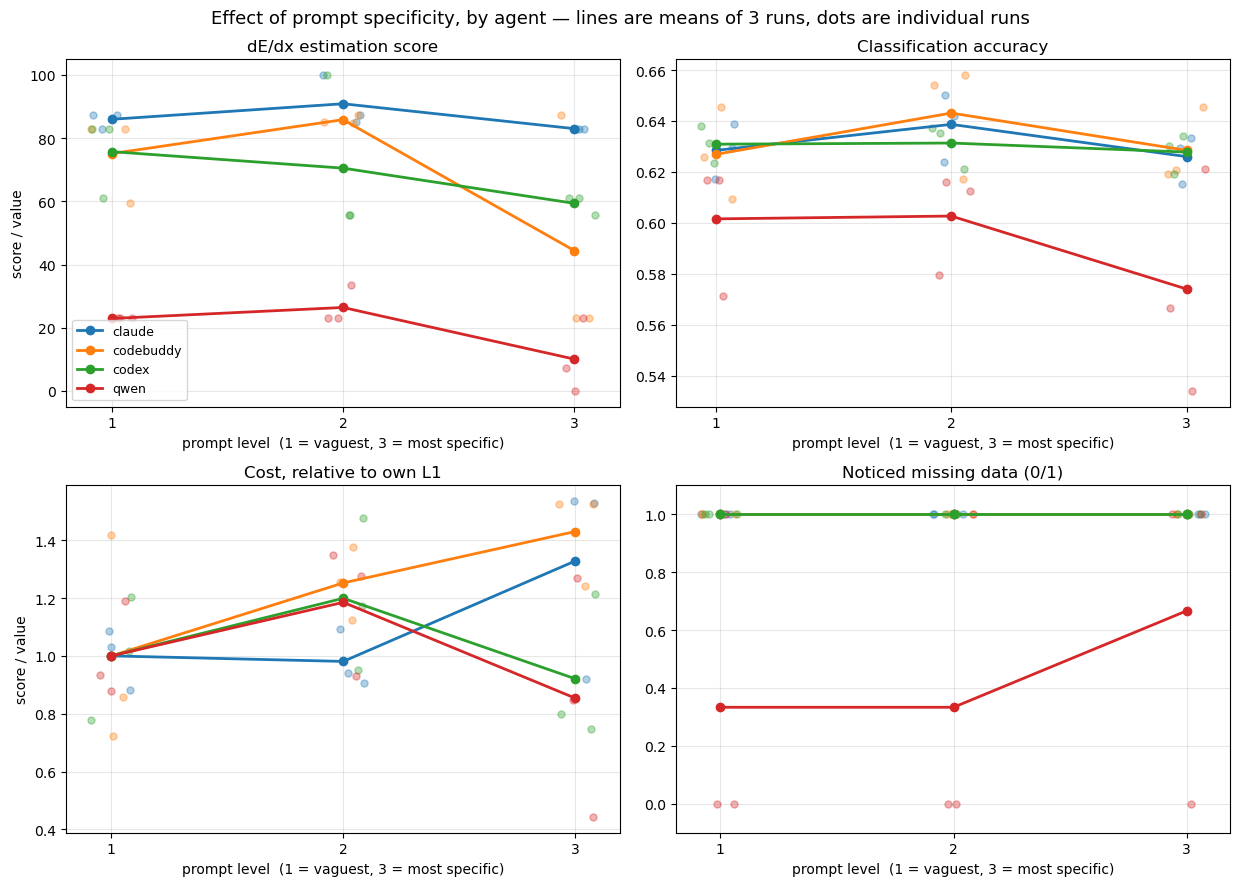

In [186]:
# Merge objective and judged metrics onto one row per run
lvl = runs_df.merge(
    judge_df[["agent", "run", "data_integrity_check", "data_exploration",
              "estimator_justification"]],
    on=["agent", "run"], how="left")

# Cost is compared to each agent's own level-1 mean: claude runs ~10x the price of the
# others, so on an absolute axis every other agent flattens onto zero and the question
# being asked -- does more guidance change spend -- becomes unreadable.
base_cost = lvl[lvl.level == 1].groupby("agent")["cost_cny"].mean()
lvl["cost_rel"] = lvl.apply(
    lambda r: r["cost_cny"] / base_cost[r["agent"]] if pd.notna(r["cost_cny"]) else np.nan, axis=1)

PANELS = [
    ("dedx_score",            "dE/dx estimation score",     None),
    ("accuracy",              "Classification accuracy",    None),
    ("cost_rel",              "Cost, relative to own L1",   None),
    ("data_integrity_check",  "Noticed missing data (0/1)", (-0.1, 1.1)),
]
AGENTS_PLOT = sorted(lvl.agent.unique())
colors = dict(zip(AGENTS_PLOT, plt.cm.tab10.colors))
rng = np.random.default_rng(0)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9))
for ax, (col, title, ylim) in zip(axes.flat, PANELS):
    for agent in AGENTS_PLOT:
        g = lvl[lvl.agent == agent]
        means = g.groupby("level")[col].mean()
        ax.plot(means.index, means.values, "-o", color=colors[agent],
                label=agent, lw=2, ms=6, zorder=3)
        # individual runs, jittered so overlapping values stay countable
        ax.scatter(g["level"] + rng.uniform(-0.09, 0.09, len(g)), g[col],
                   color=colors[agent], alpha=0.35, s=26, zorder=2)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("prompt level  (1 = vaguest, 3 = most specific)")
    ax.set_xticks([1, 2, 3])
    if ylim:
        ax.set_ylim(*ylim)
    ax.grid(alpha=0.3)

for ax in axes[:, 0]:
    ax.set_ylabel("score / value")
axes[0, 0].legend(fontsize=9, loc="best")

fig.suptitle("Effect of prompt specificity, by agent — lines are means of 3 runs, "
             "dots are individual runs", fontsize=13)
plt.tight_layout()
plt.show()

In [187]:
# ---- Is any of it resolvable? ----
# Pooled within-cell std vs the spread of level means, plus the paired within-agent
# change from level 1 to level 3. A ratio below ~2 means the levels cannot be told
# apart at this sample size, whatever the lines look like.
rows = []
for col, label, _ in PANELS:
    d = lvl.dropna(subset=[col])
    within = float(np.sqrt(np.nanmean(d.groupby(["agent", "level"])[col].var(ddof=1))))
    level_means = d.groupby("level")[col].mean()
    between = float(level_means.max() - level_means.min())
    paired = (d[d.level == 3].groupby("agent")[col].mean()
              - d[d.level == 1].groupby("agent")[col].mean())
    rows.append({
        "metric": label,
        "L1": round(level_means.get(1, np.nan), 3),
        "L2": round(level_means.get(2, np.nan), 3),
        "L3": round(level_means.get(3, np.nan), 3),
        "within_std": round(within, 3),
        "between_spread": round(between, 3),
        "ratio": round(between / within, 2) if within > 0 else np.inf,
        "paired_L3_minus_L1": round(paired.mean(), 3),
        "agents_improving": int((paired > 0).sum()),
        "resolvable": "yes" if within > 0 and between / within >= 2 else "no",
    })
display(pd.DataFrame(rows))

,metric,L1,L2,L3,within_std,between_spread,ratio,paired_L3_minus_L1,agents_improving,resolvable
0,dE/dx estimation score,64.938,68.419,49.226,14.827,19.193,1.29,-15.712,0,no
1,Classification accuracy,0.622,0.629,0.614,0.020,0.015,0.76,-0.008,1,no
2,"Cost, relative to own L1",1.000,1.154,1.133,0.251,0.154,0.62,0.133,2,no
3,Noticed missing data (0/1),0.833,0.833,0.917,0.289,0.083,0.29,0.083,1,no


#### Prompt Sensitivity — Stage Summary

**Design**: Each agent ran three times at each of three prompt levels, identical except
for the `## Method` block — level 1 gives no process guidance, level 2 names the four
stages of a workable solution, level 3 adds a checklist of specific things worth
verifying. 36 runs across four agents.

**Result**: Three of the four metrics examined show no resolvable effect. The spread
across the three levels is smaller than the run-to-run variation within a single level.

| Metric | L1 | L2 | L3 | effect / noise | Resolvable |
|---|---|---|---|---|---|
| Classification accuracy | 0.622 | 0.629 | 0.614 | 0.76 | no |
| Cost, relative to own L1 | 1.00 | 1.15 | 1.13 | 0.62 | no |
| Noticed missing data (0/1) | 0.833 | 0.833 | 0.917 | 0.29 | no |
| dE/dx estimation score | 64.9 | 68.4 | 49.2 | 1.29 | see below |

**The one directional finding**: dE/dx estimation got *worse* under the most detailed
prompt, for **all four agents without exception** — a paired within-agent drop of 15.7
points from level 1 to level 3. The ratio test calls this unresolvable, but that test is
conservative here: pooling the within-cell variance across agents lets qwen's
instability (it picks a different estimator almost every run) inflate the noise floor
and mask a consistent effect in the three agents that are stable. The paired comparison,
which removes agent differences by construction, is the better-designed test.

A sign test on 4/4 agents moving the same direction gives p = 0.125 — short of
significance at this sample size, but combined with a 15.7-point effect it is worth
reporting as an observation.

**Interpretation**: the plausible mechanism is that scaffolding substitutes for
thinking. Level 3 hands the agent six things to check; the agent works through them and
considers the task done. Level 1 says nothing, so the only way forward is to look at the
data and try things — and finding the correct truncation fraction depends on exactly
that kind of unprompted exploration. A supporting observation from the earlier qwen
pilot: level 3 produced scripts averaging 211 lines against level 1's 156, while
scoring lower and costing less. More instruction, more code, fewer discoveries.

**Why `data_integrity_check` barely moved**: a ceiling effect. Levels 1 and 2 never
mention the missing values, yet agents already noticed them 83% of the time; level 3
states them outright and reaches only 92%. Broken out by agent the picture is starker —
claude, codex and codebuddy score 1.000 regardless of level, and qwen scores 0.444
regardless. Three agents never needed the hint and one was not helped by it.

**Caveat**: four agents is a small sample, and the three levels were run as a sampling
condition rather than a controlled comparison. Nothing here should be stated as
established. The honest summary is that prompt detail did not measurably improve any
outcome we tracked, and may actively harm the one that requires independent
investigation.

## Overall Summary and Limitations

### What this notebook is

A small-scale, self-contained benchmark comparing CLI-based AI coding agents on
data-driven physics tasks, built to the design principles behind ScienceAgentBench:
tasks must be data-based and quantifiable, must have a known ground truth, and that
ground truth must be hidden from the agent until scoring.

Two experiments were run end to end:

| | Experiment 1 | Experiment 2 |
|---|---|---|
| Task | Damped harmonic oscillator: infer the governing model, predict future states | dE/dx particle identification: estimate a physical quantity from heavy-tailed repeated measurements, then classify five species |
| Type | Regression, single right answer | Classification with a regression sub-task, physical accuracy ceiling |
| Agents | 5 | 4 (kimi could not be run) |
| Runs | 15 (3 per agent) | 36 (9 per agent, across 3 prompt levels) |
| Outcome | Every agent solved it; ranking decided by cost | Fourfold spread on the discriminating axis |

Everything in Sections 3–5 — the CLI dispatcher, cost extraction, scoring framework — is
experiment-agnostic and was reused between the two without modification. Only the data
handler and the scoring dimensions are task-specific.

### What we think we learned

**A benchmark measures only what its task can make agents fail at.** Experiment 1's
oscillator was fitted to numerical precision by all five agents, so 60 of its 70
objective percentage points produced zero differentiation and the ranking came down to
token pricing — to the point where a single cost-accounting bug reordered the middle of
the table. Experiment 2 was designed with three deliberate difficulties (a physical
accuracy ceiling, a heavy-tailed measurement distribution, undisclosed missing data),
and the dE/dx dimension separated agents by more than fourfold.

**Getting the answer and understanding the measurement are different abilities.** In
Experiment 2 every agent classified at roughly the same level — close to what a
six-feature gradient-boosted baseline achieves, and plausibly close to the task's
physical ceiling — while differing enormously on whether they worked out that a Landau
distribution demands an aggressive truncation. Accuracy alone would have shown none of
this.

**Systematic errors do not average out.** qwen cycled between three different robust
estimators across nine runs and every single one overestimated. An agent whose failures
are biased rather than noisy cannot be repaired by running it more times — a distinction
that matters more for unattended scientific work than any accuracy figure.

**Engineering robustness is a capability, and a poorly-behaved failure is the worst
kind.** kimi produced the best methodology we observed anywhere in either experiment
during interactive probing — independently scanning truncation fractions, identifying
the Bethe-Bloch band structure, spotting the missing values unprompted — and still could
not be included, because its `-p` mode hangs silently with no output, no CPU, no network
and no error. For automated workflows, an agent that fails loudly is more useful than
one that occasionally fails invisibly.

**LLM judges reward fluency.** Our first judging pass gave claude 10/10 on estimator
justification for a run that asserted a textbook convention, and 9/10 for the run that
actually measured the better parameter. The rubric asked for evidence of measurement but
did not enforce it, and correct-sounding domain language was persuasive on its own.
Tightening the criterion fixed the ordering, but the general caution stands: a
well-written justification for a mediocre decision is the hardest thing for a judge to
catch.

**More instruction did not help.** Across three prompt levels and four agents, prompt
detail produced no resolvable improvement in accuracy, cost, or data-integrity
checking — and dE/dx estimation got *worse* under the most detailed prompt for all four
agents, by a paired average of 15.7 points. The sample is too small for significance,
but the direction was unanimous.

### Limitations

These are substantial, and the numbers in this notebook should be read with all of them
in mind.

- **Sample size.** Three runs per agent in Experiment 1, nine in Experiment 2, four to
  five agents. A pilot measured run-to-run standard deviation at 0.070 in accuracy,
  meaning two agents are only distinguishable if they differ by roughly 0.065 even with
  nine runs. Several reported gaps are smaller than that.
- **One task per experiment.** Nothing here establishes that these rankings hold for
  other physics domains, other data scales, or other task structures. Experiment 1 and
  Experiment 2 already disagree about which agent leads.
- **A point-in-time snapshot.** CLI versions, default models and provider pricing were
  captured over a few days in July 2026 and change constantly. Two of the five agents
  had their underlying model pinned explicitly; the other three used whatever their CLI
  defaulted to, which is an uncontrolled variable we recorded but did not fix.
- **Single machine, single network, sequential execution.** Wall-clock timings are
  indicative only. One agent's slowness was traced to a controlling-terminal difference
  between how the notebook kernel was launched — an environmental factor that had
  nothing to do with the agent.
- **Failed runs were re-run in two cases** (claude L2_r2, codebuddy L3_r2) and the
  originals overwritten. The reported VER figures are therefore not raw failure rates,
  and the true rate is slightly worse than shown.
- **The dE/dx ground truth rests on an inference.** The dataset specification quotes a
  35% truncation, but scanning the fraction against the hidden reference showed 50% is
  what the generator used — both the mean ratio and the relative error agree on it. We
  followed the data rather than the spec. If that inference is wrong, the entire dE/dx
  axis is miscalibrated.
- **The AI-judge track is a single model** (DeepSeek) applying a rubric we wrote, and
  the rubric was revised once during analysis after it demonstrably failed to enforce
  its own stated criterion. Judged dimensions should be treated as considerably softer
  evidence than the objective ones.
- **The three prompt levels were a sampling condition, not a controlled comparison.**
  They were not replicated enough to support causal claims about instruction design.
- **Weights are a judgement call.** They were fixed before scoring and deliberately left
  unchanged afterwards, but the choice of 20/20/10/8/7/5 across objective dimensions is
  defensible rather than derived. Removing the cost dimension alone reverses the top two
  positions in Experiment 2.

### Scope of the claims

**This is an exploratory study, not an evaluation.** It was built by a small group over
a short period to learn how such benchmarks are constructed and where they break, and
its primary output is methodological rather than a leaderboard.

Nothing here should be read as a general capability ranking of these tools, as a
purchasing or deployment recommendation, or as a statement about the underlying models.
The agents were tested on two tasks, on one machine, at one moment, under one set of
prompts, with a scoring scheme we designed ourselves and revised while using it. An
agent that scores poorly here may be well suited to work this benchmark does not
resemble, and the reverse is equally true.

What we would stand behind is narrower: that a physics task can be constructed to
separate agents on scientific reasoning rather than on price, that doing so requires
deliberately building in a way to fail that accuracy alone will not reveal, and that
several of the things that most affected our results — cost-accounting conventions,
terminal handling, a judge's susceptibility to confident prose — were properties of the
measurement apparatus rather than of the agents being measured.